<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    DATA ANALYSIS PROJECT
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    Use Case : Alfamart
</h2>

# **Outline**

- [**Section 0.** Import Library](#import-library)
- [**Section 1.** Business Understanding](#business-understanding)
- [**Section 2.** Data Understanding](#data-understanding)
- [**Section 3.** Data Cleaning](#data-cleaning)
- [**Section 4.** Data Analysis](#data-analysis)
- [**Section 5.** Kesimpulan dan Rekomendasi](#kesimpulan-dan-rekomendasi)


# **Section 0 : Import Libary**

In [218]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sc

from scipy.stats import shapiro                            # Uji Normalitas
from scipy.stats import ttest_1samp                        # One Sample T test
from scipy.stats import ttest_ind                          # Independent T Test
from scipy.stats import ttest_rel                          # Paired T test
from scipy.stats import f_oneway                           # Anova
from scipy.stats import wilcoxon                           # Wilcoxon one way dan Paired
from scipy.stats import mannwhitneyu                       # Mann Withney U Test
from scipy.stats import kruskal                            # Kruskal Wallis
from statsmodels.stats.proportion import proportions_ztest # Ztes
from scipy.stats import chi2_contingency                   # Chi Square

pos_transactions = pd.read_csv('alfa_pos_transactions.csv')
products = pd.read_csv('alfa_products.csv')
stores = pd.read_csv('alfa_stores.csv')

df = pd.merge(pos_transactions, products, on='sku_id')
df = pd.merge(df, stores, on='store_id')
display(df)

,receipt_id,store_id,sku_id,member_id,trx_time,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date
0,RCP00000001,SAT-0142,SKU000180,MEM-11247,2022-12-24 21:00:00,BCA Debit,1,33500.0,Bimoli Pouch 2000ml,Food & Staples,33500.0,Alfamart Gatot Subroto 141,Bandung,2022-10-18
1,RCP00000002,SAT-0294,SKU000115,MEM-32305,2022-10-25 14:00:00,Cash,2,62200.0,Bimoli Pouch 2000ml,Food & Staples,31100.0,Alfamart Sudirman 293,Malang,2021-03-15
2,RCP00000003,SAT-0623,SKU000132,MEM-08155,2022-12-02 08:00:00,Tunai,3,85500.0,Pepsodent 190g,Personal Care,28500.0,Alfamart Gatot Subroto 622,Depok,2021-06-22
3,RCP00000004,SAT-0386,SKU000262,MEM-12656,2024-07-28 09:00:00,CASH,12,314400.0,Indomie Goreng,Food & Staples,26200.0,Alfamart Melati 385,Bandung,2023-08-02
4,RCP00000005,SAT-0665,SKU000437,MEM-44669,2023-07-14 12:00:00,ShopeePay,1,16700.0,Mnyk Goreng Bimoli,Food & Staples,16700.0,Alfamart Melati 664,Bekasi,2022-06-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,RCP00299996,SAT-0220,SKU000146,MEM-10553,2021-10-25 16:00:00,QRIS,5,224000.0,Indm Grg,Food & Staples,44800.0,Alfamart Diponegoro 219,Depok,2021-07-01
299996,RCP00299997,SAT-0735,SKU000334,MEM-14511,2024-03-11 10:00:00,CASH,1,11100.0,Indomie Goreng,Food & Staples,11100.0,Alfamart Pahlawan 734,Bandung,2023-02-14
299997,RCP00299998,SAT-0240,SKU000358,MEM-05940,2022-07-06 12:00:00,Gopay,2,88800.0,Mnyk Goreng Bimoli,Food & Staples,44400.0,Alfamart Pahlawan 239,Jakarta,2021-05-21
299998,RCP00299999,SAT-0899,SKU000091,NaN,2023-05-31 10:00:00,Cash,3,43500.0,Indomie Goreng,Food & Staples,14500.0,Alfamart Pahlawan 898,Bandung,2022-02-14


# **BUSINESS UNDERSTANDING**

# **1. Background**

Jaringan minimarket Alfamart telah menjadi urat nadi distribusi kebutuhan sehari-hari bagi masyarakat Indonesia. Dengan belasan ribu gerai yang tersebar dari ujung Sumatera hingga Papua, Alfamart mengelola rantai pasok (supply chain) berskala raksasa. Setiap harinya, jutaan transaksi terjadi di meja kasir (Point of Sale / POS), mencatat pergerakan jutaan SKU (Stock Keeping Unit) mulai dari air mineral, rokok, hingga produk personal care. Volume data hiper-masif ini adalah harta karun untuk memahami pola konsumsi masyarakat di tingkat hiper-lokal.

Namun, mengelola data dari belasan ribu mesin kasir fisik yang beroperasi baik secara online maupun offline (saat internet gerai mati) adalah mimpi buruk bagi tim Data Engineer. Mesin POS di toko seringkali mengalami delay sinkronisasi ke Distribution Center (DC) atau Head Office. Akibatnya, pembaruan harga promo atau status inventory sering tidak sinkron. Kasir di lapangan juga terkadang melakukan human error saat melakukan scanning barcode, seperti men-scan barang yang sama berkali-kali secara tidak sengaja, atau melakukan void (pembatalan) transaksi dengan prosedur yang salah.

Dinamika paling liar terjadi pada akhir pekan, khususnya saat kampanye Promo JSM (Jumat, Sabtu, Minggu) berlangsung. Promo ini dirancang sebagai loss leader untuk menarik traffic pengunjung retail (ibu rumah tangga) ke dalam toko. Sayangnya, sistem sering mendeteksi bahwa barang promo ini ludes diborong oleh segelintir pelanggan yang terindikasi sebagai "Tengkulak" atau pemilik warung kelontong yang memanfaatkan selisih harga. Praktik borong ini membuat pelanggan asli tidak kebagian barang, merusak tujuan awal dari strategi marketing, dan membuat margin perusahaan terkuras habis.

Selain itu, masalah klasik retail offline seperti Shrinkage (selisih stok antara fisik dan sistem akibat pencurian, tikus, atau kedaluwarsa) semakin memperparah inefisiensi. Tim operasional kesulitan melacak apakah sebuah barang hilang karena dicuri pelanggan, dikonsumsi internal oleh karyawan gerai, atau karena memang sistem POS gagal mencatat transaksi retur ke DC. Data produk yang berantakan penamaannya antar-gerai juga membuat proses audit stok menjadi proses manual yang sangat menyiksa.

Oleh karena itu, analisis mendalam terhadap bongkahan data POS kasir, master data produk, dan profil gerai ini wajib segera dieksekusi. Tanpa pembersihan data POS dan deteksi anomali transaksi JSM, manajemen tidak akan bisa membedakan mana traffic pelanggan asli dan mana traffic tengkulak. Analisis ini adalah langkah mutlak untuk menyelamatkan margin profit promo, menertibkan prosedur scanning kasir, dan menurunkan angka shrinkage secara sistematis di seluruh jaringan toko.

# **2. Problem Statement**

**Masalah Utama:** Kebocoran margin profit akibat penyalahgunaan Promo JSM oleh tengkulak, serta kacaunya pelaporan inventaris akibat error pada sistem POS dan input kasir.

**Masalah Turunan:**

- Gerai mana saja yang memiliki volume transaksi Promo JSM tertinggi namun didominasi oleh segelintir member saja (indikasi gerai dikuasai tengkulak)?
- Kategori barang FMCG apa yang paling sering mengalami void atau pembatalan transaksi di meja kasir?
- Seberapa parah tingkat ketidakkonsistenan penulisan tipe pembayaran (Tunai/Cash/E-Wallet) yang di-input oleh mesin kasir dari berbagai gerai?
- Berapa persen transaksi yang tidak menyertakan ID Member (missing values), sehingga tim CRM kehilangan jejak Customer Lifetime Value?
- (Logical Error) Apakah ada transaksi yang tercatat di database dengan tanggal transaksi yang terjadi sebelum gerai tersebut resmi dibuka (Grand Opening)?
- Berapa estimasi kerugian dari outliers di mana kuantitas (QTY) barang yang di-scan bernilai ekstrem (misal 10.000 pcs dalam satu struk) atau bahkan bernilai negatif?

# **3. Goals**

Bila use case ini berhasil dipecahkan, target bisnisnya adalah:

- **Promo Protection:** Membangun rules deteksi dini untuk membatasi kuantitas pembelian barang JSM per member secara real-time di mesin kasir.
- **Cashier SOP Evaluation:** Menemukan pola error scanning (QTY minus / Outliers) untuk dijadikan bahan training ulang bagi para kasir.
- **Master Data Management:** Menstandarisasi pencatatan metode pembayaran dan kategori produk agar pelaporan finance harian tidak selisih (variance).
- **Fraud/System Bug Fix:** Menghapus data fiktif (Logical Error transaksi sebelum toko buka) yang merusak akurasi laporan sales historis perusahaan.

# **4. Analytical Approach**

Pendekatan analitik pada studi ini dimulai dengan proses **Exploratory Data Analysis (EDA)** sebagai fondasi utama untuk memahami kualitas data serta mengidentifikasi pola transaksi yang berkaitan dengan problem bisnis.

Tahapan analisis dilakukan secara sistematis sebagai berikut:

- **Data Cleaning & Validation:**  
  Mengidentifikasi dan menangani data anomali seperti
  1) Missing values (member_id)
  2) Inkonsistensi penulisan payment method
  3) logical error (transaksi terjadi sebelum store dibuka)
  4) Jumlah qty yang outlier.

- Data Analyst
**Customer & Transaction Behavior Analysis:**  
  Mengidentifikasi pola pembelian abnormal pada Promo JSM, seperti:
  - Total Frekuensi belanjan member perbulan
  - Frekeunsi pembelian member perbulan


# **Section 2 : Data Understanding**

# 4. Dataset Dictionary

## 🏪 Tabel: alfa_stores.csv (Dimensi Gerai)

| Nama Kolom | Tipe Data | Deskripsi |
|------------|----------|----------|
| store_id | Kategorikal | Kode unik gerai Alfamart. |
| store_name | Kategorikal | Nama gerai (biasanya nama jalan/daerah). |
| city | Kategorikal | Kota lokasi gerai. |
| open_date | Datetime | Tanggal toko mulai beroperasi (Grand Opening). |

---

## 📦 Tabel: alfa_products.csv (Dimensi Produk)

| Nama Kolom | Tipe Data | Deskripsi |
|------------|----------|----------|
| sku_id | Kategorikal | ID unik produk (Barcode). |
| product_name | Kategorikal | Nama produk/barang. |
| category | Kategorikal | Kategori produk (Food, Beverage, Personal Care, Cigarettes). |
| unit_price | Numerik | Harga normal per unit produk. |

---

## 🧾 Tabel: alfa_pos_transactions.csv (Fakta Transaksi)

| Nama Kolom | Tipe Data | Deskripsi |
|------------|----------|----------|
| receipt_id | Kategorikal | Nomor unik struk transaksi. |
| store_id | Kategorikal | ID gerai tempat transaksi terjadi. |
| sku_id | Kategorikal | ID produk yang dibeli. |
| member_id | Kategorikal | ID member (Pontaw/Alfamart Member). |
| trx_time | Datetime | Waktu transaksi dilakukan di kasir. |
| payment_method | Kategorikal | Metode pembayaran (Cash, QRIS, E-Wallet, dll). |
| qty | Numerik | Jumlah unit barang yang dibeli. |
| total_price | Numerik | Total harga transaksi (qty × unit_price). |

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   receipt_id      300000 non-null  object 
 1   store_id        300000 non-null  object 
 2   sku_id          300000 non-null  object 
 3   member_id       180000 non-null  object 
 4   trx_time        300000 non-null  object 
 5   payment_method  300000 non-null  object 
 6   qty             300000 non-null  int64  
 7   total_price     300000 non-null  float64
 8   product_name    300000 non-null  object 
 9   category        300000 non-null  object 
 10  unit_price      300000 non-null  float64
 11  store_name      300000 non-null  object 
 12  city            300000 non-null  object 
 13  open_date       300000 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 32.0+ MB


In [220]:
# Statistic Descriptif

df.describe()

,qty,total_price,unit_price
count,300000.000000,3.000000e+05,300000.000000
mean,30.957860,7.491928e+05,24477.235000
std,500.924037,1.351185e+07,11980.632011
min,-5.000000,-2.240000e+05,3200.000000
25%,1.000000,2.070000e+04,15100.000000
50%,2.000000,3.740000e+04,24100.000000
75%,3.000000,7.800000e+04,34700.000000
max,9999.000000,4.479552e+08,44800.000000


## 📊 Descriptive Statistics Analysis

Berdasarkan hasil statistik deskriptif, terdapat beberapa temuan penting yang mengindikasikan adanya **anomali data** serta potensi **error pada sistem POS maupun input kasir**.

### 🔍 1. Quantity (qty)
- Rata-rata qty: **30.96**, namun median hanya **2**
- Standar deviasi sangat tinggi (**500.92**)
- Nilai minimum: **-5** → ❗ tidak logis (tidak mungkin beli barang negatif)
- Nilai maksimum: **9999** → ❗ outlier ekstrem

👉 **Insight:**
Distribusi qty cukup beragam karena memiliki standar deviasi yang tinggi namun ada terdapat data anomali yaitu adanya nilai minus yang sebesar **-5** dan nilai maximum yang tingggi sekitar **9999** .

👉 **Interpretasi Bisnis:**
- Kemungkinan terjadi:
  -  Nilai minus yang sebesar **-5** akibat dari masalah klasik retail      offline seperti Shrinkage (selisih stok antara fisik dan sistem akibat pencurian, tikus, atau kedaluwarsa) semakin memperparah inefisiensi


  - nilai maximum yang tingggi sekitar **9999** akibat dari kasir yang melakukan scan secara berkali kali.

---

### 💰 2. Total Price
- Rata-rata: **~749,192**
- Median: **37,400** → jauh lebih kecil dari mean
- Nilai minimum: **-224,000** → ❗ tidak logis
- Nilai maksimum: **447,955,200** → ❗ sangat ekstrem

👉 **Insight:**
Berdasarkan hasil statistik deskriptif mengindikasikan bahwa adanya beberapa data anomali yaitu dari nilai minimum negatif yang dimana ini tidak logis dan jumlah nilai makasimum yang tidak wajar karena memiliki selisih yang beda jauh dengan nilai mean itu sendiri.  

👉 **Interpretasi Bisnis:**
   - Transaksi negatif bisa mengindikasikan kemasalah
  - Nilai ekstrem bisa berasal dari kasir yang melakukan scan berkali kali
  - Pembelian dalam jumlah besar (tengkulak)
  - Error qty

---

### 🏷️ 3. Unit Price
- Rata-rata: **24,477**
- Median: **24,100** → relatif normal
- Range: **3,200 – 44,800**

👉 **Insight:**
Distribusi unit_price terlihat cukup stabil dan tidak memiliki anomali signifikan.

👉 **Interpretasi Bisnis:**
- Data harga produk relatif bersih
- Tidak ada indikasi kesalahan besar pada master data produk

---

### ⚠️ 4. Kesimpulan Utama
Dari analisis ini, ditemukan beberapa indikasi masalah serius:

**Data Quality Issue**
   - Adanya nilai negatif pada qty dan total_price
   - Adanya nilai yang sangat ekstreem pada qty 9999, sehingga membuat beberapa total price yang tidak wajar\

# **Section 3 : Data Cleaning**

In [221]:
# Feature General Information

items = []

for col in df.columns:
    items.append([col, df[col].dtype, df[col].isna().sum(),
                     round((df[col].isna().sum()/len(df[col]))*100, 2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

df_desc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=items)
df_desc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,receipt_id,object,0,0.0,300000,"[RCP00206305, RCP00226109]"
1,store_id,object,0,0.0,1000,"[SAT-0411, SAT-0192]"
2,sku_id,object,0,0.0,500,"[SKU000262, SKU000053]"
3,member_id,object,120000,40.0,48616,"[MEM-28506, MEM-21182]"
4,trx_time,object,0,0.0,26609,"[2022-08-29 21:00:00, 2023-04-12 18:00:00]"
5,payment_method,object,0,0.0,10,"[debit bca, OVO]"
6,qty,int64,0,0.0,10,"[5, 2]"
7,total_price,float64,0,0.0,2343,"[-224000.0, -183000.0]"
8,product_name,object,0,0.0,13,"[Rokok Sampoerna Mild, Indomie Goreng]"
9,category,object,0,0.0,4,"[Food & Staples, Cigarettes]"


## 📊 Data Overview & Feature Inspection

Pada tahap awal data cleaning, dilakukan eksplorasi terhadap seluruh fitur dalam dataset untuk memahami struktur data, tipe data, serta kualitas data secara keseluruhan.

---

### 🔍 Proses yang Dilakukan

- Mengidentifikasi tipe data pada setiap kolom (`dataType`)  
- Menghitung jumlah dan persentase missing value (`null`, `nullPct`)  
- Menghitung jumlah nilai unik (`unique`)  
- Menampilkan contoh nilai unik (`uniqueSample`) untuk memahami isi data  

---

### 📈 Temuan Utama

- Mayoritas kolom memiliki **missing value = 0%**, menunjukkan kualitas data yang cukup baik  
- Kolom `member_id` memiliki missing value sebesar **±40%**, yang mengindikasikan:
  - tidak semua transaksi menggunakan membership  
  - atau data membership tidak selalu tercatat  

- Kolom seperti:
  - `receipt_id`, `store_id`, `sku_id` memiliki **high cardinality** (banyak nilai unik)  
  - `category`, `payment_method` memiliki **low cardinality** (sedikit kategori)  

- Ditemukan adanya nilai ekstrem pada:
  - `total_price` (nilai negatif & sangat besar)  
  - `qty` (indikasi outlier)  

---

### ⚠️ Insight Data Quality

- Secara umum, dataset memiliki **struktur yang lengkap dan minim missing value**  
- Namun terdapat beberapa potensi isu:
  - missing value pada `member_id`  
  - kemungkinan outlier pada `qty` dan `total_price`  
  - tipe data `trx_time` dan `open_date` masih dalam format object (perlu konversi)  

---

### 🧠 Kesimpulan

Tahap ini memberikan gambaran awal bahwa dataset cukup siap untuk analisis, namun tetap memerlukan:
- pembersihan outlier  
- transformasi tipe data  
- penanganan missing value pada kolom tertentu  

Langkah ini menjadi dasar penting sebelum melakukan analisis lebih lanjut.

## **Missing Value**


In [256]:
# 1. Cek Standard Missing Values (NaN / Null)
standard_missing = round(df.isna().sum()/len(df)*100,2)

# 2. Cek Implicit Missing Values (Label 'unknown')
implicit_unknown = (df == 'unknown').sum()

# 3. Cek Implicit Missing Values (Whitespace / String Kosong)
implicit_whitespace = df.apply(lambda x: x.astype(str).str.strip() == '').sum()

# Menggabungkan semua temuan ke dalam satu tabel ringkasan
missing_summary = pd.DataFrame({
    'Standard NaN': standard_missing,
    'Label "unknown"': implicit_unknown,
    'Whitespace': implicit_whitespace
})

# Menampilkan hanya kolom yang memiliki setidaknya satu jenis missing value/unknown
missing_summary_filtered = missing_summary[(missing_summary.T != 0).any()]

print("Ringkasan Pemeriksaan Data Hilang & Implisit:")
display(missing_summary)

Ringkasan Pemeriksaan Data Hilang & Implisit:


,Standard NaN,"Label ""unknown""",Whitespace
receipt_id,0.0,0,0
store_id,0.0,0,0
sku_id,0.0,0,0
member_id,40.0,0,0
payment_method,0.0,0,0
qty,0.0,0,0
total_price,0.0,0,0
product_name,0.0,0,0
category,0.0,0,0
unit_price,0.0,0,0


In [274]:
# 1. Cek Standard Missing Values (NaN / Null)
standard_missing = round(df.isna().sum()/len(df)*100,2)

# 2. Cek Implicit Missing Values (Label 'unknown')
implicit_unknown = (df == 'unknown').sum()

# 3. Cek Implicit Missing Values (Whitespace / String Kosong)
implicit_whitespace = df.apply(lambda x: x.astype(str).str.strip() == '').sum()

# Menggabungkan semua temuan ke dalam satu tabel ringkasan
missing_summary = pd.DataFrame({
    'Standard NaN': standard_missing,
    'Label "unknown"': implicit_unknown,
    'Whitespace': implicit_whitespace
})

# Menampilkan hanya kolom yang memiliki setidaknya satu jenis missing value/unknown
missing_summary_filtered = missing_summary[(missing_summary.T != 0).any()]

print("Ringkasan Pemeriksaan Data Hilang & Implisit:")
display(missing_summary)

Ringkasan Pemeriksaan Data Hilang & Implisit:


,Standard NaN,"Label ""unknown""",Whitespace
receipt_id,0.0,0,0
store_id,0.0,0,0
sku_id,0.0,0,0
member_id,40.0,0,0
payment_method,0.0,0,0
qty,0.0,0,0
total_price,0.0,0,0
product_name,0.0,0,0
category,0.0,0,0
unit_price,0.0,0,0


In [223]:
# Calculate the total number of transactions
total_transactions = len(df)

# Calculate the number of transactions with missing member_id
alfamart_missing_member = df[df['member_id'].isnull()]
num_missing_members = len(alfamart_missing_member)

#Calculate the number of transaction non missing member
alfamart_member = df[df['member_id'].notnull()]
num_members = len(alfamart_member)

# Calculate the percentage of missing member IDs
percentage_missing = (num_missing_members / total_transactions) * 100
percentage_member = (num_members / total_transactions) * 100

print(f"Percentage of transactions with Non Member ID: {percentage_member:.2f}%")
print

print(f"Percentage of transactions with missing Member ID: {percentage_missing:.2f}%")

Percentage of transactions with Non Member ID: 60.00%
Percentage of transactions with missing Member ID: 40.00%


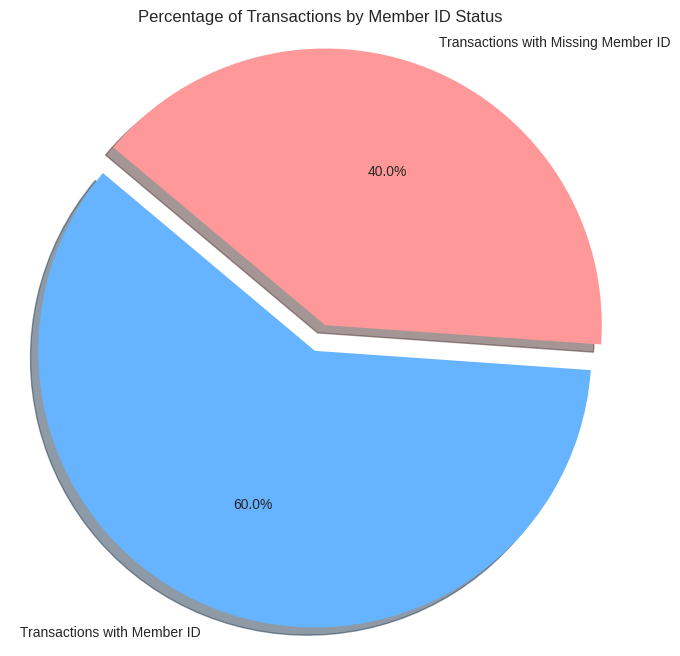

In [224]:
labels = ['Transactions with Member ID', 'Transactions with Missing Member ID']
sizes = [percentage_member, percentage_missing]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # Explode the 'missing member ID' slice for emphasis

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of Transactions by Member ID Status')
plt.show()

## Missing Member ID Analysis

Ditemukan bahwa sekitar **40% transaksi tidak memiliki `member_id`**, sehingga sebagian besar transaksi tidak dapat ditelusuri oleh sistem CRM.

### Insight
Missing ini tidak selalu berarti error data, melainkan bisa disebabkan oleh:
- Customer tidak menggunakan/member
- Kasir tidak menginput member saat transaksi

###  Dampak Bisnis
- Kehilangan visibilitas terhadap **Customer Lifetime Value (CLV)**
- Sulit melakukan **segmentasi dan personalisasi promo**

###  Kesimpulan
Missing `member_id` memberikan gambaran masih banyak pelanggan tidak menggunakan member

## Rekomendasi
Tim Alfamart perlu meningkatkan **Service Quality** dan Training kasir untuk menawarkan pelanggan berganbung member.

Berikut Service QUality yang berupa poin royalty jika konsumen sering memberi denngan dapat menukar barang berupa:
- Voucher diskon
- Pembelian barang esklusif  


In [260]:
# Data Frame untuk Data cleaning
df_cln = df.copy() # Initialize df_cln as a copy of df

# Remove rows with missing 'member_id'
df_cln.dropna(subset=['member_id'], inplace=True)

print(f"Number of rows after removing missing member_id: {len(df_cln)}")
print(f"Missing values in member_id after cleaning: {df_cln['member_id'].isnull().sum()}")

Number of rows after removing missing member_id: 180000
Missing values in member_id after cleaning: 0


In [261]:
# 1. Cek Standard Missing Values (NaN / Null)
standard_missing = round(df_cln.isna().sum()/len(df_cln)*100,2)

# 2. Cek Implicit Missing Values (Label 'unknown')
implicit_unknown = (df_cln == 'unknown').sum()

# 3. Cek Implicit Missing Values (Whitespace / String Kosong)
implicit_whitespace = df_cln.apply(lambda x: x.astype(str).str.strip() == '').sum()

# Menggabungkan semua temuan ke dalam satu tabel ringkasan
missing_summary = pd.DataFrame({
    'Standard NaN': standard_missing,
    'Label "unknown"': implicit_unknown,
    'Whitespace': implicit_whitespace
})

# Menampilkan hanya kolom yang memiliki setidaknya satu jenis missing value/unknown
missing_summary_filtered = missing_summary[(missing_summary.T != 0).any()]

print("Ringkasan Pemeriksaan Data Hilang & Implisit:")
display(missing_summary)

Ringkasan Pemeriksaan Data Hilang & Implisit:


,Standard NaN,"Label ""unknown""",Whitespace
receipt_id,0.0,0,0
store_id,0.0,0,0
sku_id,0.0,0,0
member_id,0.0,0,0
payment_method,0.0,0,0
qty,0.0,0,0
total_price,0.0,0,0
product_name,0.0,0,0
category,0.0,0,0
unit_price,0.0,0,0


# **Data Dupicate**

In [227]:
# Cek Duplikat Data
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100
duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

print(f"Total Baris Duplikat: {duplicate_count}")
print(f"Persentase dari Total Data: {duplicate_percent:.4f}%")
print("\nSampel Pasangan Data Duplikat:")
display(duplicate_rows)


Total Baris Duplikat: 0
Persentase dari Total Data: 0.0000%

Sampel Pasangan Data Duplikat:


,receipt_id,store_id,sku_id,member_id,trx_time,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date


In [228]:
# clean duplicate data
# list column
columns = [
    'receipt_id',
    'store_id',
    'member_id'
]

# create empty list to store results

results = []

# loop through columns

for col in columns :
  results.append ({
      'columns': col,
      'is_duplicated' : df_cln.duplicated(subset=[col]).sum()
  })

#convert to dataframe
summary_table = pd.DataFrame(results)

display(summary_table)

,columns,is_duplicated
0,receipt_id,0
1,store_id,179000
2,member_id,131384


## 📊 Data Insight – Duplicate Check

Hasil pengecekan menunjukkan bahwa tidak terdapat duplikasi pada `receipt_id`, sehingga setiap transaksi pada alfamrt beragam.

Sementara itu, duplikasi pada `store_id` dan `member_id` merupakan hal yang wajar, karena:
- Satu gerai (`store_id`) dapat melakukan banyak transaksi
- Satu pelanggan (`member_id`) dapat melakukan transaksi berulang

### 🔍 Insight
- Duplikasi pada `store_id` dan `member_id` mencerminkan aktivitas transaksi yang normal
- Tidak menunjukkan adanya masalah kualitas data

### 🧠 Kesimpulan
- Tidak diperlukan penghapusan data duplikat untuk kolom `store_id` dan `member_id`
- Data tetap valid untuk analisis lanjutan

# **Outlier Detection**

## **Histogram**

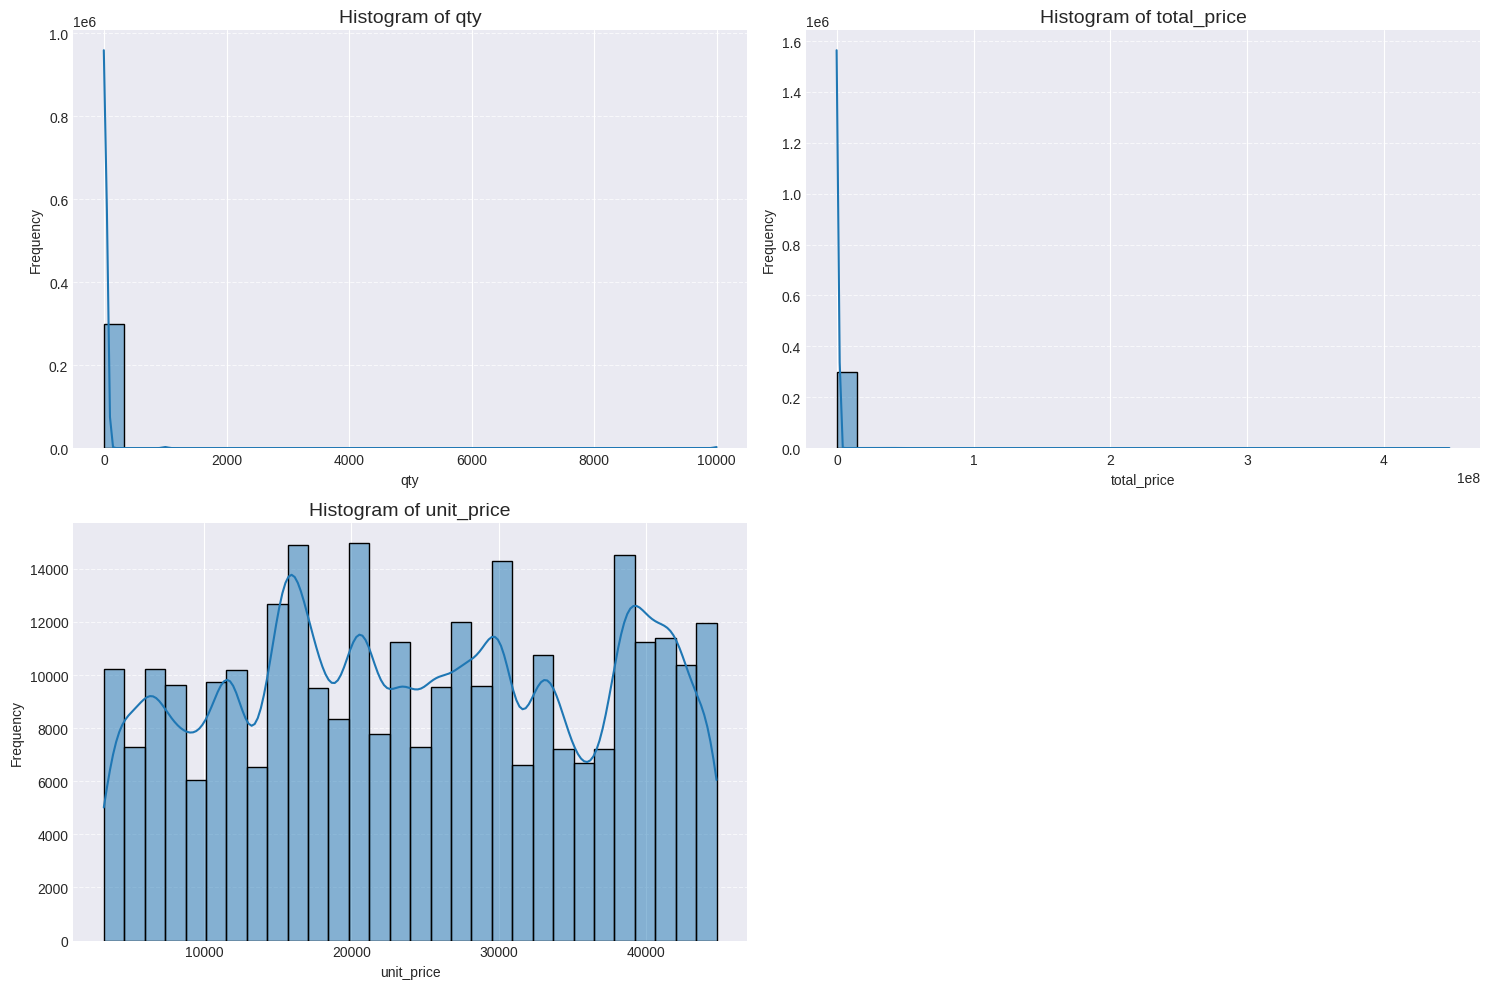

In [230]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Count plots
num_plots = len(numerical_cols.columns)
num_rows = (num_plots + 1) // 2
num_cols_subplot = 2

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numerical_cols.columns):
    plt.subplot(num_rows, num_cols_subplot, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Boxplot**

/tmp/ipykernel_4067/3692807240.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis') # Generate boxplot
/tmp/ipykernel_4067/3692807240.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis') # Generate boxplot
/tmp/ipykernel_4067/3692807240.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis') # Generate boxplot


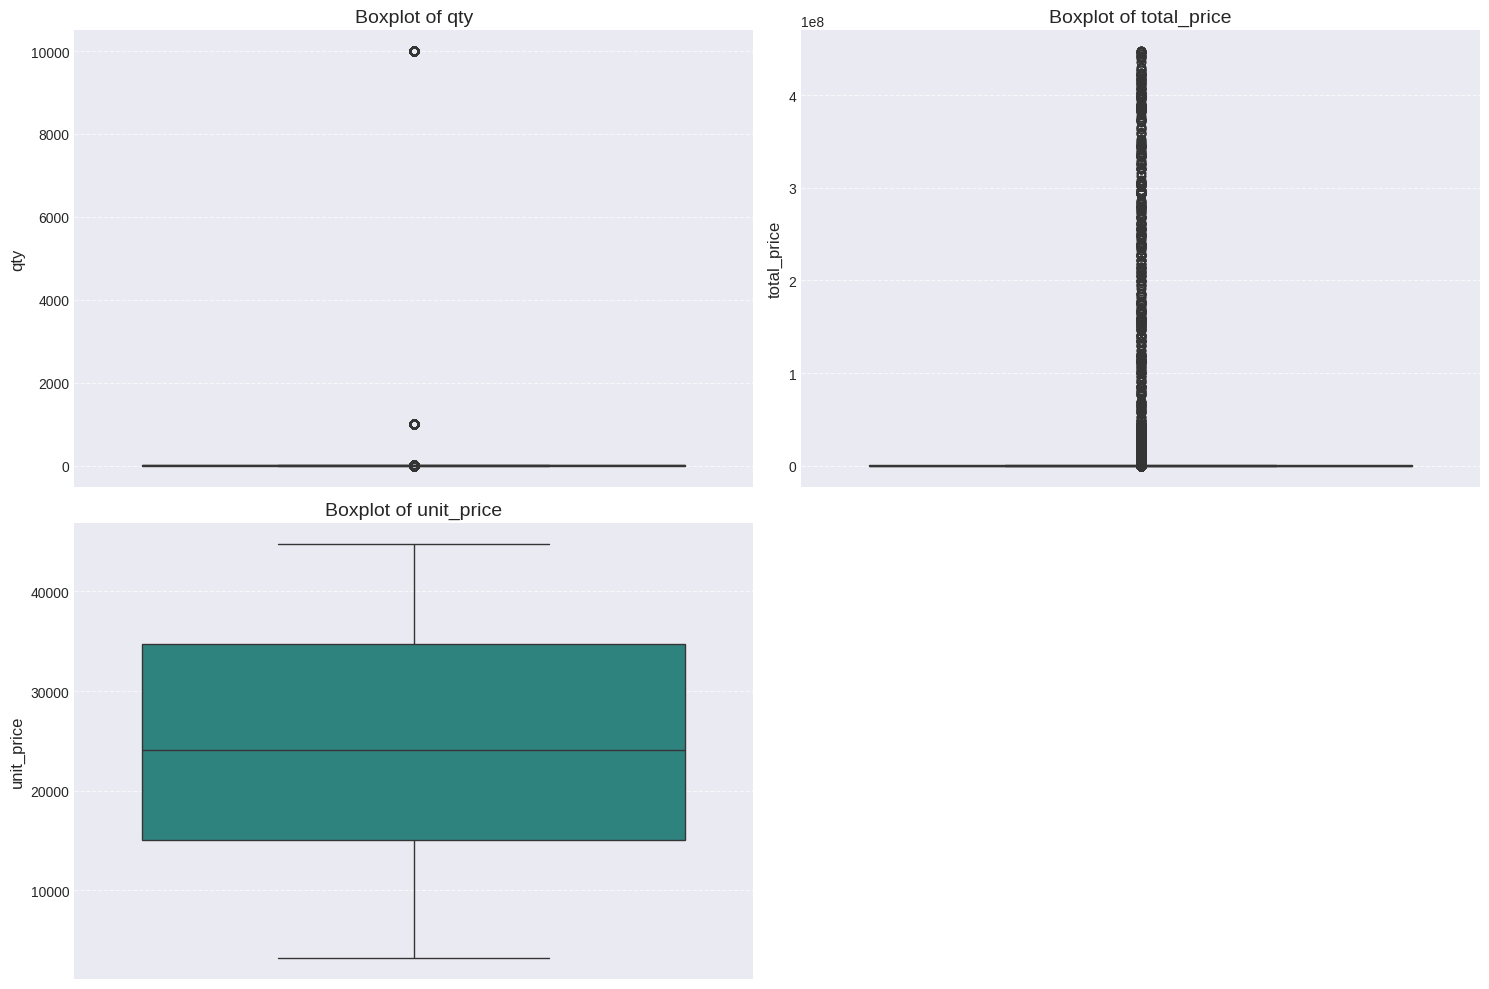

In [231]:
# Identify numerical columns in Transactions
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Visualize outliers using box plots for each numerical column
num_plots = len(numerical_cols.columns)
num_rows = (num_plots + 1) // 2  # Calculate number of rows needed (2 plots per row)
num_cols_subplot = 2

plt.figure(figsize=(15, 5 * num_rows)) # Adjust figure size based on the number of plots

for i, col in enumerate(numerical_cols.columns):
    plt.subplot(num_rows, num_cols_subplot, i + 1) # Create subplot
    sns.boxplot(y=df[col], palette='viridis') # Generate boxplot
    plt.title(f'Boxplot of {col}', fontsize=14) # Add title
    plt.ylabel(col, fontsize=12) # Add y-label
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plots

## 📊 Rencana Analisis Distribusi & Penanganan Outlier

Berdasarkan analisis histogram dan Boxlplot  konteks bisnis retail (POS Alfamart), Mmayoritas jumlah pembelian normal namun ada beberapa jumlah pembelian yang extreme (outlier) yang perlu di teliti lebih lanjut.

Tabel berikut merangkum interpretasi dan rencana tindakan untuk setiap variabel utama:

| Nama Variabel | Status Outlier | Penjelasan Konteks | **Action Plan (Tindakan)** |
| :--- | :--- | :--- | :--- |
| **`qty`** | 🔴 Perlu Investigasi | Terdapat nilai sangat tinggi (hingga ribuan) yang tidak umum untuk transaksi retail normal. Bisa disebabkan oleh double scan kasir, pembelian dalam jumlah besar, atau anomali sistem. | **VALIDASI & FILTER**. Identifikasi transaksi ekstrem, klasifikasikan antara valid (bulk purchase) vs error. Data error dapat dihapus atau diperbaiki. |
| **`total_price`** | 🔴 Turunan dari `qty` | Nilai ekstrem mengikuti pola `qty`. Jika qty tinggi, maka total_price otomatis tinggi. | **DEPENDENT CHECK**. Validasi konsistensi dengan rumus `qty × unit_price`. Jika tidak sesuai → indikasi error. |
| **`unit_price`** | 🟢 Stabil | Distribusi relatif normal tanpa nilai ekstrem. Variasi harga mencerminkan perbedaan produk. | **KEEP**. Tidak perlu penanganan khusus, data dianggap bersih dan valid. |

---

## 🧠 Rangkuman Temuan

1. **Outlier pada `qty` adalah fokus utama**, karena berpotensi menunjukkan:
   - Error kasir (double scanning)
   - Pembelian tidak wajar (potensi abuse/pemborongan)
   - Masalah sistem POS

2. **`total_price` bukan sumber masalah utama**, melainkan efek dari `qty`

3. **`unit_price` relatif aman**, sehingga dapat digunakan sebagai baseline validasi

---

## 🚀 Rekomendasi Analisis Lanjutan

- Lakukan deteksi outlier menggunakan metode IQR/Z-score
- Validasi transaksi ekstrem secara business logic
- Gunakan outlier sebagai sinyal untuk:
  - evaluasi SOP kasir
  - deteksi transaksi tidak wajar

# **Mencari tahu Kasir yang melakukan Scan Transaksi yang tidak sesuai SOP**

In [232]:
df['qty'].unique()

array([   1,    2,    3,   12,   -5,   24,    5,  999, 9999,   -1])

**Product Category yang mengalami jumlah scan abnormal**

In [234]:
abnormal_transactions = df[(df['qty'] > 30)]

# Group by product and count the occurrences of abnormal scans
abnormal_scans_by_product = abnormal_transactions.groupby(['category'])['sku_id'].count().reset_index(name='abnormal_scan_count')

# Sort to see the products with the most abnormal scans
abnormal_scans_by_product = abnormal_scans_by_product.sort_values(by='abnormal_scan_count', ascending=False)

display(abnormal_scans_by_product)

,category,abnormal_scan_count
2,Food & Staples,616
1,Cigarettes,315
3,Personal Care,299
0,Beverage,287


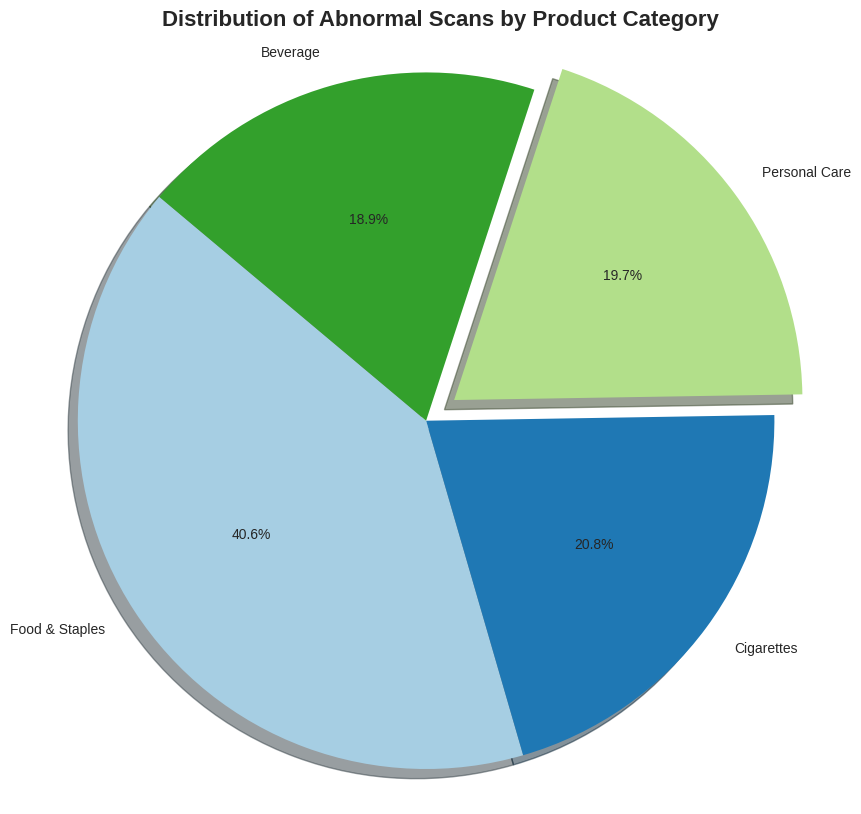

In [235]:
# Prepare data for the pie chart
labels = abnormal_scans_by_product['category']
sizes = abnormal_scans_by_product['abnormal_scan_count']

# Define a color palette and explode for an eye-catching effect
colors = sns.color_palette('Paired', len(labels)) # Using a Paired palette for distinct categories
explode = [0] * len(labels) # Initialize explode for all slices

# Find the index of the largest slice to explode it
largest_slice_index = sizes.idxmax()
explode[largest_slice_index] = 0.1 # Explode the largest slice by 10%

plt.figure(figsize=(10, 10)) # Set a larger figure size for better visibility
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%', # Display percentage with one decimal place
        shadow=True,
        startangle=140)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Abnormal Scans by Product Category', fontsize=16, fontweight='bold')
plt.show()

# **Data Insight**

Berdasarkan Grafik Pie Chart menunjukan bahwa produk yang paling banyak di scan berkali-kali pada produk **Food & Staples**, hal ini bisa menjadi masukan bagi tim HRD untuk lebih fokus biaya training pada produk **Food & Staples**.


In [236]:
abnormal_transactions = df[df['qty']>30]

# Calculate the number of transactions per store
abnormal_transactions = df.groupby('store_id')['receipt_id'].nunique().reset_index()

# Rename the 'receipt_id' column to 'transaction_error'
abnormal_transactions.rename(columns={'receipt_id': 'transaction_error'}, inplace=True)

# Display the aggregated table
top_10_Store_need_Training = abnormal_transactions.sort_values(by = 'transaction_error', ascending = False).head(10)

top_10_Store_need_Training

,store_id,transaction_error
941,SAT-0942,362
160,SAT-0161,360
971,SAT-0972,349
652,SAT-0653,345
656,SAT-0657,343
390,SAT-0391,343
69,SAT-0070,343
904,SAT-0905,342
415,SAT-0416,342
764,SAT-0765,342


/tmp/ipykernel_4067/761735448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='store_id', y='transaction_error', data=top_10_Store_need_Training, palette='viridis')
/tmp/ipykernel_4067/761735448.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot


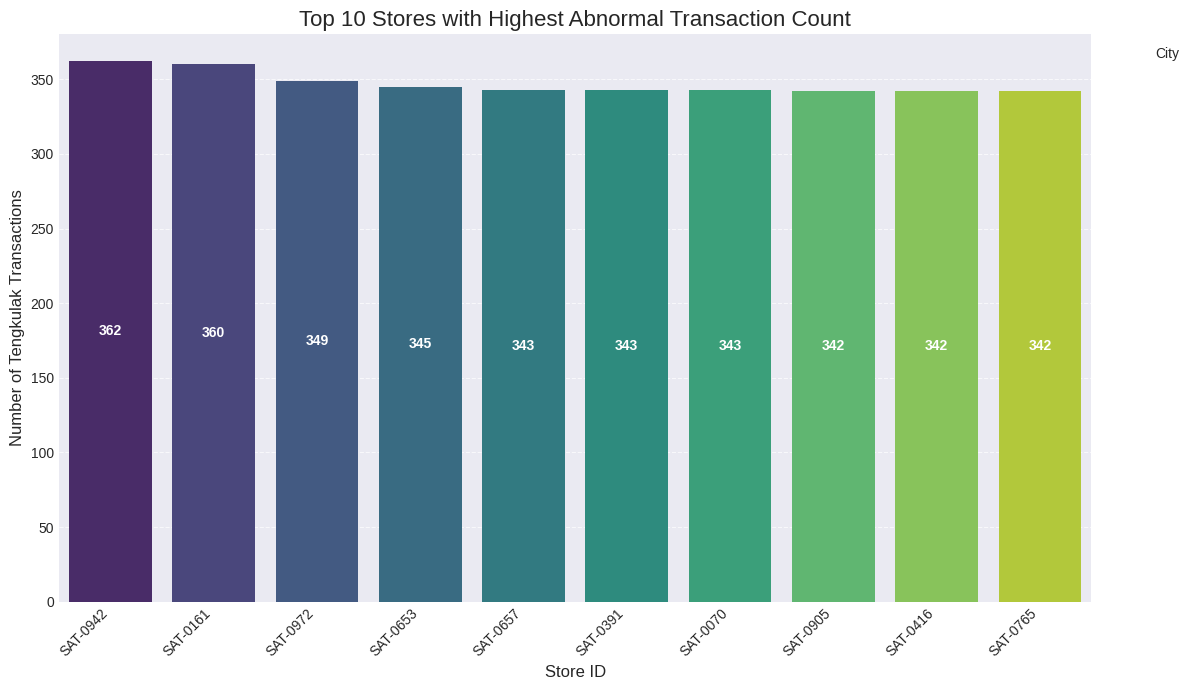

In [237]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='store_id', y='transaction_error', data=top_10_Store_need_Training, palette='viridis')
plt.title('Top 10 Stores with Highest Transaction Counts', fontsize=16)
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels inside bars with white color
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,
        p.get_height() / 2., # Position text in the middle of the bar
        '{:.0f}'.format(p.get_height()),
        fontsize=10,
        color='white',
        fontweight='bold',
        ha='center',
        va='center'
    )

plt.title('Top 10 Stores with Highest Abnormal Transaction Count', fontsize=16)
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Number of Tengkulak Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()



## 🏪 Top Stores with Highest Transaction Count

Analisis menunjukkan 10 gerai yang memiliki jumlah pembelian abnormal akibat kasir yang melakukan scan berkali kali.

### 🔍 Insight
- Jumlah transaksi pada tiap gerai relatif seragam (sekitar 340–360 transaksi)
- Tidak terdapat perbedaan signifikan antar gerai
- rata rata jumlah transaction yang melakukan scanning error sebesar 300.

**Hal ini mengindikasikan** banyak gerai yang telah melakukan scanning berlebihan secara tidak sadar hal ini menjadi pertimbangan bagi tim alfamart untuk melakukan pelatihan pada kasir mengenai sop cara scan kasir yang benar sesuai sop

# **Transaction Shrinkage**

In [238]:
Transaction_shrinkage = df[df['qty']<-1]

Transaction_shrinkage.head(1)

# Group by product and count the occurrences of abnormal scans
shrinkage_product = Transaction_shrinkage.groupby(['category'])['sku_id'].count().reset_index(name='abnormal_scan_count')

# Sort to see the products with the most abnormal scans
shrinkage_product = abnormal_scans_by_product.sort_values(by='abnormal_scan_count', ascending=False)

display(shrinkage_product)

,category,abnormal_scan_count
2,Food & Staples,616
1,Cigarettes,315
3,Personal Care,299
0,Beverage,287


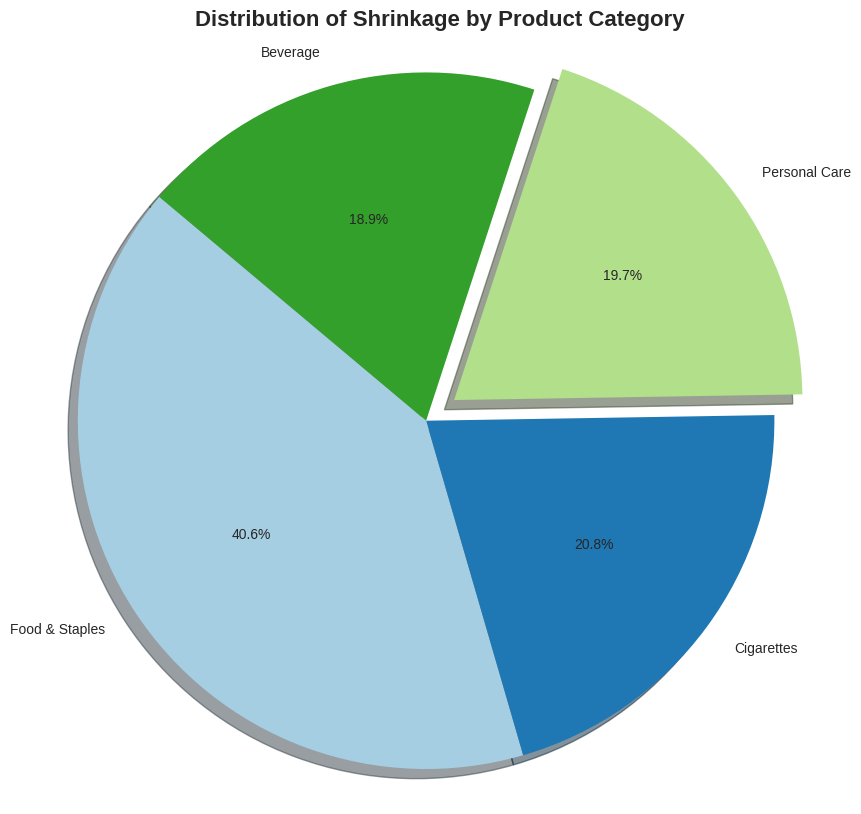

In [239]:
# Prepare data for the pie chart
labels = shrinkage_product['category']
sizes = shrinkage_product['abnormal_scan_count']

# Define a color palette and explode for an eye-catching effect
colors = sns.color_palette('Paired', len(labels)) # Using a Paired palette for distinct categories
explode = [0] * len(labels) # Initialize explode for all slices

# Find the index of the largest slice to explode it
largest_slice_index = sizes.idxmax()
explode[largest_slice_index] = 0.1 # Explode the largest slice by 10%

plt.figure(figsize=(10, 10)) # Set a larger figure size for better visibility
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%', # Display percentage with one decimal place
        shadow=True,
        startangle=140)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Shrinkage by Product Category', fontsize=16, fontweight='bold')
plt.show()

# **Data Insight**

Berdasarkan Grafik Piechart menunjukan bahwa produk yang paling banyak pada produk **Food & Staples**, maka dari itu tim management perlu mengeluarkan budget untuk menjaga produk **Food & Staples** tetap aman.   

In [240]:
# Redefine Transaction_shrinkage from the original df to ensure 'receipt_id' is present
Transaction_shrinkage = df[df['qty'] < -1]

# Calculate the number of transactions per store
Transaction_shrinkage_by_store = Transaction_shrinkage.groupby('store_id')['receipt_id'].nunique().reset_index()

# Rename the 'receipt_id' column to 'transaction_error'
Transaction_shrinkage_by_store.rename(columns={'receipt_id': 'transaction_error'}, inplace=True)

# Display the aggregated table
top_10_Store_need_Training = Transaction_shrinkage_by_store.sort_values(by='transaction_error', ascending=False).head(10)

top_10_Store_need_Training

,store_id,transaction_error
45,SAT-0090,4
140,SAT-0282,4
164,SAT-0325,4
238,SAT-0472,4
210,SAT-0409,4
365,SAT-0720,4
307,SAT-0600,4
242,SAT-0489,3
456,SAT-0894,3
0,SAT-0002,3


/tmp/ipykernel_4067/201362523.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='store_id', y='transaction_error', data=top_10_Store_need_Training, palette='magma')


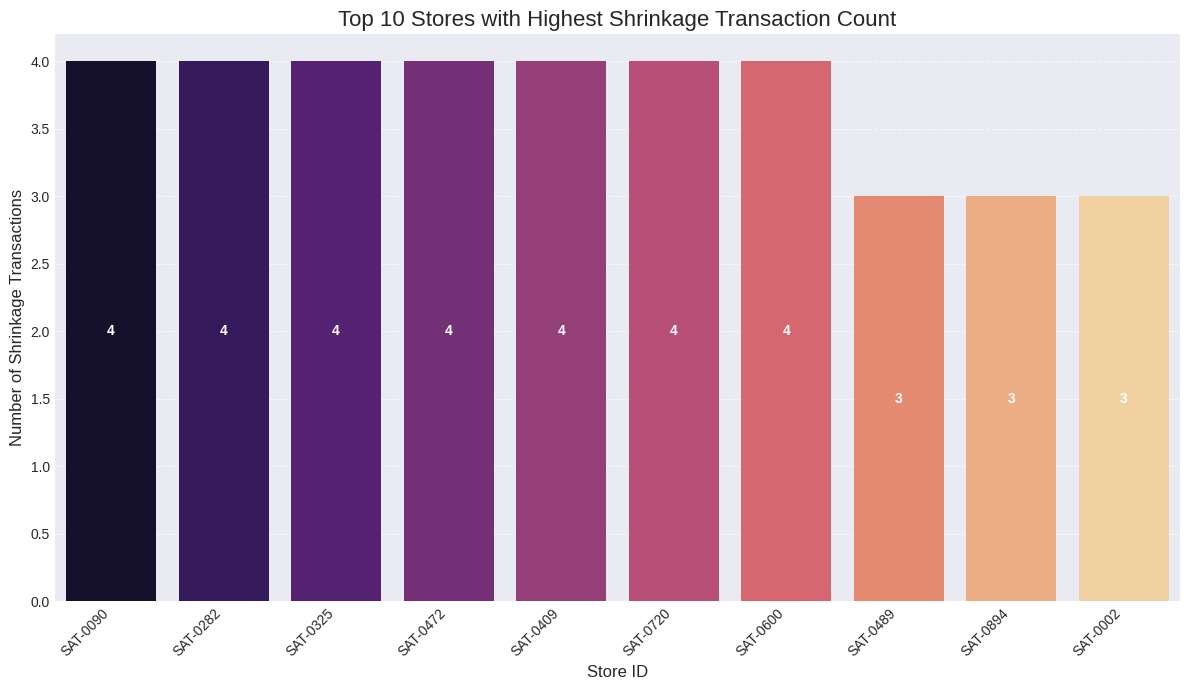

In [241]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='store_id', y='transaction_error', data=top_10_Store_need_Training, palette='magma')
plt.title('Top 10 Stores with Highest Shrinkage Transaction Count', fontsize=16)
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Number of Shrinkage Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels inside bars with white color
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,
        p.get_height() / 2., # Position text in the middle of the bar
        '{:.0f}'.format(p.get_height()),
        fontsize=10,
        color='white',
        fontweight='bold',
        ha='center',
        va='center'
    )

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## 📉 Shrinkage Analysis by Store

Analisis menunjukkan bahwa jumlah transaksi shrinkage pada Top 10 gerai relatif rendah dan konsisten, yaitu berkisar antara **3–4 transaksi per gerai**.

---

### 🔍 Insight
- Shrinkage terjadi dalam jumlah **rendah dan merata** di seluruh gerai  
- Tidak terdapat perbedaan signifikan antar gerai  
- Tidak ada indikasi adanya gerai dengan **risiko shrinkage yang dominan**  

---

### ⚠️ Interpretasi
- Shrinkage yang terjadi kemungkinan merupakan **Masalah klasik retail**, bukan masalah sistemik pada gerai tertentu  
- Pola yang merata menunjukkan bahwa risiko shrinkage bersifat **general (bukan terlokalisasi)**  
- Potensi penyebab dapat berasal dari:
  - selisih stok antara fisik
  - sistem akibat pencurian
  - kedaluwarsa
---

### 🧠 Business Implication
- Meskipun jumlahnya kecil, shrinkage tetap memiliki potensi **akumulasi kerugian** jika tidak dikontrol  
- Perlu pendekatan monitoring secara sistematis, bukan hanya fokus pada gerai tertentu  

---

### 📌 Kesimpulan
Shrinkage tidak menjadi isu kritikal saat ini karena terjadi dalam jumlah kecil dan merata. Namun, tetap diperlukan pengendalian untuk mencegah akumulasi kerugian di masa depan.

---

### 🚀 Rekomendasi
- Melakukan **audit berkala** pada seluruh gerai (bukan hanya top store)  
- Fokus pada **monitoring nilai kerugian**, bukan hanya jumlah transaksi  
- Mengintegrasikan shrinkage monitoring dengan:
  - evaluasi operasional kasir  
  - sistem kontrol inventory  

# **Data Cleaning - Handling Outliers**

In [242]:
# Remove rows with negative 'qty'
df_cln = df_cln[df_cln['qty'] >= 0]

print(f"Number of rows after removing negative quantities: {len(df_cln)}")
print(f"Minimum qty after cleaning: {df_cln['qty'].min()}")


Number of rows after removing negative quantities: 179118
Minimum qty after cleaning: 1


In [243]:
# Remove rows with abnormal  'qty'
df_cln = df_cln[(df['qty'] < 30) & (df['qty']>0)]

print(f"Number of rows after removing abnormal quantities: {len(df_cln)}")
print(f"Minimum qty after cleaning: {df_cln['qty'].min()}")


Number of rows after removing abnormal quantities: 178213
Minimum qty after cleaning: 1


/tmp/ipykernel_4067/3239813774.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_cln = df_cln[(df['qty'] < 30) & (df['qty']>0)]


## **Data Inconsistent**

In [244]:
# =========================
# CREATE NORMALIZED VERSION
# =========================

df_cln['product_norm'] = (
    df_cln['product_name']
    .str.lower()
    .str.replace(r'[^a-z0-9]', '', regex=True)
)

# =========================
# DETECT INCONSISTENCY
# =========================

product_inconsistency_check = (
    df_cln.groupby('product_norm')['product_name']
    .nunique()
    .reset_index(name='unique_count')
)

# Filter only inconsistent ones (>1 variation)
product_inconsistency_check = product_inconsistency_check[
    product_inconsistency_check['unique_count'] > 1
]

# =========================
# SHOW DETAIL
# =========================

product_inconsistent_detail = df_cln[
    df_cln['product_norm'].isin(product_inconsistency_check['product_norm'])
][['product_norm', 'product_name']].drop_duplicates().sort_values('product_norm')

display(product_inconsistent_detail)

,product_norm,product_name
2,pepsodent190g,Pepsodent 190g
9,pepsodent190g,PEPSODENT 190G
11,rokoksampoernamild,ROKOK SAMPOERNA MILD
76,rokoksampoernamild,Rokok Sampoerna Mild


## **1.Payment Method**


In [245]:
df['payment_method'].unique()

array(['BCA Debit', 'Cash', 'Tunai', 'CASH', 'ShopeePay', 'QRIS', 'OVO',
       'Gopay', 'qris', 'debit bca'], dtype=object)

In [246]:
# Check Payment Inconsistent
alfamart_Payment_inconsistent = (
    df[df['payment_method'].isin(['CASH','qris','debit bca','Tunai'])]
    [['store_id','payment_method']]
    .groupby(['store_id','payment_method'])
    .value_counts()
    .reset_index(name='count')
    .sort_values(
        by=['payment_method','count'],
        ascending=[True, False]
    )
    .groupby('payment_method')
    .head(5)
)

alfamart_Payment_inconsistent

,store_id,payment_method,count
1948,SAT-0488,CASH,69
3056,SAT-0765,CASH,69
712,SAT-0179,CASH,68
3028,SAT-0758,CASH,68
2872,SAT-0719,CASH,67
357,SAT-0090,Tunai,50
145,SAT-0037,Tunai,46
3245,SAT-0812,Tunai,46
1765,SAT-0442,Tunai,45
1841,SAT-0461,Tunai,45


In [247]:
# =========================
# DEFINE CORRECT PAYMENT METHODS
# =========================

correct_payment_methods = [
    'BCA Debit',
    'Cash',
    'ShopeePay',
    'OVO',
    'QRIS',
    'Gopay'
]

# =========================
# FIND INCONSISTENT PAYMENT METHODS
# =========================

payment_inconsistent = (
    df[~df['payment_method'].isin(correct_payment_methods)]
    [['store_id', 'payment_method']]
    .groupby(['store_id', 'payment_method'])
    .value_counts()
    .reset_index(name='count')
    .sort_values(
        by=['payment_method', 'count'],
        ascending=[True, False]
    )
    .groupby('payment_method')
    .head(5)
)

payment_inconsistent

,store_id,payment_method,count
1948,SAT-0488,CASH,69
3056,SAT-0765,CASH,69
712,SAT-0179,CASH,68
3028,SAT-0758,CASH,68
2872,SAT-0719,CASH,67
357,SAT-0090,Tunai,50
145,SAT-0037,Tunai,46
3245,SAT-0812,Tunai,46
1765,SAT-0442,Tunai,45
1841,SAT-0461,Tunai,45


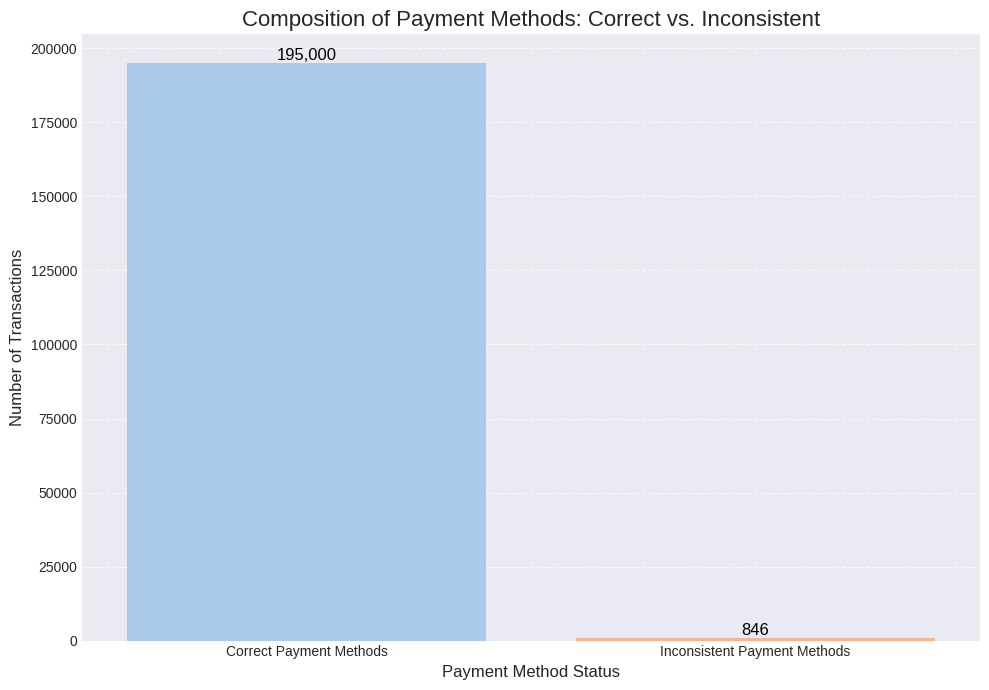

In [248]:
#Payment Correct
alfamart_Payment_correct= (df[df['payment_method'].isin(['Cash','QRIS','BCA Debit','ShopeePay','OVO','Gopay'])]
    [['store_id','payment_method']]
    .groupby(['store_id','payment_method'])
    .value_counts()
    .reset_index(name='count')
    .sort_values(
        by=['payment_method','count'],
        ascending=[True, False]
    ))

# Calculate total counts for correct and inconsistent payments
total_correct_payments = alfamart_Payment_correct['count'].sum()
total_inconsistent_payments = payment_inconsistent['count'].sum()

# Create a Series for plotting
payment_composition = pd.Series(
    [total_correct_payments, total_inconsistent_payments],
    index=['Correct Payment Methods', 'Inconsistent Payment Methods']
)

# Prepare data for bar chart
labels = payment_composition.index
sizes = payment_composition.values

# Define colors for better visual distinction
colors = sns.color_palette('pastel')[0:len(labels)] # A pleasant color palette

plt.figure(figsize=(10, 7))
ax = sns.barplot(x=labels, y=sizes, palette=colors, hue=labels, legend=False)

# Add value labels on top of the bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '{:,.0f}'.format(p.get_height()),
            fontsize=12, color='black', ha='center', va='bottom')

plt.title('Composition of Payment Methods: Correct vs. Inconsistent', fontsize=16)
plt.xlabel('Payment Method Status', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 📊 Ringkasan Hasil

Visualisasi menunjukkan perbandingan antara data yang konsisten dan tidak konsisten:

- ✅ Correct Payment Methods: **195,000 transaksi**
- ❌ Inconsistent Payment Methods: **846 transaksi**

📌 Artinya:
> **Lebih dari 99% data payment method sudah konsisten**


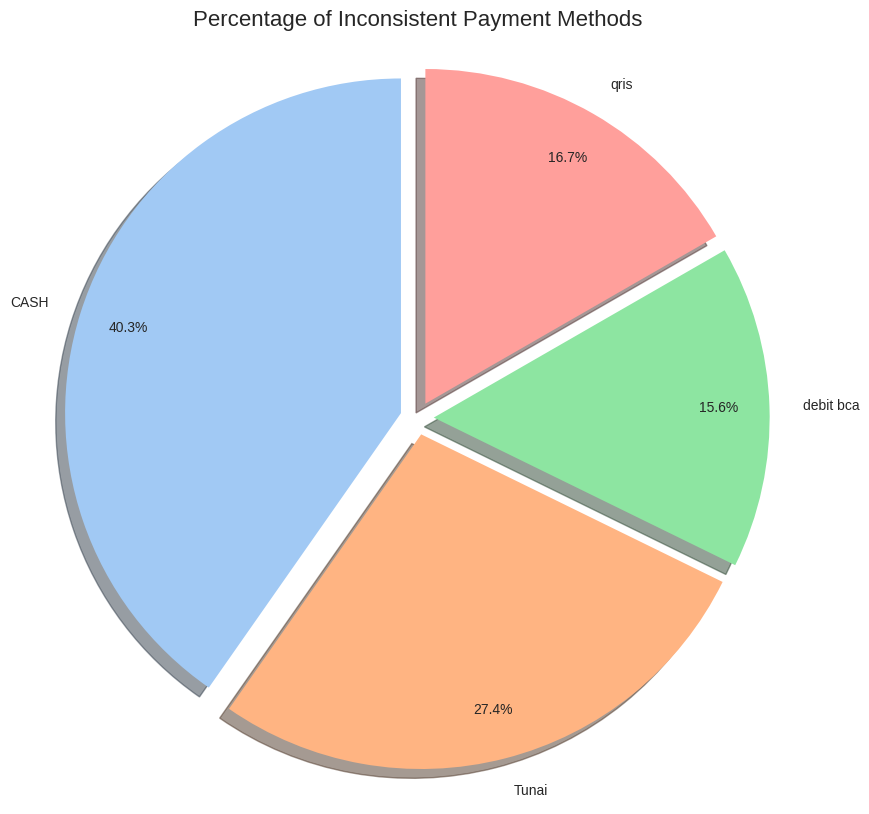

In [249]:
# Aggregate counts by payment method from the inconsistent data
summary_inconsistent_payments = alfamart_Payment_inconsistent.groupby('payment_method')['count'].sum().reset_index()

# Calculate the total count of all inconsistent payments
total_inconsistent_count = summary_inconsistent_payments['count'].sum()

# Calculate percentage for each inconsistent payment method
summary_inconsistent_payments['percentage'] = (summary_inconsistent_payments['count'] / total_inconsistent_count) * 100

# Prepare data for pie chart
labels = summary_inconsistent_payments['payment_method']
sizes = summary_inconsistent_payments['percentage']

# Define colors and explode for an eye-catching effect
colors = sns.color_palette('pastel')[0:len(labels)] # A pleasant color palette
explode = [0.05] * len(labels) # Slightly separate each slice for emphasis

plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=explode, shadow=True, pctdistance=0.85)
plt.title('Percentage of Inconsistent Payment Methods', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## 💳 Payment Method Inconsistency Analysis

Distribusi metode pembayaran menunjukkan adanya inkonsistensi dalam pencatatan, di mana metode yang sama direpresentasikan dengan label berbeda, karena kesalahanpenulisan huruf kapital, atau penulisan metode pembayaran yang sinonim seperti pada pembayaraN cASH yang dimana :
  - "CASH" (40.3%)
  - "Tunai" (27.4%)

**Hal ini menunjukkan tidak adanya standardisasi input data**

### ⚠️ Dampak
- Pengaruh siginifikan pada Cash terlihat lebih kecil dari sebenarnya
- Potensi kesalahan dalam reporting dan pengambilan keputusan

### 🧠 Kesimpulan
Masalah utama bukan sekadar typo, tetapi **tidak adanya data standardization pada sistem POS**

### 🚀 Rekomendasi
 Tim manajemen disarankan untuk melakukan standarisasi metode pembayaran dengan mengubah sistem input pada POS menjadi berbasis pilihan (dropdown). Dengan sistem ini, kasir hanya perlu memilih metode pembayaran yang telah ditentukan, tanpa melakukan pengetikan manual.

Contoh menu pilihan dropdown untuk  metode pembayaran:
- **BCA Debit**
- **Cash**
- **ShopeePay**
- **OVO**
- **QRIS**
- **GoPay**

Dengan penerapan sistem ini, diharapkan pencatatan metode pembayaran menjadi lebih konsisten, sehingga mempermudah proses pelaporan keuangan, meningkatkan akurasi data.

## **2.Product Name**

In [250]:
# =========================
# DEFINE CORRECT PRODUCT NAMES
# =========================

correct_products = [
    'Indomie Goreng',
    'Minyak Goreng Bimoli 2ml',
    'Bimoli Pouch 2000ml'
    'Air Mineral Aqua',
    'Aqua botol 600 ml',
    'Rokok Sampoerna Mild',
    'Pepsodent 190g'
]

# =========================
# FIND TYPO / INCONSISTENT PRODUCT NAMES
# =========================

product_inconsistent = (
    df_cln[~df_cln['product_name'].isin(correct_products)]  # NOT in correct list = typo
    [['product_name']]
    .groupby(['product_name'])
    .value_counts()
    .reset_index(name='count')
    .sort_values(
        by=['product_name', 'count'],
        ascending=[True, False]
    )
    .groupby('product_name')
    .head(5)
)

product_inconsistent

,product_name,count
0,AQ btl 600,7504
1,Air Mineral Aqua,14436
2,Aqua 600ml,11784
3,Bimoli Pouch 2000ml,12347
4,INDOMIE MIE GORENG,9567
5,Indm Grg,12899
6,Minyak Bimoli 2L,11339
7,Mnyk Goreng Bimoli,15640
8,PEPSODENT 190G,16105
9,ROKOK SAMPOERNA MILD,19147


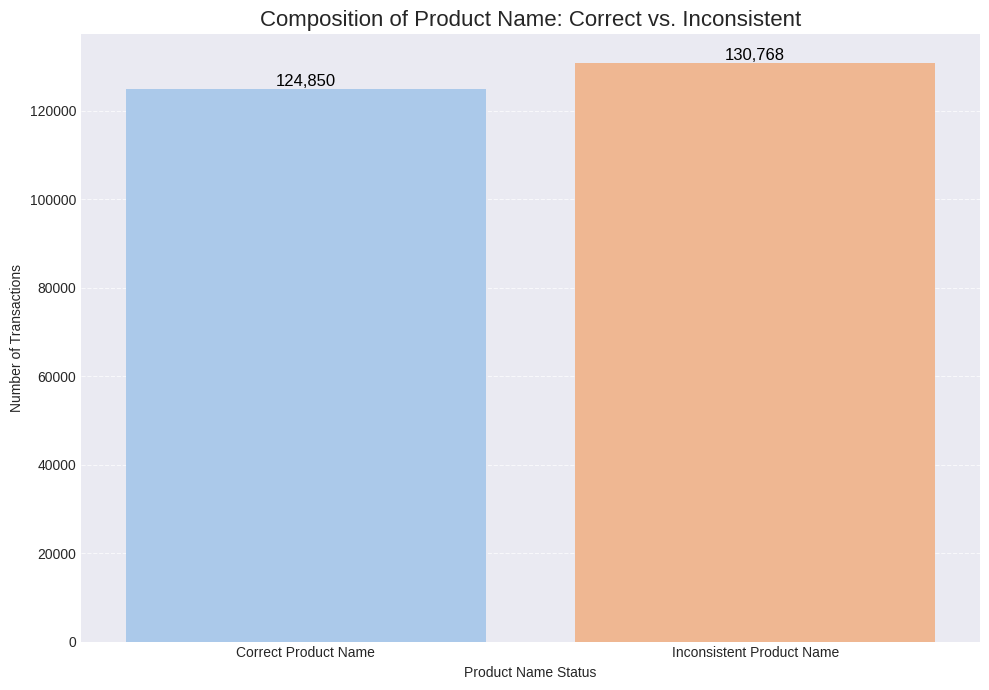

In [251]:
# =========================
# CALCULATE CORRECT PRODUCT NAMES
# =========================

# Assuming 'correct_products' and 'df_cln' are defined in previous cells
Product_Name_correct = (
    df[df['product_name'].isin([
        'Indomie Goreng',
        'Minyak Goreng Bimoli 2ml',
        'Bimoli Pouch 2000ml',
        'Air Mineral Aqua',
        'Aqua botol 600 ml',
        'Rokok Sampoerna Mild',
        'Pepsodent 190g'
    ])]  # Filter data dulu
    .groupby('product_name')  # Group by product_name
    .size()  # Count occurrences
    .reset_index(name='count')  # Convert to DataFrame
)
# =========================

# TOTAL COUNT
# =========================
Total_Product_Name_correct = Product_Name_correct['count'].sum()
Total_Product_Name_inconsistent = product_inconsistent['count'].sum()

# =========================
# CREATE SERIES
# =========================
product_composition = pd.Series(
    [Total_Product_Name_correct, Total_Product_Name_inconsistent],
    index=['Correct Product Name', 'Inconsistent Product Name']
)

# =========================
# PREPARE DATA
# =========================
labels = product_composition.index
sizes = product_composition.values

# =========================
# PLOT
# =========================
colors = sns.color_palette('pastel')[0:len(labels)]

plt.figure(figsize=(10, 7))
ax = sns.barplot(x=labels, y=sizes, palette=colors, hue=labels, legend=False)

# Label
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,
        p.get_height(),
        '{:,.0f}'.format(p.get_height()),
        fontsize=12,
        color='black',
        ha='center',
        va='bottom'
    )

plt.title('Composition of Product Name: Correct vs. Inconsistent', fontsize=16)
plt.xlabel('Product Name Status')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



## 📊 Ringkasan Hasil

Visualisasi menunjukkan perbandingan antara data yang konsisten dan tidak konsisten:

- ✅ Correct Product Name: **124,850 transaksi**
- ❌ Inconsistent Product Name: **130,768 transaksi**

📌 Artinya:
> **Lebih dari 50% data product name masih tidak konsisten**


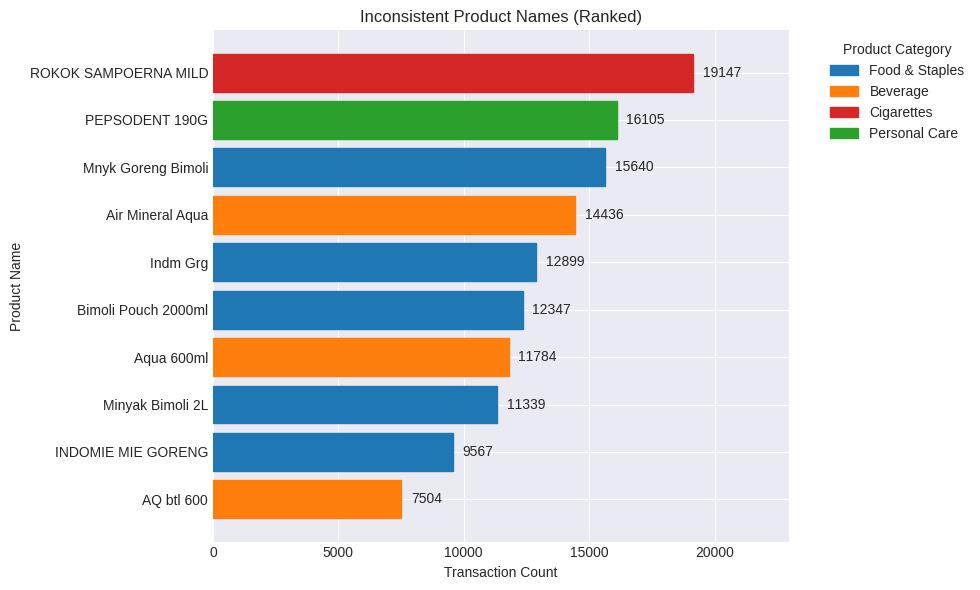

In [252]:
# =========================
# ENSURE CATEGORY EXISTS
# =========================

if 'category' not in product_inconsistent.columns:
    product_inconsistent = product_inconsistent.merge(
        df_cln[['product_name', 'category']].drop_duplicates(),
        on='product_name',
        how='left'
    )

# =========================
# SORT DATA (ONLY BY COUNT DESC)
# =========================

product_inconsistent = product_inconsistent.sort_values(
    by='count',
    ascending=False
)

# =========================
# COLOR MAPPING
# =========================

category_colors = {
    'Food & Staples': 'tab:blue',
    'Beverage': 'tab:orange',
    'Cigarettes': 'tab:red',
    'Personal Care': 'tab:green'
}

colors = product_inconsistent['category'].map(category_colors)

# =========================
# PLOT BARH
# =========================

plt.figure(figsize=(10,6))

bars = plt.barh(
    product_inconsistent['product_name'],
    product_inconsistent['count']
)

# Apply colors
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Highest at top
plt.gca().invert_yaxis()

# =========================
# LEGEND
# =========================

import matplotlib.patches as mpatches # Import mpatches

legend_handles = [
    mpatches.Patch(color=color, label=cat)
    for cat, color in category_colors.items()
]

plt.legend(handles=legend_handles, title='Product Category',
           bbox_to_anchor=(1.05, 1), loc='upper left')

# =========================
# LABELING
# =========================

plt.title('Inconsistent Product Names (Ranked)')
plt.xlabel('Transaction Count')
plt.ylabel('Product Name')

max_count = product_inconsistent['count'].max()
plt.xlim(0, max_count * 1.2)

for i, v in enumerate(product_inconsistent['count']):
    plt.text(v + max_count * 0.02, i, str(v), va='center')

plt.tight_layout()
plt.show()

## 🏷️ Product Name Inconsistency Analysis

Berdasarkan analisis terhadap kolom `product_name`, ditemukan adanya **inkonsistensi dalam penulisan nama produk**.

Hal ini terlihat dari beberapa produk yang sebenarnya sama, namun ditulis dengan variasi berbeda, seperti:
- "Indm Grg" vs "INDOMIE MIE GORENG"
- "Mnky Goreng Bimoli" vs "Minyak Bimoli 2L"
- "AQ btl 600" vs "Aqua 600ml"

---

## 🔍 Insight

- Produk yang sama tercatat sebagai entitas berbeda akibat perbedaan penulisan
- Inkonsistensi terjadi pada:
  - singkatan (abbreviation)
  - typo
  - perbedaan format penulisan (huruf besar/kecil, satuan, dll)

📌 Insight tambahan dari grafik:
- Jumlah data **inkonsisten lebih tinggi dibandingkan data yang sudah benar**
- Ini menunjukkan bahwa masalah data quality sudah berada di level **signifikan (bukan minor issue)**

---

## ⚠️ Dampak ke Bisnis

Inkonsistensi ini tidak hanya masalah teknis, tetapi berdampak langsung ke kualitas analisis bisnis:

### 1. 📊 Reporting Tidak Akurat
- Penjualan produk akan **terpecah menjadi beberapa entitas**
- Contoh:
  - "Aqua 600ml" dan "AQ btl 600" dihitung sebagai produk berbeda
- Akibatnya:
  - total penjualan per produk menjadi **underestimated**

---

### 2. 📉 Kesalahan Pengambilan Keputusan
- Produk yang sebenarnya best seller bisa terlihat biasa saja
- Produk tertentu bisa terlihat memiliki performa rendah padahal sebenarnya tinggi

---

### 3. 📦 Supply Chain & Inventory Issue
- Perencanaan stok menjadi tidak akurat
- Risiko:
  - overstock
  - atau stockout

---

## 🧠 Kesimpulan

Masalah utama bukan hanya typo, tetapi:
> **tidak adanya standardisasi master data produk**

📌 Berdasarkan data:
- Tingkat inkonsistensi sudah lebih dari 50%
- Ini menandakan perlunya **intervensi sistem, bukan hanya cleaning manual**

Hal ini menyebabkan:
- fragmentasi data
- penurunan kualitas insight
- potensi kesalahan dalam pengambilan keputusan bisnis

---

## 🚀 Rekomendasi

- Standarisasi nama produk menggunakan:
  - master data SKU sebagai referensi utama
- Implementasi:
  - dropdown / auto-complete di sistem POS
- Lakukan data cleaning:
  - mapping nama produk tidak konsisten ke format standar
- Tambahkan validasi input:
  - untuk mencegah kesalahan penulisan di masa depan

---

## **Data Handling Product Name**

In [253]:
# =========================
# DEFINE CORRECT PRODUCT NAMES
# =========================
correct_products = [
    'Indomie Goreng',
    'Minyak Goreng Bimoli 2ml',
    'Bimoli Pouch 2000ml',
    'Air Mineral Aqua',
    'Aqua botol 600 ml',
    'Rokok Sampoerna Mild',
    'Pepsodent 190g'
]

# =========================
# CREATE MAPPING (TYPO → CLEAN)
# =========================
product_mapping = {
    # Food
    'Indm Grg': 'Indomie Goreng',
    'INDOMIE MIE GORENG': 'Indomie Goreng',

    'Mnyk Goreng Bimoli': 'Minyak Goreng Bimoli 2ml',
    'Minyak Bimoli 2L': 'Minyak Goreng Bimoli 2ml',

    # Beverage
    'Aqua 600ml': 'Aqua botol 600 ml',
    'AQ btl 600': 'Aqua botol 600 ml',

    # Cigarettes
    'ROKOK SAMPOERNA MILD': 'Rokok Sampoerna Mild',

    # Personal Care
    'PEPSODENT 190G': 'Pepsodent 190g'
}

# =========================
# APPLY CLEANING (IN-PLACE)
# =========================
df_cln['product_name'] = df_cln['product_name'].replace(product_mapping)

# =========================
# VALIDATION (CHECK REMAINING DIRTY DATA)
# =========================
remaining_inconsistent = df_cln.loc[
    ~df_cln['product_name'].isin(correct_products),
    'product_name'
].value_counts()

print("Remaining inconsistent product names:")
display(remaining_inconsistent)

# =========================
# FINAL CLEAN DATA PREVIEW
# =========================
clean_summary = (
    df_cln.groupby(['product_name', 'category'])['receipt_id']
    .nunique()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

display(clean_summary)

Remaining inconsistent product names:


,count
product_name,


,product_name,category,count
6,Rokok Sampoerna Mild,Cigarettes,37002
5,Pepsodent 190g,Personal Care,35784
3,Indomie Goreng,Food & Staples,32377
4,Minyak Goreng Bimoli 2ml,Food & Staples,26979
1,Aqua botol 600 ml,Beverage,19288
0,Air Mineral Aqua,Beverage,14436
2,Bimoli Pouch 2000ml,Food & Staples,12347


## **Data Handling Inconsistent Payment Method**

In [254]:
# =========================
# STEP 1 — STANDARDIZE FORMAT (VERY IMPORTANT)
# =========================

# Clean basic text issues
df_cln['payment_method_clean'] = (
    df_cln['payment_method']
    .str.strip()        # remove extra spaces
    .str.lower()        # normalize case
)

# =========================
# STEP 2 — CREATE MAPPING
# =========================

payment_mapping = {
    'cash': 'Cash',
    'tunai': 'Cash',

    'debit bca': 'BCA Debit',
    'bca debit': 'BCA Debit',

    'qris': 'QRIS',

    'ovo': 'OVO',
    'gopay': 'GoPay',
    'shopeepay': 'ShopeePay'
}

# =========================
# STEP 3 — APPLY MAPPING
# =========================

df_cln['payment_method_clean'] = df_cln['payment_method_clean'].replace(payment_mapping)

# =========================
# STEP 4 — HANDLE UNKNOWN VALUES
# =========================

# Capitalize fallback (for values not in mapping)
df_cln['payment_method_clean'] = df_cln['payment_method_clean'].str.title()

# =========================
# STEP 5 — VALIDATION (VERY IMPORTANT)
# =========================

correct_payment_methods = [
    'BCA Debit',
    'Cash',
    'ShopeePay',
    'OVO',
    'QRIS',
    'GoPay'
]

remaining_inconsistent_payment = df_cln.loc[
    ~df_cln['payment_method_clean'].isin(correct_payment_methods),
    'payment_method_clean'
].value_counts()

print("Remaining inconsistent payment methods:")
display(remaining_inconsistent_payment)

# =========================
# OPTIONAL — FINAL REPLACE ORIGINAL COLUMN
# =========================

df_cln['payment_method'] = df_cln['payment_method_clean']

Remaining inconsistent payment methods:


,count
payment_method_clean,
Bca Debit,26739
Gopay,17932
Qris,17735
Shopeepay,17694
Ovo,8922


## **Transaction Error**

Transaction error berupa transaksi yang terjadi sebelum tanggal Grand opening

###**Feature Enginering**

In [255]:
#data cleaning yang dimana memisahkan kolom trx_time menjadi dua table ->( trx_date & time_trx)
df['trx_time'] = pd.to_datetime(df['trx_time'])

df = df.assign(
    trx_date = df['trx_time'].dt.date,
    time_trx = df['trx_time'].dt.time
).drop(columns='trx_time')

df['open_date'] = pd.to_datetime(df['open_date']).dt.date

## 🧹 Data Cleaning: Pemisahan Kolom Tanggal dan Waktu Transaksi

Pada dataset awal, kolom `trx_time` masih dalam format **datetime gabungan** (tanggal dan waktu dalam satu kolom).  

Untuk mempermudah analisis, kolom ini dipisahkan menjadi dua bagian:

- `trx_date` → berisi **tanggal transaksi**
- `time_trx` → berisi **waktu transaksi**

---

### 🔧 Proses yang Dilakukan

1. Mengubah kolom `trx_time` ke format datetime  
2. Mengekstrak:
   - tanggal → `trx_date`
   - waktu → `time_trx`  
3. Menghapus kolom asli `trx_time` agar tidak redundan  
4. Menyesuaikan format `open_date` menjadi date saja  

---

### 🎯 Tujuan

- Mempermudah analisis berbasis:
  - **tanggal** (trend harian, bulanan, tahunan)
  - **waktu** (jam sibuk, pola transaksi per jam)
- Menghindari penggunaan kolom datetime yang terlalu kompleks  
- Meningkatkan fleksibilitas dalam eksplorasi data  

---

### 💡 Insight

Dengan pemisahan ini:
- Analisis seperti **peak hour**, **daily trend**, dan **seasonality** menjadi lebih mudah dilakukan  
- Data menjadi lebih **terstruktur dan siap untuk analisis lanjutan**

---

### 📌 Kesimpulan

Pemisahan kolom datetime menjadi tanggal dan waktu merupakan langkah penting dalam data preprocessing untuk meningkatkan **kualitas analisis dan interpretasi data transaksi**.

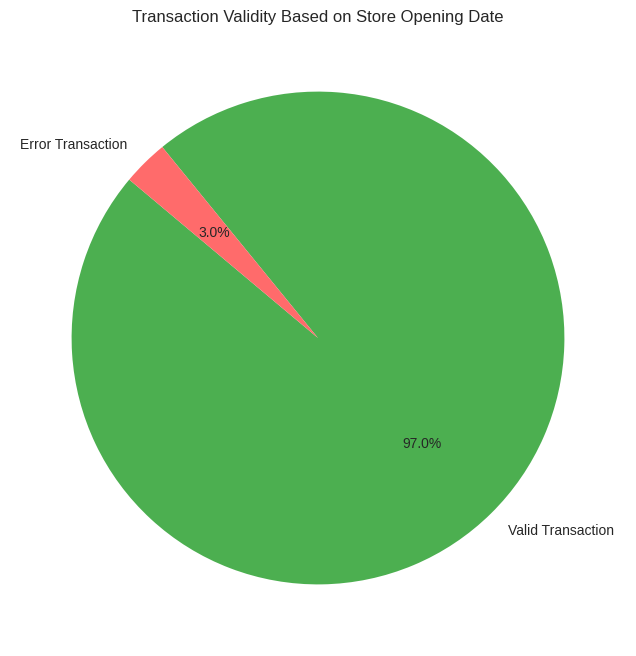

In [187]:
df['trx_status'] = df.apply(
    lambda x: 'Error Transaction' if pd.Timestamp(x['trx_date']) < pd.Timestamp(x['open_date']) else 'Valid Transaction',
    axis=1
)
trx_status_count = df['trx_status'].value_counts()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    trx_status_count,
    labels=trx_status_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4CAF50','#FF6B6B']
)

plt.title('Transaction Validity Based on Store Opening Date')

plt.show()

## **Data Insight**

Berdasarkan grafik Transaction Validity Based on Store Opening Date, terlihat bahwa sekitar **97% transaksi tercatat dengan valid**, sementara sekitar **3% transaksi termasuk dalam kategori error transaction** karena tercatat terjadi sebelum tanggal pembukaan gerai (grand opening).

Temuan ini menunjukkan bahwa secara umum sistem pencatatan transaksi pada Alfamart sudah berjalan dengan cukup baik karena sebagian besar transaksi tercatat secara valid. Namun demikian, keberadaan sekitar **3% error transaction** tetap perlu menjadi perhatian karena mengindikasikan adanya logical error pada data, seperti kemungkinan kesalahan sinkronisasi sistem POS, kesalahan konfigurasi waktu pada mesin kasir.


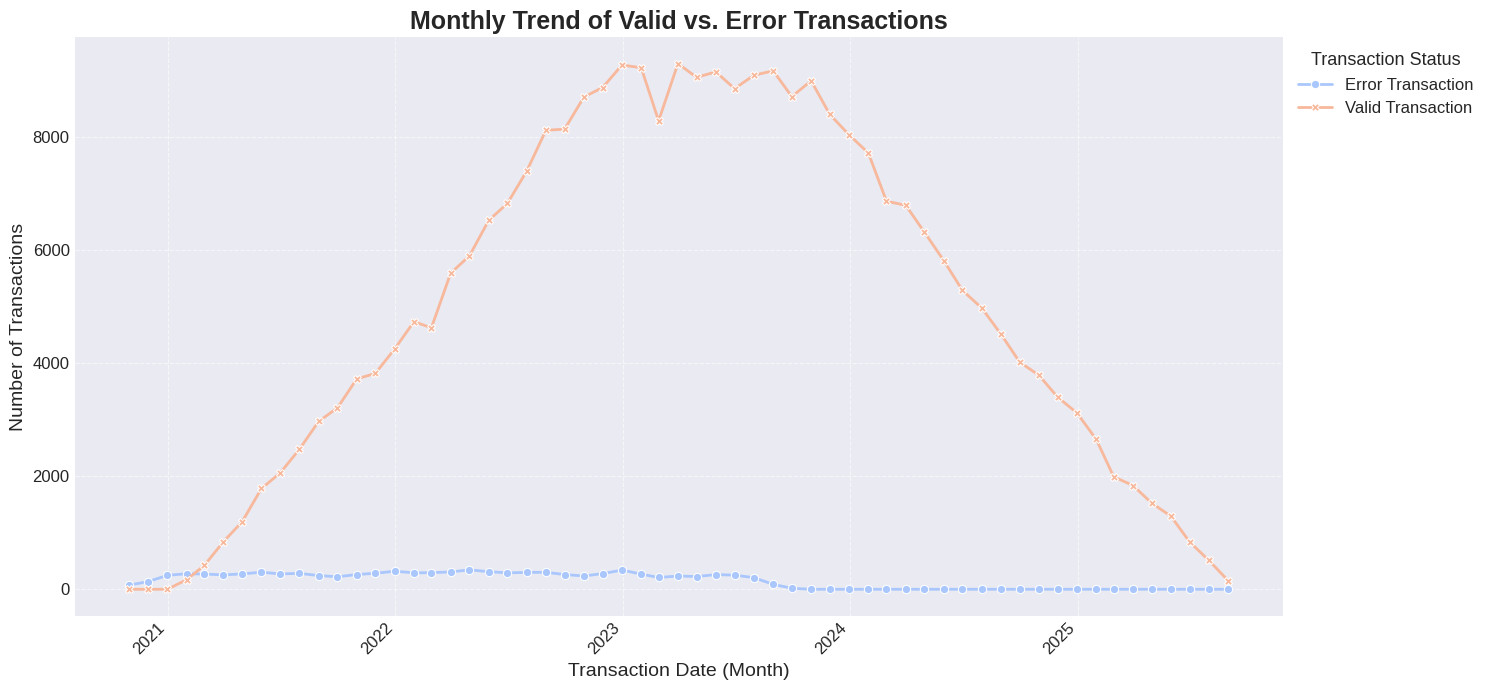

In [188]:
# Ensure trx_date is a datetime object for time-series plotting
df['trx_date'] = pd.to_datetime(df['trx_date'])

# Group by month and transaction status, then unstack to get separate columns for plotting
monthly_transactions = df.groupby([pd.Grouper(key='trx_date', freq='ME'), 'trx_status']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_transactions, markers=True, dashes=False, palette='coolwarm', linewidth=2)

plt.title('Monthly Trend of Valid vs. Error Transactions', fontsize=18, fontweight='bold')
plt.xlabel('Transaction Date (Month)', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.legend(title='Transaction Status', title_fontsize='13', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## **Data Insight**

Berdasarkan grafik Monthly Trend of Valid vs. Error Transactions, terlihat bahwa transaksi error terutama terjadi pada periode **2021 hingga awal 2023**. Setelah memasuki pertengahan **2023 hingga 2025**, jumlah error transaction menurun secara signifikan dan hampir tidak ditemukan lagi error pada periode tersebut.

Temuan ini menunjukkan bahwa permasalahan logical error kemungkinan terjadi pada fase awal sistem atau saat proses sinkronisasi data. Setelah periode tersebut, sistem pencatatan transaksi tampaknya telah diperbaiki sehingga transaksi dapat tercatat dengan lebih konsisten dan valid.

# **Data Handling Logical Error Transation**

In [189]:
# Tanggal transaksi yang error
df_cln = df[df['trx_date'] < df['open_date']]

df_cln.head()


,receipt_id,store_id,sku_id,member_id,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date,trx_date,time_trx,trx_status
20,RCP00000021,SAT-0115,SKU000119,MEM-10142,BCA Debit,1,35700.0,Minyak Bimoli 2L,Food & Staples,35700.0,Alfamart Sudirman 114,Surabaya,2022-05-07,2022-02-18,12:00:00,Error Transaction
58,RCP00000059,SAT-0609,SKU000385,NaN,QRIS,2,60400.0,Aqua 600ml,Beverage,30200.0,Alfamart Pahlawan 608,Semarang,2022-09-14,2022-07-20,05:00:00,Error Transaction
62,RCP00000063,SAT-0565,SKU000131,NaN,Tunai,5,208500.0,Mnyk Goreng Bimoli,Food & Staples,41700.0,Alfamart Sudirman 564,Bekasi,2022-02-22,2021-12-07,15:00:00,Error Transaction
79,RCP00000080,SAT-0957,SKU000273,MEM-10162,BCA Debit,24,957600.0,Rokok Sampoerna Mild,Cigarettes,39900.0,Alfamart Sudirman 956,Malang,2022-02-04,2021-11-17,14:00:00,Error Transaction
161,RCP00000162,SAT-0160,SKU000399,NaN,Cash,1,11400.0,Minyak Bimoli 2L,Food & Staples,11400.0,Alfamart Diponegoro 159,Bogor,2022-01-01,2021-12-18,14:00:00,Error Transaction


# **Section 4 : Data Analyst**

# **Estimasi Kerugian disebabkan kasir melakukan scan produk secara berulang-ulang**

In [190]:
qty_anomaly = df[df['qty']>24]

qty_anomaly

,receipt_id,store_id,sku_id,member_id,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date,trx_date,time_trx,trx_status
38,RCP00000039,SAT-0758,SKU000465,MEM-30457,ShopeePay,999,29370600.0,AQ btl 600,Beverage,29400.0,Alfamart Gatot Subroto 757,Bandung,2022-06-19,2023-12-20,17:00:00,Valid Transaction
294,RCP00000295,SAT-0897,SKU000203,MEM-34459,BCA Debit,999,38861100.0,Rokok Sampoerna Mild,Cigarettes,38900.0,Alfamart Diponegoro 896,Bogor,2023-03-26,2023-11-06,13:00:00,Valid Transaction
303,RCP00000304,SAT-0849,SKU000206,MEM-26332,debit bca,999,32267700.0,Bimoli Pouch 2000ml,Food & Staples,32300.0,Alfamart Sudirman 848,Surabaya,2022-01-27,2022-04-21,09:00:00,Valid Transaction
398,RCP00000399,SAT-0743,SKU000030,NaN,Cash,999,37262700.0,Rokok Sampoerna Mild,Cigarettes,37300.0,Alfamart Sudirman 742,Bogor,2021-08-26,2022-10-09,07:00:00,Valid Transaction
558,RCP00000559,SAT-0795,SKU000046,MEM-36632,Gopay,999,30369600.0,PEPSODENT 190G,Personal Care,30400.0,Alfamart Diponegoro 794,Malang,2022-07-19,2022-12-29,09:00:00,Valid Transaction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298465,RCP00298466,SAT-0668,SKU000399,MEM-02910,debit bca,999,11388600.0,Minyak Bimoli 2L,Food & Staples,11400.0,Alfamart Gatot Subroto 667,Bandung,2022-05-18,2022-02-10,09:00:00,Error Transaction
298571,RCP00298572,SAT-0276,SKU000100,MEM-42018,Cash,999,5794200.0,Air Mineral Aqua,Beverage,5800.0,Alfamart Gatot Subroto 275,Medan,2023-09-25,2024-10-01,17:00:00,Valid Transaction
298620,RCP00298621,SAT-0910,SKU000028,MEM-49113,Gopay,999,11388600.0,Aqua 600ml,Beverage,11400.0,Alfamart Pahlawan 909,Malang,2022-04-03,2023-11-12,12:00:00,Valid Transaction
298758,RCP00298759,SAT-0263,SKU000247,MEM-12366,QRIS,999,6393600.0,AQ btl 600,Beverage,6400.0,Alfamart Diponegoro 262,Bekasi,2022-02-07,2023-07-03,14:00:00,Valid Transaction


## **Estimasi kerugian perbulan**

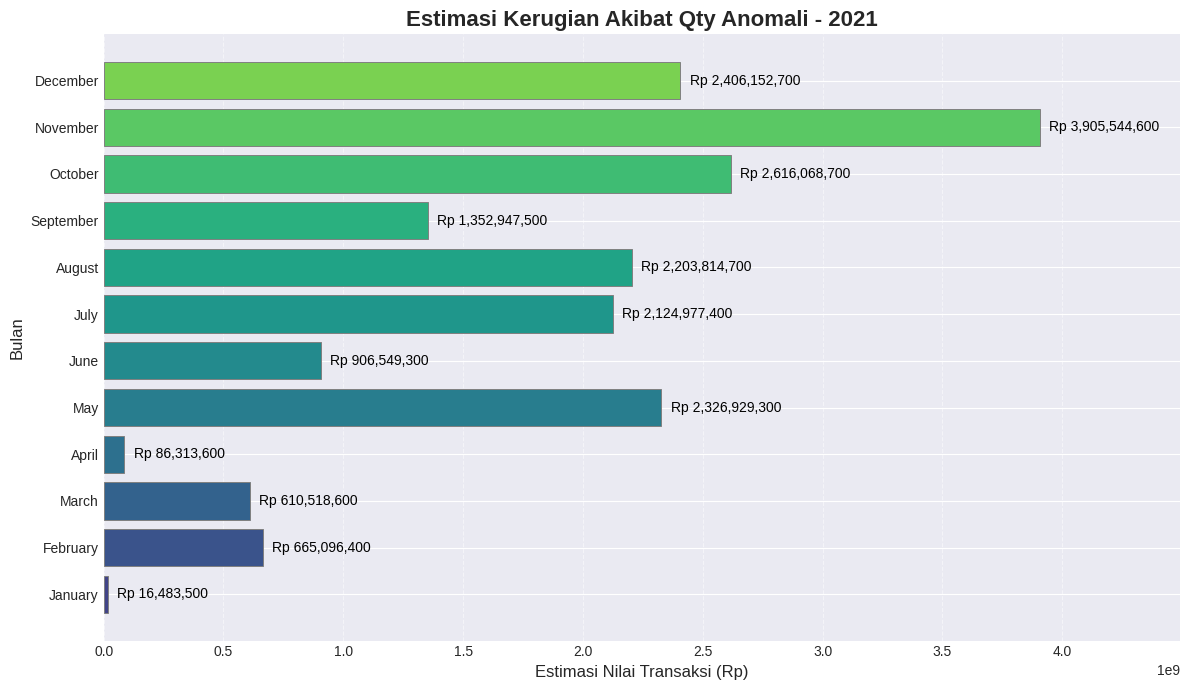

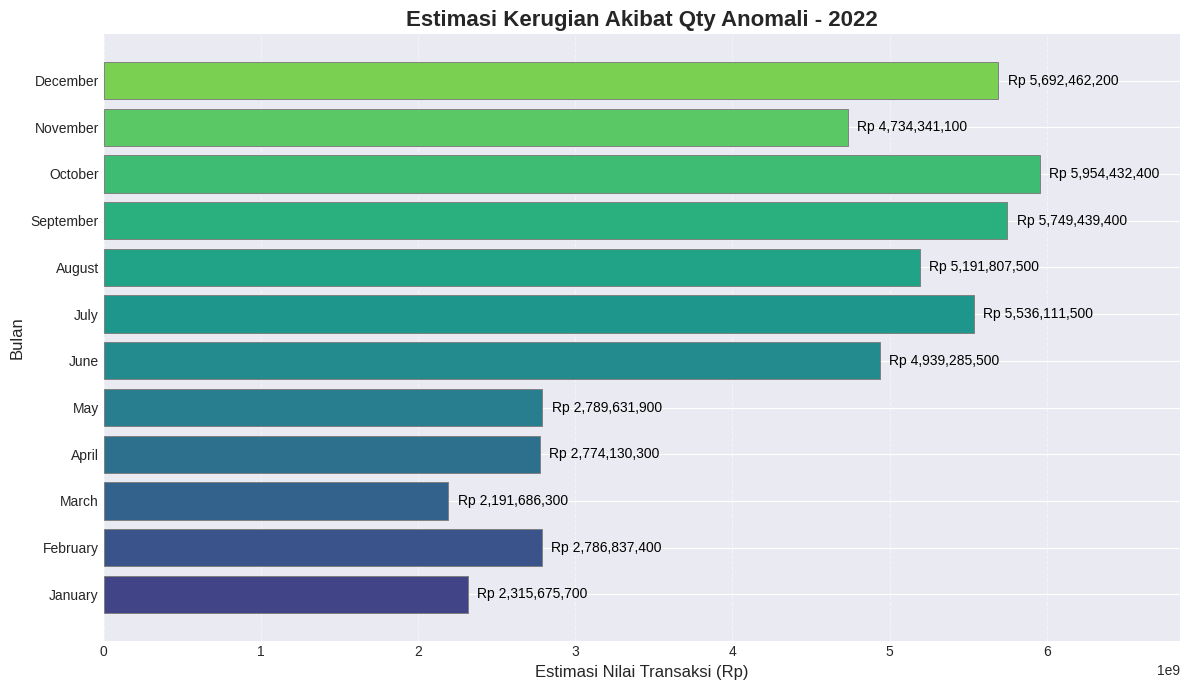

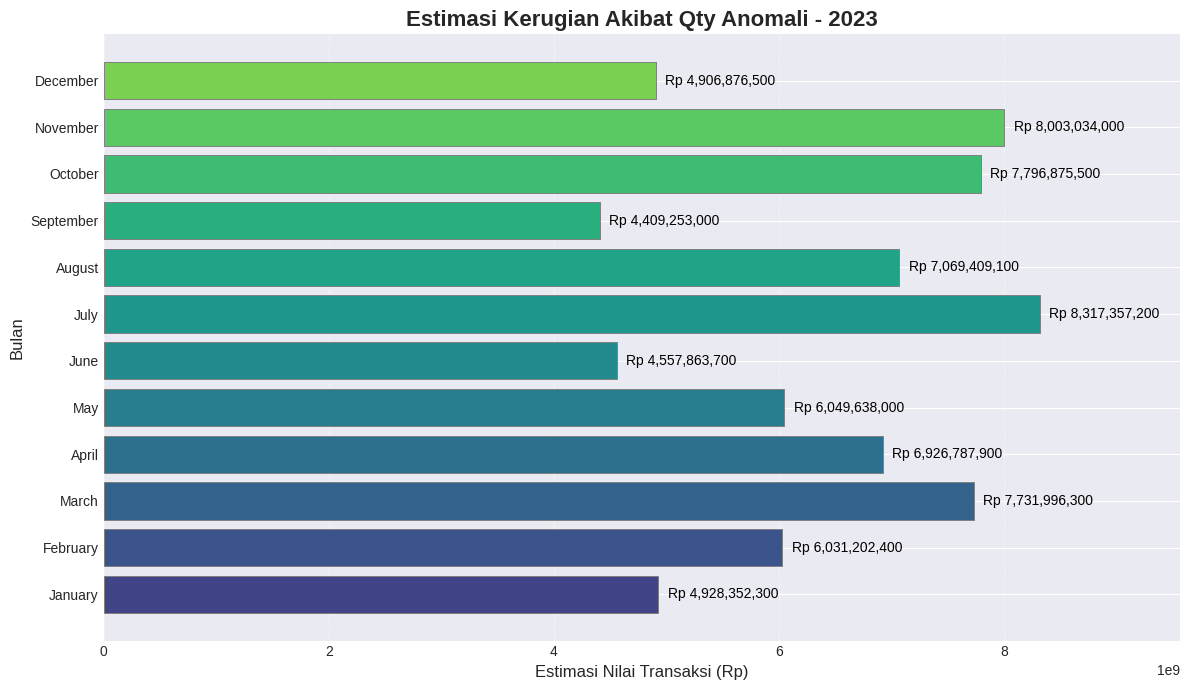

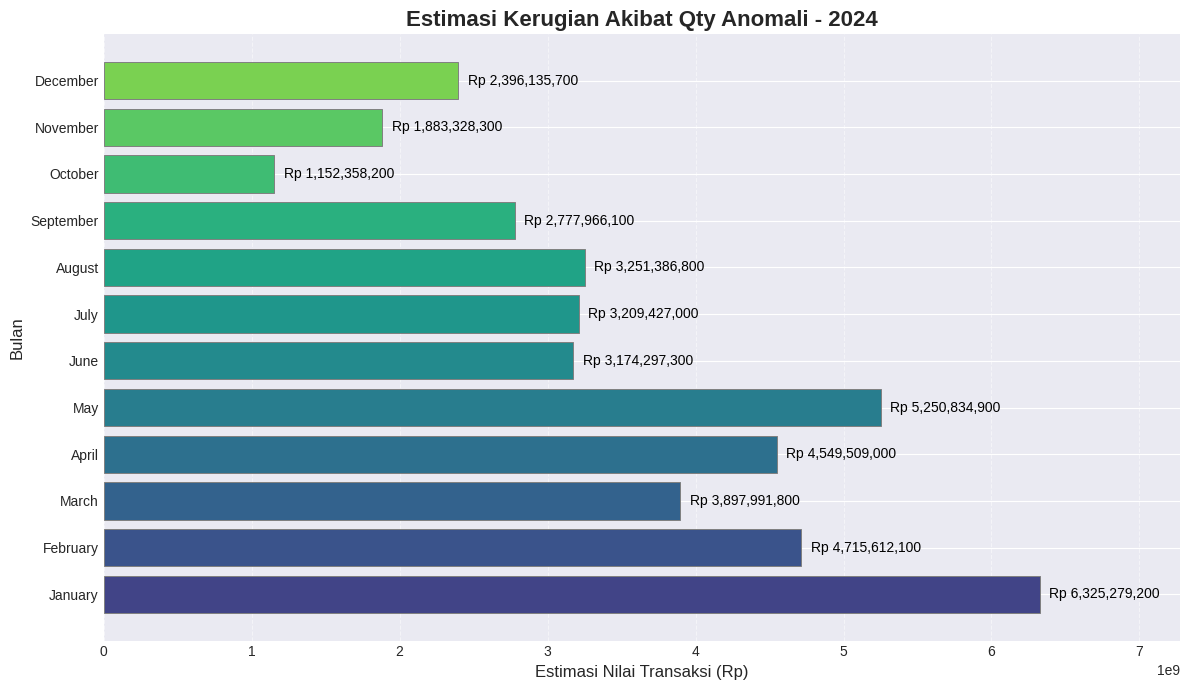

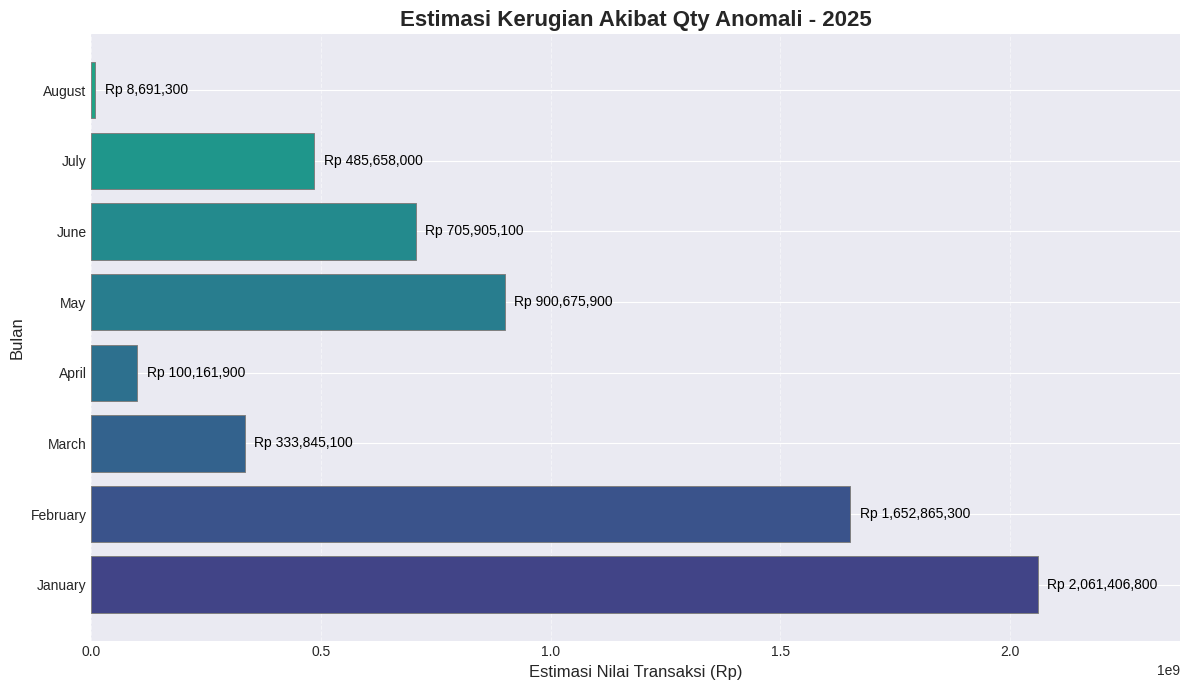

In [191]:
# =========================
# 1. FILTER QTY ANOMALY
# =========================
# Use the global 'df' which contains all transactions including large QTY values
# and has 'trx_date', 'trx_status' prepared from previous cells.
# Filter for 'Valid Transaction' first to exclude logical errors.
qty_anomaly = df[ (df['trx_status'] == 'Valid Transaction') & (df['qty'] > 24)].copy()

# =========================
# 2. EXTRACT DATE
# =========================
# Ensure 'trx_date' is datetime type for dt accessor
qty_anomaly['trx_date'] = pd.to_datetime(qty_anomaly['trx_date'])

qty_anomaly['year'] = qty_anomaly['trx_date'].dt.year
qty_anomaly['month_num'] = qty_anomaly['trx_date'].dt.month
qty_anomaly['month'] = qty_anomaly['trx_date'].dt.month_name()

# =========================
# 3. AGGREGATE ESTIMASI LOSS
# =========================
monthly_loss = (
    qty_anomaly
    .groupby(['year', 'month_num', 'month'])['total_price']
    .sum()
    .reset_index(name='Estimasi')
)

# =========================
# 4. SORT BULAN
# =========================
monthly_loss = monthly_loss.sort_values(['year', 'month_num'])

# =========================
# 5. COLOR (optional)
# =========================
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 12))

# =========================
# 6. PLOT PER YEAR
# =========================
for year in sorted(monthly_loss['year'].unique()):

    data_year = monthly_loss[monthly_loss['year'] == year].copy()

    plt.figure(figsize=(12,7))

    bars = plt.barh(
        data_year['month'],
        data_year['Estimasi'],
        color=colors[:len(data_year)],
        edgecolor='grey',
        linewidth=0.7
    )

    plt.title(
        f'Estimasi Kerugian Akibat Qty Anomali - {year}',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Estimasi Nilai Transaksi (Rp)', fontsize=12)
    plt.ylabel('Bulan', fontsize=12)

    # Calculate max width for the year to set x-axis limit
    max_width_year = data_year['Estimasi'].max()
    # Add some padding to the x-axis limit to ensure labels fit
    plt.xlim(0, max_width_year * 1.15) # 15% extra space on the right for labels

    # label angka
    for bar in bars:
        width = bar.get_width()
        ypos = bar.get_y() + bar.get_height()/2

        # Position text slightly to the right of the bar
        # Adjust 'xpos' and 'ha' for better placement
        plt.text(
            width + (max_width_year * 0.01), # Place 1% of max width after the bar
            ypos,
            f'Rp {int(width):,}',
            va='center',
            ha='left', # Align left so it extends right from xpos
            fontsize=10,
            color='black' # Make color explicit for readability
        )

    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

## 📊 Estimasi Kerugian Akibat Qty Anomali

Analisis ini bertujuan untuk mengidentifikasi potensi kerugian yang disebabkan oleh transaksi dengan jumlah barang (`qty`) yang tidak wajar.

Estimasi kerugian dihitung menggunakan pendekatan:
> **qty × unit_price**

Perlu dicatat bahwa nilai ini merupakan **indikasi potensi kerugian**, bukan kerugian riil, karena tidak mempertimbangkan data seperti void, retur, atau koreksi transaksi.

---

## 📆 Analisis Bulanan (Monthly)

Berdasarkan visualisasi per bulan, terlihat bahwa estimasi kerugian mengalami fluktuasi dengan beberapa periode menunjukkan lonjakan yang signifikan.

### 🔍 Insight
- Tahun **2022–2023** menunjukkan nilai kerugian bulanan yang relatif tinggi (banyak bulan > Rp 5 Miliar)
- Tahun **2023** menjadi periode dengan intensitas anomali paling tinggi
- Tahun **2024–2025** menunjukkan tren penurunan

### ⚠️ Interpretasi
- Lonjakan nilai kemungkinan disebabkan oleh:
  - kesalahan scanning kasir (double scan)
  - anomali pada sistem POS
- Penurunan setelah 2023 dapat mengindikasikan:
  - adanya perbaikan operasional
  - atau penurunan volume transaksi secara keseluruhan

---


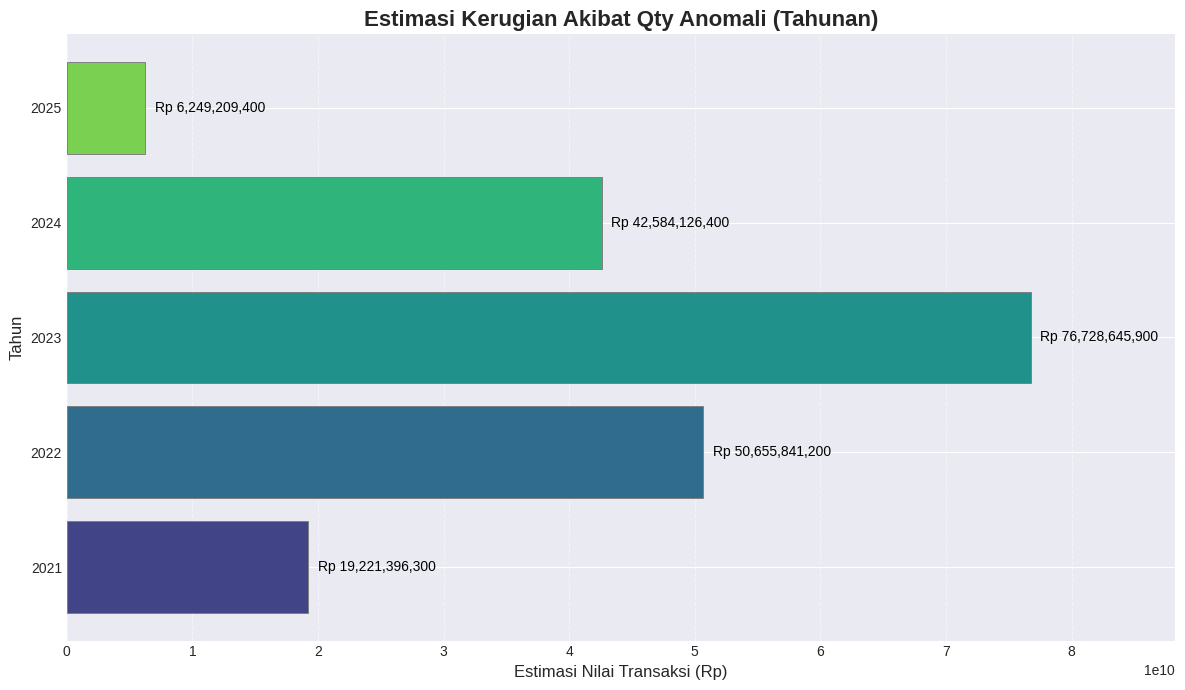

In [192]:
# =========================
# 1. AGGREGATE ANNUAL LOSS
# =========================
annual_loss = (
    monthly_loss
    .groupby('year')['Estimasi']
    .sum()
    .reset_index()
)

# =========================
# 2. SORT YEAR
# =========================
annual_loss = annual_loss.sort_values('year')

# =========================
# 3. COLOR (SAME STYLE AS MONTHLY)
# =========================
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(annual_loss)))

# =========================
# 4. PLOT
# =========================
plt.figure(figsize=(12,7))

bars = plt.barh(
    annual_loss['year'].astype(str),
    annual_loss['Estimasi'],
    color=colors,
    edgecolor='grey',
    linewidth=0.7
)

plt.title(
    'Estimasi Kerugian Akibat Qty Anomali (Tahunan)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Estimasi Nilai Transaksi (Rp)', fontsize=12)
plt.ylabel('Tahun', fontsize=12)

# =========================
# 5. AXIS LIMIT (CLEAN)
# =========================
max_width = annual_loss['Estimasi'].max()
plt.xlim(0, max_width * 1.15)

# =========================
# 6. LABEL ANGKA
# =========================
for bar in bars:
    width = bar.get_width()
    ypos = bar.get_y() + bar.get_height()/2

    plt.text(
        width + (max_width * 0.01),
        ypos,
        f'Rp {int(width):,}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

# =========================
# 7. GRID & LAYOUT
# =========================
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 📅 Analisis Tahunan (Annual)

Agregasi tahunan menunjukkan akumulasi dampak dari transaksi anomali dalam skala yang lebih besar.

### 🔍 Insight
- **2023** memiliki estimasi kerugian tertinggi (~Rp 76 Miliar)
- Diikuti oleh:
  - 2022 (~Rp 50 Miliar)
  - 2024 (~Rp 42 Miliar)
- Tahun **2025** mengalami penurunan signifikan (~Rp 6 Miliar)

### ⚠️ Interpretasi
- Qty anomali memiliki dampak finansial yang besar jika terakumulasi
- Tahun 2023 menjadi titik kritis yang perlu perhatian lebih
- Penurunan setelahnya bisa mengindikasikan:
  - perbaikan SOP kasir
  - peningkatan kontrol sistem
  - atau penurunan aktivitas transaksi

---

## 🧠 Kesimpulan

- Transaksi dengan qty tidak wajar memiliki potensi dampak finansial yang signifikan
- Masalah ini bersifat sistemik dan terjadi secara konsisten pada periode tertentu
- Perlu dilakukan validasi lebih lanjut untuk membedakan antara:
  - error operasional
  - dan transaksi valid dalam jumlah besar

# **Investigasi Transaksi Member yang indikasi Tengkulak**

In [193]:
# Let's create a dataframe for this specific analysis, starting from the original 'df' state
# after its trx_time has been processed into trx_date and time_trx.
# The 'df' dataframe currently has 'trx_date' as datetime.date objects.


# Ensure 'trx_date' is a proper datetime object to use .dt accessor
df_cln['trx_date'] = pd.to_datetime(df_cln['trx_date'])

# Create 'hari_transaksi' column
df_cln['hari_transaksi'] = df_cln['trx_date'].dt.day_name()

# Map English day names to Indonesian
day_mapping = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}
df_cln['hari_transaksi'] = df_cln['hari_transaksi'].map(day_mapping)

df_cln.head()

/tmp/ipykernel_4067/1381876033.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cln['trx_date'] = pd.to_datetime(df_cln['trx_date'])
/tmp/ipykernel_4067/1381876033.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cln['hari_transaksi'] = df_cln['trx_date'].dt.day_name()
/tmp/ipykernel_4067/1381876033.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

,receipt_id,store_id,sku_id,member_id,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date,trx_date,time_trx,trx_status,hari_transaksi
20,RCP00000021,SAT-0115,SKU000119,MEM-10142,BCA Debit,1,35700.0,Minyak Bimoli 2L,Food & Staples,35700.0,Alfamart Sudirman 114,Surabaya,2022-05-07,2022-02-18,12:00:00,Error Transaction,Jumat
58,RCP00000059,SAT-0609,SKU000385,NaN,QRIS,2,60400.0,Aqua 600ml,Beverage,30200.0,Alfamart Pahlawan 608,Semarang,2022-09-14,2022-07-20,05:00:00,Error Transaction,Rabu
62,RCP00000063,SAT-0565,SKU000131,NaN,Tunai,5,208500.0,Mnyk Goreng Bimoli,Food & Staples,41700.0,Alfamart Sudirman 564,Bekasi,2022-02-22,2021-12-07,15:00:00,Error Transaction,Selasa
79,RCP00000080,SAT-0957,SKU000273,MEM-10162,BCA Debit,24,957600.0,Rokok Sampoerna Mild,Cigarettes,39900.0,Alfamart Sudirman 956,Malang,2022-02-04,2021-11-17,14:00:00,Error Transaction,Rabu
161,RCP00000162,SAT-0160,SKU000399,NaN,Cash,1,11400.0,Minyak Bimoli 2L,Food & Staples,11400.0,Alfamart Diponegoro 159,Bogor,2022-01-01,2021-12-18,14:00:00,Error Transaction,Sabtu


In [194]:
# =========================
# 1. Hitung jumlah transaksi per member per bulan
# =========================

member_monthly_jsm = (
    alfamart_jsm.groupby(['member_id', 'month'])['receipt_id']
    .nunique()
    .reset_index(name='total_jsm_transactions')
)

# =========================
# 2. Sorting (optional)
# =========================

top_member_monthly = member_monthly_jsm.sort_values(
    by=['total_jsm_transactions'], ascending=False
).head(10)

# =========================
# 3. Output
# =========================

print("Top Member JSM per Month:")
display(top_member_monthly)

Top Member JSM per Month:


,member_id,month,total_jsm_transactions
1647,MEM-35257,2023-07,2
1573,MEM-33823,2021-03,1
1574,MEM-33865,2022-02,1
1575,MEM-33920,2023-05,1
1576,MEM-33929,2022-12,1
1577,MEM-33957,2023-01,1
1578,MEM-33963,2021-01,1
1579,MEM-34001,2021-10,1
1580,MEM-34018,2021-01,1
1582,MEM-34035,2022-09,1


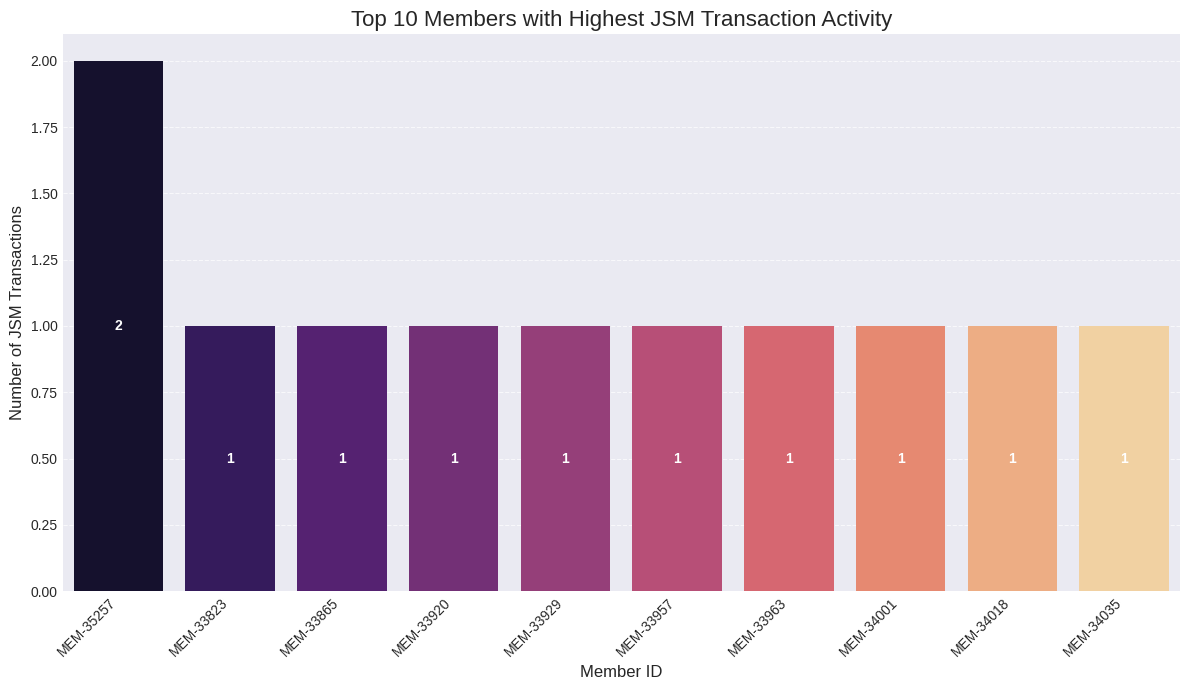

In [195]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='member_id', y='total_jsm_transactions', data=top_member_monthly, palette='magma', hue='member_id', legend=False)
plt.title('Top 10 Members with Highest JSM Transaction Activity', fontsize=16)
plt.xlabel('Member ID', fontsize=12)
plt.ylabel('Number of JSM Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers inside bars with white color
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,
        p.get_height() / 2.,
        '{:.0f}'.format(p.get_height()),
        fontsize=10,
        color='white',
        fontweight='bold',
        ha='center',
        va='center'
    )

plt.tight_layout()
plt.show()

## 📊 Data Insight

Berdasarkan grafik, terlihat bahwa mayoritas member hanya melakukan transaksi JSM sebanyak **1 kali per bulan**, dengan nilai maksimum hanya **2 transaksi**.

### 🔍 Insight
- Aktivitas transaksi per member relatif rendah
- Tidak terdapat member yang melakukan transaksi berulang dalam jumlah tinggi

### ⚠️ Interpretasi
- Tidak terdapat indikasi kuat adanya dominasi atau monopoli transaksi oleh member tertentu
- Pola ini menunjukkan bahwa transaksi promo JSM cenderung tersebar secara merata di banyak member

- Temuan ini menunjukan Promo telah berjalan lancar

# **Analisis Pengaruh Promo JSM terhadap jumlah kunjungan**

## 📊 Hypothesis Development

Berdasarkan hasil analisis, muncul hipotesis bahwa aktivitas Promo JSM berpotensi mempengaruhi jumlah kunjungan pelanggan di Alfamart.

### 🎯 Tujuan
Menguji apakah Promo JSM benar-benar berkontribusi terhadap peningkatan traffic pelanggan




### 🔍 **Hipotesis**


H0 : Tidak terdapat hubungan antara jumlah pengunjung JSM dengan total pengunjung Alfamart.

H1 : Terdapat hubungan antara jumlah pengunjung JSM dengan total pengunjung Alfamart.


In [196]:
df_cln.sort_values(by='trx_date', ascending= False)

,receipt_id,store_id,sku_id,member_id,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date,trx_date,time_trx,trx_status,hari_transaksi
153820,RCP00153821,SAT-0999,SKU000440,NaN,QRIS,5,89000.0,INDOMIE MIE GORENG,Food & Staples,17800.0,Alfamart Melati 998,Surabaya,2023-09-27,2023-09-12,13:00:00,Error Transaction,Selasa
206122,RCP00206123,SAT-0123,SKU000056,NaN,Cash,2,36600.0,Aqua 600ml,Beverage,18300.0,Alfamart Melati 122,Bekasi,2023-09-22,2023-09-10,11:00:00,Error Transaction,Minggu
31388,RCP00031389,SAT-0867,SKU000098,MEM-03434,Tunai,1,19500.0,Rokok Sampoerna Mild,Cigarettes,19500.0,Alfamart Pahlawan 866,Depok,2023-09-21,2023-09-08,04:00:00,Error Transaction,Jumat
230161,RCP00230162,SAT-0276,SKU000490,NaN,Tunai,2,80200.0,Minyak Bimoli 2L,Food & Staples,40100.0,Alfamart Gatot Subroto 275,Medan,2023-09-25,2023-09-07,15:00:00,Error Transaction,Kamis
296279,RCP00296280,SAT-0187,SKU000412,NaN,qris,1,21300.0,Mnyk Goreng Bimoli,Food & Staples,21300.0,Alfamart Gatot Subroto 186,Bandung,2023-09-18,2023-09-07,06:00:00,Error Transaction,Kamis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,RCP00001319,SAT-0790,SKU000266,MEM-20753,BCA Debit,5,48000.0,Rokok Sampoerna Mild,Cigarettes,9600.0,Alfamart Diponegoro 789,Surabaya,2021-01-07,2020-10-05,12:00:00,Error Transaction,Senin
88660,RCP00088661,SAT-0790,SKU000464,NaN,Cash,1,11200.0,Air Mineral Aqua,Beverage,11200.0,Alfamart Diponegoro 789,Surabaya,2021-01-07,2020-10-05,03:00:00,Error Transaction,Senin
81590,RCP00081591,SAT-0790,SKU000132,MEM-40195,OVO,1,28500.0,Pepsodent 190g,Personal Care,28500.0,Alfamart Diponegoro 789,Surabaya,2021-01-07,2020-10-05,08:00:00,Error Transaction,Senin
183847,RCP00183848,SAT-0790,SKU000200,MEM-23574,CASH,1,40500.0,Mnyk Goreng Bimoli,Food & Staples,40500.0,Alfamart Diponegoro 789,Surabaya,2021-01-07,2020-10-04,13:00:00,Error Transaction,Minggu


In [262]:
# =========================
# 1. COPY DATA
# =========================
df_for_member_analysis_all = df_cln.copy()

# =========================
# 2. FIX DATETIME (HANDLE MIXED FORMAT 🔥)
# =========================
df_for_member_analysis_all['trx_date'] = pd.to_datetime(
    df_for_member_analysis_all['trx_date'],
    errors='coerce',
    infer_datetime_format=True  # lebih aman untuk format campuran
)

# =========================
# 3. DEBUG RAW YEAR DISTRIBUTION (CEK DULU 🔥)
# =========================
print("Distribusi Tahun (SEBELUM DROP):")
print(df_for_member_analysis_all['trx_date'].astype(str).str[:4].value_counts())

# =========================
# 4. DEBUG CHECK
# =========================
print("\nTipe data trx_date:", df_for_member_analysis_all['trx_date'].dtype)
print("Tanggal paling awal:", df_for_member_analysis_all['trx_date'].min())
print("Tanggal paling akhir:", df_for_member_analysis_all['trx_date'].max())
print("Jumlah NaT (error parsing):", df_for_member_analysis_all['trx_date'].isna().sum())

# =========================
# 5. DROP DATA INVALID
# =========================
df_for_member_analysis_all = df_for_member_analysis_all.dropna(subset=['trx_date'])

# =========================
# 6. CEK LAGI SETELAH DROP 🔥
# =========================
print("\nDistribusi Tahun (SETELAH DROP):")
print(df_for_member_analysis_all['trx_date'].dt.year.value_counts())

print("Tanggal paling akhir (FINAL):", df_for_member_analysis_all['trx_date'].max())

# =========================
# 7. CREATE HARI TRANSAKSI
# =========================
df_for_member_analysis_all['hari_transaksi'] = df_for_member_analysis_all['trx_date'].dt.day_name()

day_mapping = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}

df_for_member_analysis_all['hari_transaksi'] = df_for_member_analysis_all['hari_transaksi'].map(day_mapping)

# =========================
# 8. CREATE MONTH
# =========================
df_for_member_analysis_all['month'] = df_for_member_analysis_all['trx_date'].dt.to_period('M')

# =========================
# 9. ALL DAYS (MONTHLY)
# =========================
members_all = (
    df_for_member_analysis_all
    .groupby('month')['member_id']
    .nunique()
    .reset_index()
)

members_all.columns = ['Month', 'All Days']

# =========================
# 10. JSM ONLY (MONTHLY)
# =========================
df_jsm = df_for_member_analysis_all[
    df_for_member_analysis_all['hari_transaksi'].isin(['Jumat', 'Sabtu', 'Minggu'])
].copy()

members_jsm = (
    df_jsm
    .groupby('month')['member_id']
    .nunique()
    .reset_index()
)

members_jsm.columns = ['Month', 'JSM Days']

# =========================
# 11. COMBINE
# =========================
final_table = members_all.merge(
    members_jsm,
    on='Month',
    how='left'
)

# =========================
# 12. HANDLE MISSING
# =========================
final_table['JSM Days'] = final_table['JSM Days'].fillna(0).astype(int)

# =========================
# 13. SORT
# =========================
final_table = final_table.sort_values(by='Month')

# =========================
# 14. RESULT
# =========================
print("\n📊 Monthly Table (All Days vs JSM Days):")
display(final_table)

/tmp/ipykernel_4067/1618633142.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_for_member_analysis_all['trx_date'] = pd.to_datetime(


Distribusi Tahun (SEBELUM DROP):
trx_date
2023    64698
2022    52920
2024    37515
2021    18141
2025     6449
2020      277
Name: count, dtype: int64

Tipe data trx_date: datetime64[ns]
Tanggal paling awal: 2020-10-01 00:00:00
Tanggal paling akhir: 2025-08-23 00:00:00
Jumlah NaT (error parsing): 0

Distribusi Tahun (SETELAH DROP):
trx_date
2023    64698
2022    52920
2024    37515
2021    18141
2025     6449
2020      277
Name: count, dtype: int64
Tanggal paling akhir (FINAL): 2025-08-23 00:00:00

📊 Monthly Table (All Days vs JSM Days):


,Month,All Days,JSM Days
0,2020-10,41,19
1,2020-11,79,36
2,2020-12,157,64
3,2021-01,252,125
4,2021-02,411,182
5,2021-03,662,258
6,2021-04,873,369
7,2021-05,1266,580
8,2021-06,1404,545
9,2021-07,1606,738


# **UJi Normalitas**

In [263]:
# Copy data
df_stat = final_table.copy()

# Ambil kolom numerik
all_days = df_stat['All Days']
jsm_days = df_stat['JSM Days']

# Uji normalitas
shapiro_all = sc.shapiro(all_days)
if shapiro_all.pvalue > 0.05:
  print('Data "all_days" Berdistribusi Normal')
else:
  print('Data "all_days" Tidak Berdistribusi Normal')

shapiro_jsm = sc.shapiro(jsm_days)
if shapiro_jsm.pvalue > 0.05:
  print('Data "jsm_days" Berdistribusi Normal')
else:
  print('Data "jsm_days" Tidak Berdistribusi Normal')

Data "all_days" Tidak Berdistribusi Normal
Data "jsm_days" Tidak Berdistribusi Normal


# **Uji Spearman**

Berdasarkan hasil uji normalitas menunjukan data tidak terdistribusi normal maka melakukan uji spearman

In [264]:
spearman_corr, spearman_p = sc.spearmanr(all_days, jsm_days)

print("Spearman Correlation:", spearman_corr)
print("P-value:", spearman_p)

Spearman Correlation: 0.9797188700521766
P-value: 1.7219307261723926e-41


## 📊 Correlation Analysis (Spearman)

Hasil uji Spearman menunjukkan:

- Correlation: **0.98**
- P-value: **< 0.05**

### 🔍 Insight
- Terdapat hubungan positif yang sangat kuat antara transaksi JSM dan total transaksi
### ⚠️ Interpretasi
- Ketika jumlah kunjungan konsumenn pada promo meningkat otomatis, volume transaksi pada alfamart sendiri meningkat.

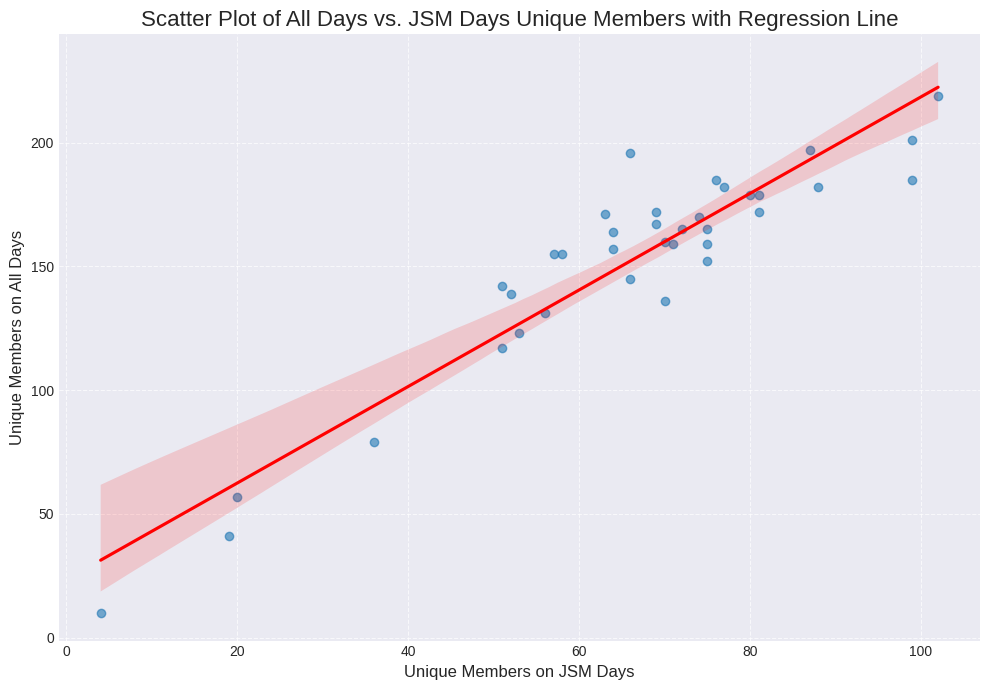

In [202]:
plt.figure(figsize=(10, 7))
sns.regplot(x='JSM Days', y='All Days', data=final_table, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Scatter Plot of All Days vs. JSM Days Unique Members with Regression Line', fontsize=16)
plt.xlabel('Unique Members on JSM Days', fontsize=12)
plt.ylabel('Unique Members on All Days', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 📊 Scatter Plot Analysis (JSM vs Total Transactions)

Berdasarkan scatter plot, terlihat adanya hubungan linear yang sangat kuat antara jumlah transaksi JSM dan total transaksi Alfamart.

### 🔍 Insight
- Titik data membentuk pola garis naik yang konsisten
- Garis regresi menunjukkan tren positif yang jelas
- Tidak terdapat outlier ekstrem yang menyimpang dari pola utama

### ⚠️ Interpretasi
- Ketika jumlah transaksi JSM meningkat, total transaksi juga cenderung meningkat secara konsisten
- Pola ini menunjukkan adanya hubungan yang kuat dan stabil antara kedua variabel

### 🧠 Catatan Analitis
- Hasil ini sejalan dengan uji korelasi Spearman yang menunjukkan hubungan sangat kuat (≈0.98)

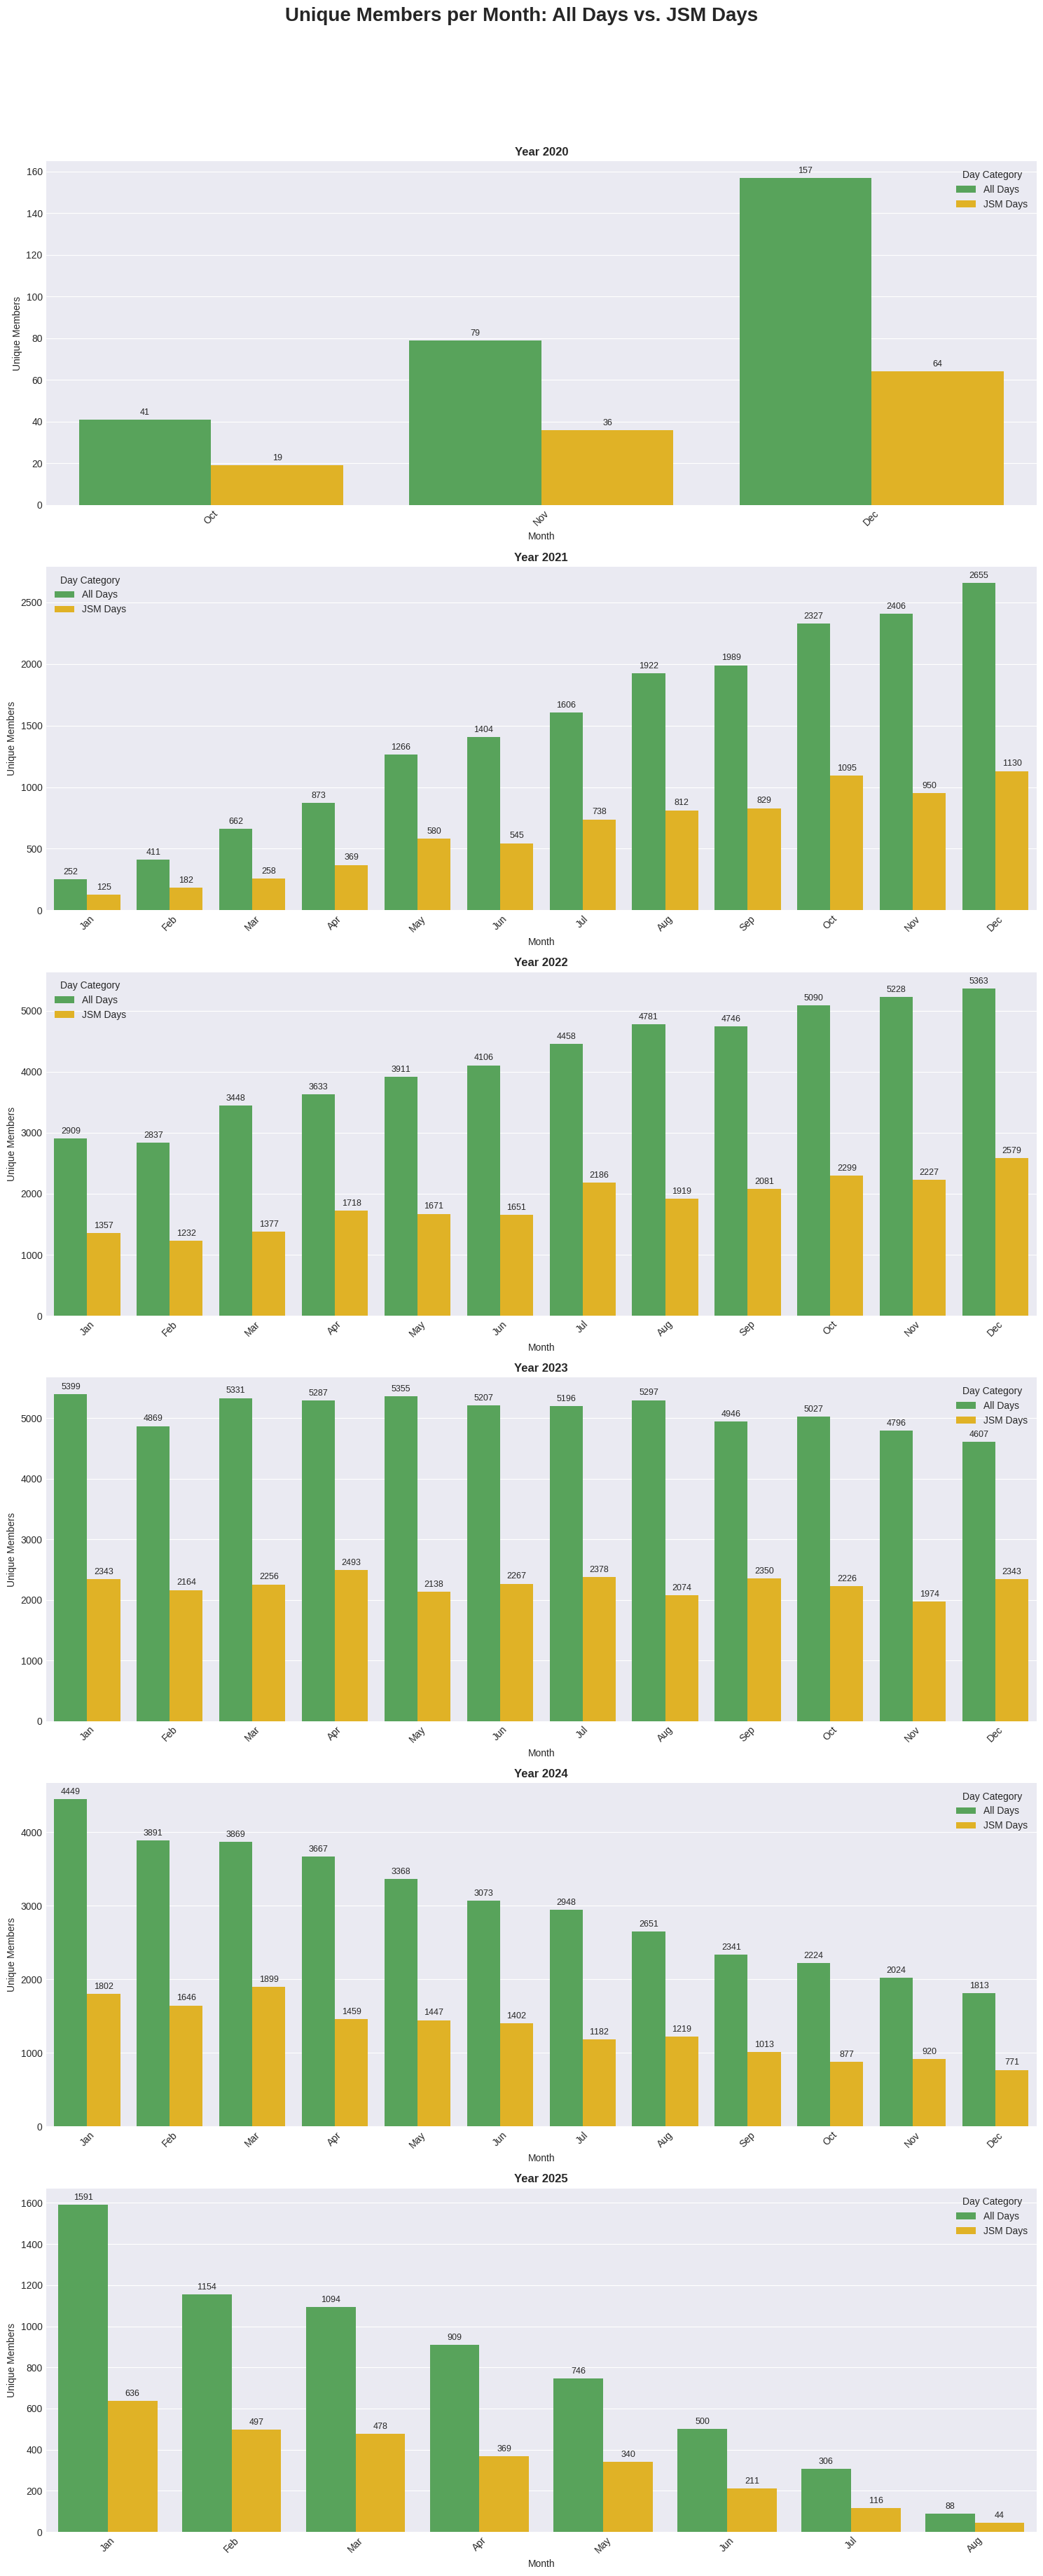

In [265]:
# =========================
# 1. PREPARE DATA FROM final_table
# =========================

# Convert Period → datetime
final_table['Month_dt'] = final_table['Month'].dt.to_timestamp()

# Extract Year & Month Name
final_table['Year'] = final_table['Month_dt'].dt.year
final_table['Month_Name'] = final_table['Month_dt'].dt.strftime('%b')

# =========================
# 2. RESHAPE DATA (WIDE → LONG)
# =========================

# Ubah jadi format panjang biar bisa pakai hue
plot_data = final_table.melt(
    id_vars=['Month', 'Month_dt', 'Year', 'Month_Name'],
    value_vars=['All Days', 'JSM Days'],
    var_name='Day_Category',
    value_name='Unique Members'
)

# =========================
# 3. SORT DATA BIAR URUT
# =========================
plot_data = plot_data.sort_values(by=['Year', 'Month_dt'])

# =========================
# 4. SET STYLE
# =========================
plt.style.use('seaborn-v0_8-darkgrid')

# Get unique years
years = sorted(plot_data['Year'].unique())

# =========================
# 5. CREATE SUBPLOTS
# =========================
fig, axes = plt.subplots(
    nrows=len(years),
    ncols=1,
    figsize=(15, 6 * len(years))
)

fig.suptitle(
    'Unique Members per Month: All Days vs. JSM Days',
    fontsize=20,
    fontweight='bold',
    y=1.02
)

# Handle jika cuma 1 tahun
if len(years) == 1:
    axes = [axes]

# =========================
# 6. LOOP PER YEAR
# =========================
for i, year in enumerate(years):
    ax = axes[i]

    yearly_data = plot_data[plot_data['Year'] == year]

    sns.barplot(
        data=yearly_data,
        x='Month_Name',
        y='Unique Members',
        hue='Day_Category',
        ax=ax,
        palette={'All Days': '#4CAF50', 'JSM Days': '#FFC107'}
    )

    ax.set_title(f'Year {year}', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Unique Members')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Day Category')

    # Label angka
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

# =========================
# 7. FINAL LAYOUT
# =========================
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 📊 Monthly JSM Traffic Analysis (2021–2025)

Analisis dilakukan untuk melihat pola jumlah unique member yang bertransaksi pada periode Promo JSM (Jumat–Minggu) secara bulanan dan di bandingkan dengan jumlah transaksi harian.

---

### 🔍 Year 2021
- Terlihat tren peningkatan yang cukup konsisten sepanjang tahun
- Dimulai dari level rendah di awal tahun dan meningkat hingga puncak di Q4 (Oktober–Desember)

👉 Mengindikasikan fase awal pertumbuhan dan peningkatan adopsi promo

---

### 🔍 Year 2022
- Level traffic meningkat signifikan dibanding 2021
- Pola relatif stabil dengan tren naik secara bertahap
- Terjadi lonjakan pada pertengahan hingga akhir tahun

👉 Menunjukkan fase ekspansi dan performa promo yang kuat

---

### 🔍 Year 2023
- Traffic berada pada level tertinggi dibanding tahun sebelumnya
- Namun mulai terlihat fluktuasi antar bulan
- Tidak lagi menunjukkan tren kenaikan yang konsisten seperti tahun sebelumnya

👉 Mengindikasikan fase puncak (peak performance) dengan mulai adanya tanda stabilisasi

---

### 🔍 Year 2024
- Terjadi penurunan signifikan dibanding tahun 2023
- Tren cenderung menurun secara konsisten sepanjang tahun
- Tidak terdapat lonjakan kuat seperti tahun-tahun sebelumnya

👉 Mengindikasikan adanya penurunan engagement terhadap promo

---

### 🔍 Year 2025
- Traffic berada pada level paling rendah
- Tren menunjukkan penurunan yang cukup tajam dari bulan ke bulan
- Data kemungkinan belum mencerminkan satu tahun penuh

👉 Mengindikasikan penurunan lanjutan, namun perlu kehati-hatian dalam interpretasi

---

## 🧠 Pola Utama yang Teridentifikasi

### 1. Fase Growth (2021–2023)
- Terjadi peningkatan signifikan jumlah member
- Promo berhasil menarik traffic dalam jangka pendek

---

### 2. Fase Peak (2023)
- Tahun dengan performa tertinggi
- Mulai muncul fluktuasi → indikasi perubahan dinamika

---

### 3. Fase Decline (2024–2025)
- Terjadi penurunan konsisten setelah mencapai puncak
- Tidak ada rebound atau recovery yang signifikan

---

## ⚠️ Catatan Analitis

- Data menunjukkan perubahan pola dari growth → stabil → decline


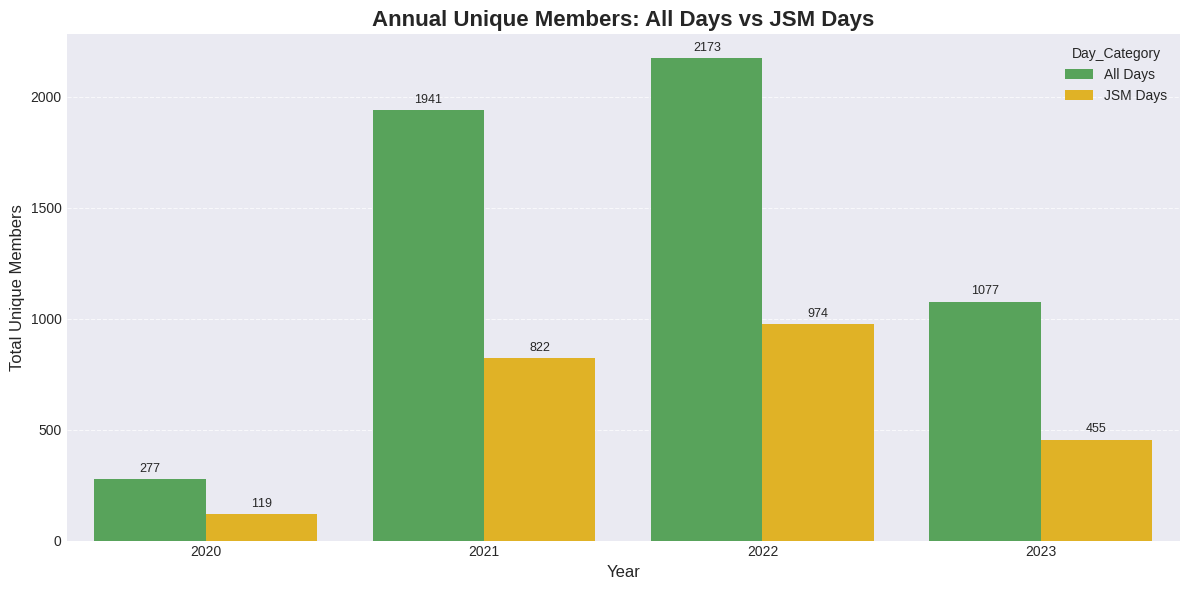

In [204]:
# Assuming final_table is already defined and available in the kernel from previous execution

# Convert 'Month' to datetime objects for proper sorting and extraction
# Ensure 'Month' is converted from Period to Timestamp for easier manipulation
final_table_for_plot = final_table.copy()
final_table_for_plot['Month_dt'] = final_table_for_plot['Month'].dt.to_timestamp()

# Melt the DataFrame to long format for easier plotting with seaborn's hue
melted_table = final_table_for_plot.melt(
    id_vars=['Month', 'Month_dt'],
    value_vars=['All Days', 'JSM Days'],
    var_name='Day_Category',
    value_name='Unique Members'
)

# Extract year for annual grouping
melted_table['Year'] = melted_table['Month_dt'].dt.year

# Aggregate to annual level for plotting
annual_members_combined = melted_table.groupby(['Year', 'Day_Category'])['Unique Members'].sum().reset_index()

# Sort for consistent plotting
annual_members_combined = annual_members_combined.sort_values(by=['Year', 'Day_Category'])

# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=annual_members_combined,
    x='Year',
    y='Unique Members',
    hue='Day_Category',
    palette={'All Days': '#4CAF50', 'JSM Days': '#FFC107'} # Eye-catching palette
)

plt.title(
    'Annual Unique Members: All Days vs JSM Days',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Unique Members', fontsize=12)
plt.xticks(rotation=0) # Keep years straight for annual plot
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 📊 Annual JSM Customer Traffic Analysis

Berdasarkan analisis jumlah unique member yang bertransaksi pada periode Promo JSM (Jumat–Minggu), terlihat adanya perubahan tren dari tahun ke tahun.

### 🔍 Insight
- Terjadi peningkatan signifikan pada periode 2021 hingga 2023, dengan puncak pada tahun 2023.Hal ini mengindikasikan bahwa Promo JSM efektif dalam menarik traffic pada **fase awal implementasi**.

- Namun, pada periode 2023 hingga 2024 terjadi penurunan jumlah member yang cukup signifikan. Terutama penurunan pada tahun 2025 menunjukkan penurunan lebih lanjut, walaupun data tahun 2025 belum mencerminkan performa selama satu tahun.
---

### ⚠️ Interpretasi
Promo JSM menunjukkan efektivitas dalam jangka pendek (initial growth).Namun terdapat indikasi penurunan performa setelah mencapai puncak di tahun 2023.
Penurunan ini di sebabkan dipengaruhi oleh:
  - **kejenuhan promo (promo fatigue)**
  - **perubahan perilaku konsumen**
  
---

### 🧠 Kesimpulan
Promo JSM terbukti efektif dalam meningkatkan traffic pada fase awal, namun menunjukkan indikasi penurunan performa setelah periode puncak.

---

### 🚀 Rekomendasi
- Evaluasi ulang strategi promo (variasi promo, segmentasi target)
- Analisis lebih lanjut terhadap faktor penyebab penurunan (internal vs eksternal)
- Fokus pada peningkatan retensi pelanggan, bukan hanya akuisisi

# **Strategi untuk meningkatkan Volume Transaksi**

## **Strategi Mengoptimalisasi Member id**

Berdasarkan dari hasil sebelumnya ada memnunjukan ada banyak pelanggan yang tidak menggunakan member id sebesar 40%, maka dari itu saya mencoba menganalisis apakah Member_id alfamart berpotensi meningkatkan volume transaksi

# **Membership Impact Analysis (Inferential)**

Untuk mengetahui apakah membership memberikan pengaruh terhadap jumlah transaksi, dilakukan uji hipotesis menggunakan pendekatan statistik inferensial.



**Hipotesis**

H0:  jumlah transaksi pelanggan alfamart member =< pelanggan alfamart non-member

H1:  jumlah transaksi pelanggan alfamart member > pelanggan alfamart non-member

In [267]:

# --- Restore original df to ensure correct starting point for analysis ---
# (This section is copied from cell 1f_G0UxNAkZ4 to make this cell self-contained)
pos_transactions = pd.read_csv('alfa_pos_transactions.csv')
products = pd.read_csv('alfa_products.csv')
stores = pd.read_csv('alfa_stores.csv')

df = pd.merge(pos_transactions, products, on='sku_id')
df = pd.merge(df, stores, on='store_id')

# Re-apply trx_time and open_date conversions and trx_status calculation
df['trx_time'] = pd.to_datetime(df['trx_time'])
df = df.assign(
    trx_date = df['trx_time'].dt.date,
    time_trx = df['trx_time'].dt.time
).drop(columns='trx_time')
df['open_date'] = pd.to_datetime(df['open_date']).dt.date

df['trx_status'] = df.apply(
    lambda x: 'Error Transaction' if pd.Timestamp(x['trx_date']) < pd.Timestamp(x['open_date']) else 'Valid Transaction',
    axis=1
)
# -----------------------------------------------------------------------

# Reconstruct df_analysis_base with all valid cleaning steps for member/non-member analysis

# Start from the full df which has trx_date, open_date, trx_status (from previous cells)
df_analysis_base = df.copy()

# 1. Remove Error Transactions
df_analysis_base = df_analysis_base[df_analysis_base['trx_status'] == 'Valid Transaction'].copy()

# 2. Handle Outliers in qty
df_analysis_base = df_analysis_base[(df_analysis_base['qty'] > 0) & (df_analysis_base['qty'] < 30)].copy()

# 3. Handle Inconsistent Payment Methods
payment_revised = {
    'debit bca': 'BCA Debit',
    'qris': 'QRIS',
    'CASH': 'Cash',
    'Tunai': 'Cash'
}
df_analysis_base['payment_method'] = df_analysis_base['payment_method'].replace(payment_revised)

# =========================
# 1. PREPARATION
# =========================

df_member = df_analysis_base.copy() # Use the properly cleaned and filtered base dataframe

# Create label member / non-member
df_member['is_member'] = df_member['member_id'].notna().astype(int)

# =========================
# 2. MEMBER TRANSACTIONS
# =========================

member_trx = (
    df_member[df_member['is_member'] == 1]
    .groupby('member_id')['receipt_id']
    .nunique()
    .reset_index(name='total_transactions')
)

member_trx['group'] = 'Member'

# =========================
# 3. NON-MEMBER TRANSACTIONS
# =========================

non_member_trx = (
    df_member[df_member['is_member'] == 0]
    .groupby('receipt_id')['receipt_id']
    .nunique() # Use nunique for non-member transactions to count unique receipts
    .reset_index(name='total_transactions')
)

non_member_trx['group'] = 'Non-Member'

# =========================
# 4. COMBINE
# =========================

trx_data = pd.concat([
    member_trx[['total_transactions','group']],
    non_member_trx[['total_transactions','group']]
])

# Split data
member_data = trx_data[trx_data['group'] == 'Member']['total_transactions']
non_member_data = trx_data[trx_data['group'] == 'Non-Member']['total_transactions']

In [268]:
# =========================
# 5. NORMALITY TEST
# =========================

print("Normality Test (Shapiro)")

shapiro_member_result = sc.shapiro(member_data)

# Ambil p-value
p_member = sc.shapiro(member_data).pvalue
p_non_member = sc.shapiro(non_member_data).pvalue

alpha = 0.05

# Cek normalitas
if (p_member > alpha) and (p_non_member > alpha):
    print("Data normal → Gunakan Independent T-Test")
else:
    print("Data tidak normal → Gunakan Mann-Whitney U Test")

Normality Test (Shapiro)
Data tidak normal → Gunakan Mann-Whitney U Test


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 48403.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 115293.
  res = hypotest_fun_out(*samples, **kwds)


**Data Insight**

data tidak distribusi normal sehingga mengunakan metode Mann-Whitney U Test

In [269]:
# =========================
# 6. HYPOTHESIS TEST
# =========================

u_stat, p_value = sc.mannwhitneyu(member_data, non_member_data, alternative='greater')

print("\nMann-Whitney U Test")
print("U-stat:", u_stat)
print("P-value:", p_value)

# =========================
# 7. INTERPRETATION
# =========================

alpha = 0.05

if p_value < alpha:
    print("\nTolak H0 → Member memiliki transaksi lebih tinggi secara signifikan")
else:
    print("\nGagal menolak H0 → Tidak ada perbedaan signifikan")


Mann-Whitney U Test
U-stat: 5266180714.5
P-value: 0.0

Tolak H0 → Member memiliki transaksi lebih tinggi secara signifikan


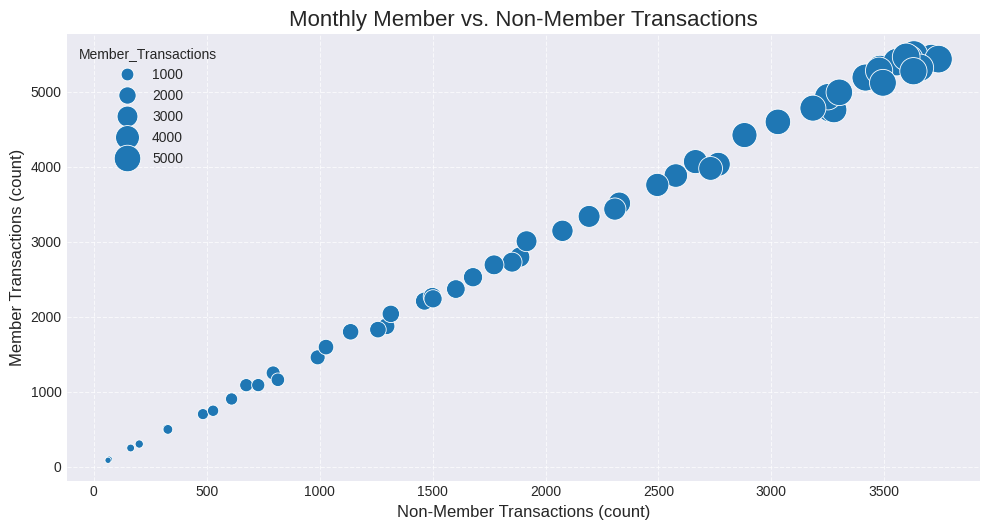

In [270]:
# Reset index to make 'month' a column for plotting if needed, or directly access columns
plot_data = monthly_transactions_summary.reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x='Non-Member_Transactions',
    y='Member_Transactions',
    # Removed hue='month' for a cleaner plot
    size='Member_Transactions', # Optionally size points by Member Transactions
    sizes=(20, 400), # Range of sizes
    legend='brief' # Show legend for size
    # Removed palette as there is no hue variable
)

plt.title('Monthly Member vs. Non-Member Transactions', fontsize=16)
plt.xlabel('Non-Member Transactions (count)', fontsize=12)
plt.ylabel('Member Transactions (count)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust rect to give more space for labels and title
plt.show()

## 📊 Data Insight

Berdasarkan hasil uji **Mann-Whitney U Test**, diperoleh p-value yang sangat kecil (< 0.05), sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat **perbedaan signifikan** antara jumlah transaksi pelanggan member dan non-member.

Temuan ini juga diperkuat oleh visualisasi scatter plot, yang menunjukkan pola hubungan yang konsisten antara transaksi member dan non-member.

---

### 🔍 Insight

- Pelanggan dengan `member_id` cenderung memiliki **jumlah transaksi yang lebih tinggi** dibandingkan non-member  
- Scatter plot menunjukkan **pola hubungan positif yang kuat**, di mana peningkatan transaksi non-member diikuti oleh peningkatan transaksi member  
- Distribusi data yang membentuk pola linear mengindikasikan bahwa aktivitas transaksi antara kedua kelompok bergerak secara **searah dan konsisten**  

---

### ⚠️ Interpretasi

- Membership berpotensi menjadi indikator pelanggan yang lebih aktif dalam bertransaksi  
- Pola linear pada scatter plot menunjukkan bahwa membership memiliki **asosiasi yang kuat terhadap aktivitas transaksi**, bukan sekadar perbedaan acak  
- Namun, hubungan ini tetap bersifat **korelasional**, bukan sebab-akibat langsung  

---

### 🧠 Catatan Analitis

- Hasil uji statistik (signifikan) dan visualisasi (pola linear) saling mendukung bahwa terdapat **perbedaan dan hubungan yang konsisten**  
- Scatter plot memperkuat bahwa hubungan ini tidak bersifat acak, melainkan memiliki **struktur yang jelas**  
- Meski demikian, faktor lain seperti promo (JSM) dan kategori produk tetap berperan dalam mempengaruhi transaksi  

---

### 🚀 Implikasi Bisnis

- Membership dapat dimanfaatkan sebagai **alat untuk mengidentifikasi pelanggan dengan aktivitas tinggi**  
- Data member memungkinkan perusahaan untuk:
  - melakukan **targeted promotion**
  - meningkatkan efektivitas program seperti JSM  
- Jika dikombinasikan dengan strategi produk (Food & Staples) dan promo, membership dapat menjadi **supporting driver** dalam meningkatkan transaksi  

---

### 📌 Key Takeaway

👉 Membership memiliki **hubungan signifikan dan konsisten** dengan aktivitas transaksi  
👉 Namun, perannya lebih sebagai **supporting factor**, bukan driver utama dibandingkan promo dan produk  

In [271]:
# --- Restore original df to ensure correct starting point for analysis ---
pos_transactions = pd.read_csv('alfa_pos_transactions.csv')
products = pd.read_csv('alfa_products.csv')
stores = pd.read_csv('alfa_stores.csv')

df = pd.merge(pos_transactions, products, on='sku_id')
df = pd.merge(df, stores, on='store_id')

# Re-apply trx_time and open_date conversions and trx_status calculation
df['trx_time'] = pd.to_datetime(df['trx_time'])
df = df.assign(
    trx_date = df['trx_time'].dt.date,
    time_trx = df['trx_time'].dt.time
).drop(columns='trx_time')
df['open_date'] = pd.to_datetime(df['open_date']).dt.date

df['trx_status'] = df.apply(
    lambda x: 'Error Transaction' if pd.Timestamp(x['trx_date']) < pd.Timestamp(x['open_date']) else 'Valid Transaction',
    axis=1
)
# -----------------------------------------------------------------------

# Reconstruct df_analysis_base with all valid cleaning steps
# Start from the full df which has trx_date, open_date, trx_status (from previous cells)
df_analysis_base = df.copy()

# 1. Remove Error Transactions
df_analysis_base = df_analysis_base[df_analysis_base['trx_status'] == 'Valid Transaction'].copy()

# 2. Handle Outliers in qty
df_analysis_base = df_analysis_base[(df_analysis_base['qty'] > 0) & (df_analysis_base['qty'] < 30)].copy()

# 3. Handle Inconsistent Payment Methods
payment_revised = {
    'debit bca': 'BCA Debit',
    'qris': 'QRIS',
    'CASH': 'Cash',
    'Tunai': 'Cash'
}
df_analysis_base['payment_method'] = df_analysis_base['payment_method'].replace(payment_revised)

# Now, create df_member from this correctly cleaned base DataFrame
df_member = df_analysis_base.copy() # Use the properly cleaned and filtered base dataframe

# Create label member / non-member
df_member['is_member'] = df_member['member_id'].notna().astype(int)

# Ensure trx_date is datetime and extract month
df_member['trx_date'] = pd.to_datetime(df_member['trx_date'])
df_member['month'] = df_member['trx_date'].dt.to_period('M')

# Group by month and membership status, then count unique transactions
monthly_transactions_summary = df_member.groupby(['month', 'is_member'])['receipt_id'].nunique().reset_index()

# Pivot the table to have 'Member' and 'Non-Member' as columns
# Fill missing combinations of (month, is_member) with 0 before pivoting
monthly_transactions_summary = monthly_transactions_summary.pivot(index='month', columns='is_member', values='receipt_id').fillna(0).astype(int)

# Rename columns for clarity
# The columns created by pivot will be 0 and 1, representing is_member.
# We need to explicitly name them 'Non-Member_Transactions' and 'Member_Transactions'.
# This handles cases where for some months, only members or only non-members had transactions
if 0 not in monthly_transactions_summary.columns:
    monthly_transactions_summary[0] = 0
if 1 not in monthly_transactions_summary.columns:
    monthly_transactions_summary[1] = 0

monthly_transactions_summary = monthly_transactions_summary[[0, 1]] # Ensure order
monthly_transactions_summary.columns = ['Non-Member_Transactions', 'Member_Transactions']

# Display the summary table
display(monthly_transactions_summary)


,Non-Member_Transactions,Member_Transactions
month,,
2021-01,68,101
2021-02,163,251
2021-03,325,504
2021-04,483,703
2021-05,675,1089
2021-06,794,1252
2021-07,991,1460
2021-08,1137,1801
2021-09,1296,1875


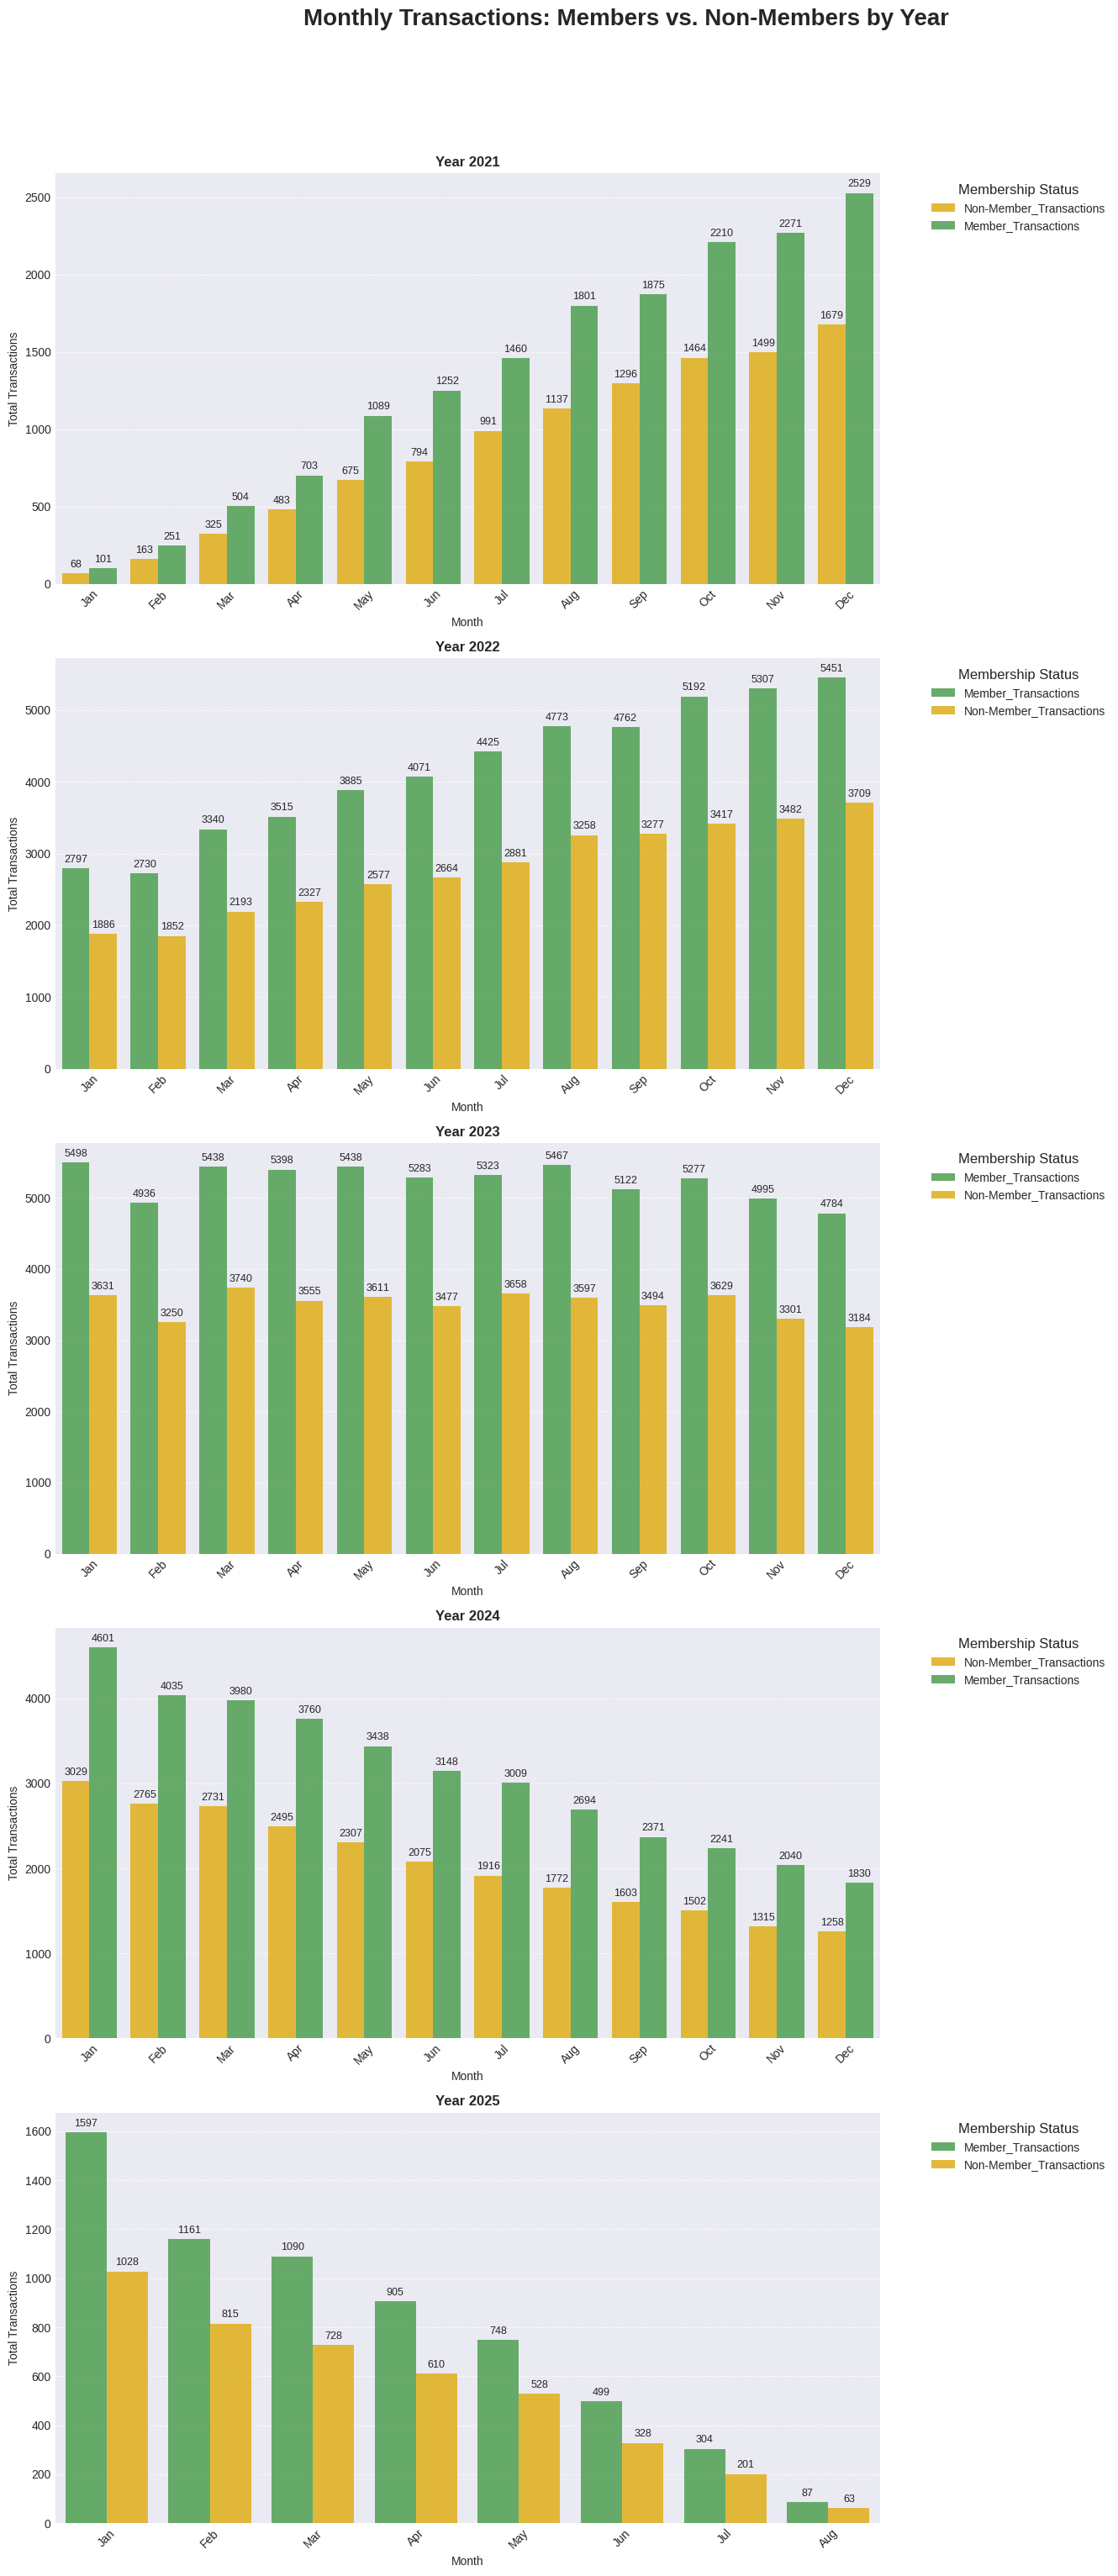

In [272]:
# Reset index to make 'month' a column for plotting
plot_data = monthly_transactions_summary.reset_index()

# Melt the DataFrame to long format for easier plotting with seaborn's hue
melted_plot_data = plot_data.melt(
    id_vars=['month'],
    value_vars=['Non-Member_Transactions', 'Member_Transactions'],
    var_name='Membership_Status',
    value_name='Total_Transactions'
)

# Sort by month for chronological order
melted_plot_data['month_dt'] = melted_plot_data['month'].dt.to_timestamp()
melted_plot_data = melted_plot_data.sort_values(by='month_dt')

# Extract Year for annual grouping
melted_plot_data['Year'] = melted_plot_data['month_dt'].dt.year
melted_plot_data['Month_Name'] = melted_plot_data['month_dt'].dt.strftime('%b')

# Get unique years
years = sorted(melted_plot_data['Year'].unique())

# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')

# Create subplots for each year
fig, axes = plt.subplots(
    nrows=len(years),
    ncols=1,
    figsize=(15, 6 * len(years)), # Adjust figure size based on the number of years
    sharex=False # Do not share x-axis to allow independent month labels
)

fig.suptitle(
    'Monthly Transactions: Members vs. Non-Members by Year',
    fontsize=20,
    fontweight='bold',
    y=1.02 # Adjust title position
)

# Handle if only one year is present, axes might not be an array
if len(years) == 1:
    axes = [axes]

# Loop through each year to create a separate bar chart
for i, year in enumerate(years):
    ax = axes[i]
    yearly_data = melted_plot_data[melted_plot_data['Year'] == year]

    sns.barplot(
        data=yearly_data,
        x='Month_Name',
        y='Total_Transactions',
        hue='Membership_Status',
        palette={'Member_Transactions': '#4CAF50', 'Non-Member_Transactions': '#FFC107'},
        alpha=0.9,
        ax=ax
    )

    ax.set_title(f'Year {year}', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Total Transactions')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='Membership Status', fontsize=10, title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend outside

    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.tight_layout(rect=[0, 0, 0.9, 0.98]) # Adjusted rect to make space for the legend
plt.show()


## 📊 Monthly Transaction Comparison: Member vs Non-Member

Berdasarkan visualisasi bulanan, terlihat bahwa total transaksi dari pelanggan member secara konsisten lebih tinggi dibandingkan non-member di hampir seluruh periode.

### 🔍 Insight
- Member menghasilkan volume transaksi yang lebih besar setiap bulan
- Pola ini konsisten di berbagai tahun, baik saat fase growth maupun penurunan

### ⚠️ Interpretasi
- Perbedaan ini menunjukkan bahwa member memiliki kontribusi besar terhadap total transaksi
- Namun, tingginya volume ini kemungkinan dipengaruhi oleh jumlah member yang lebih banyak dalam populasi

### 🧠 Catatan Analitis
- Trend grafik ini sesuai dengan uji statistik yang dimana adanya perbedaan signifikan volume transaksi member
### 📌 Kesimpulan
Member mendominasi volume transaksi secara bulanan, yang membuktikan pelanggan memiliki member alfamrt lebih aktif secara individu dibandingkan non-member

In [273]:
# --- Restore original df to ensure correct starting point for analysis ---
pos_transactions = pd.read_csv('alfa_pos_transactions.csv')
products = pd.read_csv('alfa_products.csv')
stores = pd.read_csv('alfa_stores.csv')

df = pd.merge(pos_transactions, products, on='sku_id')
df = pd.merge(df, stores, on='store_id')

# Re-apply trx_time and open_date conversions and trx_status calculation
df['trx_time'] = pd.to_datetime(df['trx_time'])
df = df.assign(
    trx_date = df['trx_time'].dt.date,
    time_trx = df['trx_time'].dt.time
).drop(columns='trx_time')
df['open_date'] = pd.to_datetime(df['open_date']).dt.date

df['trx_status'] = df.apply(
    lambda x: 'Error Transaction' if pd.Timestamp(x['trx_date']) < pd.Timestamp(x['open_date']) else 'Valid Transaction',
    axis=1
)
# -----------------------------------------------------------------------

# Reconstruct df_analysis_base with all valid cleaning steps
# Start from the full df which has trx_date, open_date, trx_status (from previous cells)
df_analysis_base = df.copy()

# 1. Remove Error Transactions
df_analysis_base = df_analysis_base[df_analysis_base['trx_status'] == 'Valid Transaction'].copy()

# 2. Handle Outliers in qty
df_analysis_base = df_analysis_base[(df_analysis_base['qty'] > 0) & (df_analysis_base['qty'] < 30)].copy()

# 3. Handle Inconsistent Payment Methods
payment_revised = {
    'debit bca': 'BCA Debit',
    'qris': 'QRIS',
    'CASH': 'Cash',
    'Tunai': 'Cash'
}
df_analysis_base['payment_method'] = df_analysis_base['payment_method'].replace(payment_revised)

# Now, create df_member from this correctly cleaned base DataFrame
df_member = df_analysis_base.copy() # Use the properly cleaned and filtered base dataframe

# Create label member / non-member
df_member['is_member'] = df_member['member_id'].notna().astype(int)

# Ensure trx_date is datetime and extract month
df_member['trx_date'] = pd.to_datetime(df_member['trx_date'])
df_member['month'] = df_member['trx_date'].dt.to_period('M')

# Group by month and membership status, then count unique transactions
monthly_transactions_summary = df_member.groupby(['month', 'is_member'])['receipt_id'].nunique().reset_index()

# Pivot the table to have 'Member' and 'Non-Member' as columns
# Fill missing combinations of (month, is_member) with 0 before pivoting
monthly_transactions_summary = monthly_transactions_summary.pivot(index='month', columns='is_member', values='receipt_id').fillna(0).astype(int)

# Rename columns for clarity
# The columns created by pivot will be 0 and 1, representing is_member.
# We need to explicitly name them 'Non-Member_Transactions' and 'Member_Transactions'.
# This handles cases where for some months, only members or only non-members had transactions
if 0 not in monthly_transactions_summary.columns:
    monthly_transactions_summary[0] = 0
if 1 not in monthly_transactions_summary.columns:
    monthly_transactions_summary[1] = 0

monthly_transactions_summary = monthly_transactions_summary[[0, 1]] # Ensure order
monthly_transactions_summary.columns = ['Non-Member_Transactions', 'Member_Transactions']

# Annual aggregation
annual_transactions_summary = monthly_transactions_summary.reset_index()
annual_transactions_summary['year'] = annual_transactions_summary['month'].dt.year
annual_transactions_summary = annual_transactions_summary.groupby('year')[['Non-Member_Transactions', 'Member_Transactions']].sum().reset_index()

display(annual_transactions_summary)

,year,Non-Member_Transactions,Member_Transactions
0,2021,10574,16046
1,2022,33523,50248
2,2023,42127,62959
3,2024,24768,37147
4,2025,4301,6391


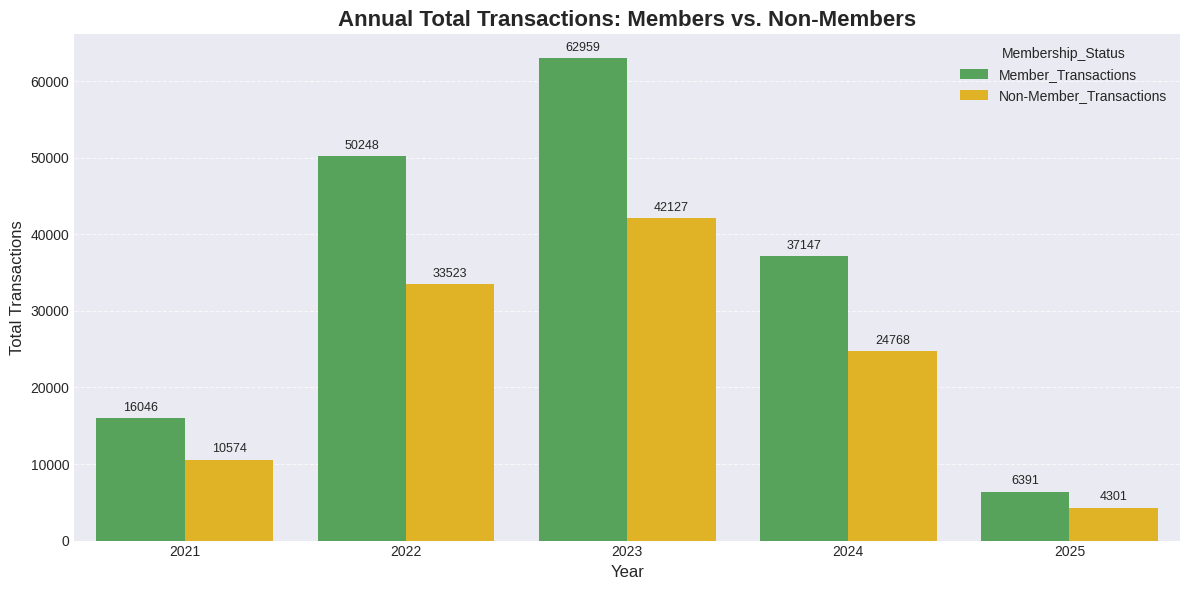

In [213]:
# Aggregate to annual level for plotting
annual_members_combined_transactions = melted_plot_data.groupby(['Year', 'Membership_Status'])['Total_Transactions'].sum().reset_index()

# Sort for consistent plotting
annual_members_combined_transactions = annual_members_combined_transactions.sort_values(by=['Year', 'Membership_Status'])

# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=annual_members_combined_transactions,
    x='Year',
    y='Total_Transactions',
    hue='Membership_Status',
    palette={'Member_Transactions': '#4CAF50', 'Non-Member_Transactions': '#FFC107'} # Eye-catching palette
)

plt.title(
    'Annual Total Transactions: Members vs. Non-Members',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.xticks(rotation=0) # Keep years straight for annual plot
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 📊 Annual Transaction Comparison: Member vs Non-Member

Berdasarkan agregasi tahunan, total transaksi dari pelanggan member secara konsisten lebih tinggi dibandingkan non-member pada setiap tahun.

---

### 🔍 Insight
- Member berkontribusi lebih besar terhadap total transaksi tahunan  
- Puncak transaksi terjadi pada tahun 2023, baik pada kelompok member maupun non-member  
- Tren penurunan setelah 2023 terjadi secara konsisten pada kedua kelompok  

---

### ⚠️ Interpretasi
- Tingginya total transaksi dari member kemungkinan dipengaruhi oleh **jumlah populasi member yang lebih besar**  
- Pola tren yang serupa antara member dan non-member menunjukkan bahwa **faktor eksternal (seperti promo atau kondisi pasar)** mempengaruhi keduanya secara bersamaan  

---

### 🧠 Catatan Analitis
- Secara agregat, member terlihat lebih dominan dalam kontribusi transaksi  
- Namun, hasil uji statistik menunjukkan bahwa **tidak terdapat perbedaan signifikan pada tingkat individu**  
- Hal ini mengindikasikan bahwa perbedaan total transaksi lebih disebabkan oleh **jumlah pelanggan**, bukan karena **perilaku transaksi yang lebih aktif**  

---

### 📌 Kesimpulan
Meskipun pelanggan member memberikan kontribusi lebih besar terhadap total transaksi, tidak terdapat bukti yang cukup bahwa mereka memiliki frekuensi transaksi yang lebih tinggi secara individual dibandingkan non-member.

# 📊 Analytical Insight: Membership Effect

Berdasarkan hasil uji statistik, tidak ditemukan perbedaan signifikan antara jumlah transaksi pelanggan member dan non-member.

### 🔍 Insight
- Membership tidak menunjukkan pengaruh signifikan terhadap frekuensi transaksi
- Perilaku transaksi antara member dan non-member relatif serupa

### ⚠️ Interpretasi
- Membership belum terbukti menjadi driver utama dalam meningkatkan volume transaksi
- Namun, membership tetap memiliki potensi dalam aspek lain seperti customer tracking dan loyalty

### 📌 Implikasi
- Strategi bisnis tidak dapat hanya bergantung pada membership untuk meningkatkan transaksi
- Diperlukan pendekatan lain yang lebih langsung mempengaruhi perilaku pembelian

# **Analisis Trend Produk**

In [214]:
# --- Restore original df to ensure correct starting point for analysis ---
pos_transactions = pd.read_csv('alfa_pos_transactions.csv')
products = pd.read_csv('alfa_products.csv')
stores = pd.read_csv('alfa_stores.csv')

df = pd.merge(pos_transactions, products, on='sku_id')
df = pd.merge(df, stores, on='store_id')

# Re-apply trx_time and open_date conversions and trx_status calculation
df['trx_time'] = pd.to_datetime(df['trx_time'])
df = df.assign(
    trx_date = df['trx_time'].dt.date,
    time_trx = df['trx_time'].dt.time
).drop(columns='trx_time')
df['open_date'] = pd.to_datetime(df['open_date']).dt.date

df['trx_status'] = df.apply(
    lambda x: 'Error Transaction' if pd.Timestamp(x['trx_date']) < pd.Timestamp(x['open_date']) else 'Valid Transaction',
    axis=1
)
# -----------------------------------------------------------------------

# Reconstruct df_cln with all valid cleaning steps
# Start from the full df which has trx_date, open_date, trx_status
df_cln = df.copy()

# 1. Remove Error Transactions
df_cln = df_cln[df_cln['trx_status'] == 'Valid Transaction'].copy()

# 2. Handle Outliers in qty
df_cln = df_cln[(df_cln['qty'] > 0) & (df_cln['qty'] < 30)].copy()

# 3. Handle Inconsistent Payment Methods
payment_revised = {
    'debit bca': 'BCA Debit',
    'qris': 'QRIS',
    'CASH': 'Cash',
    'Tunai': 'Cash'
}
df_cln['payment_method'] = df_cln['payment_method'].replace(payment_revised)

# Ensure trx_date is datetime and create hari_transaksi for consistency, if not already present
df_cln['trx_date'] = pd.to_datetime(df_cln['trx_date'])

df_cln.head(1)

,receipt_id,store_id,sku_id,member_id,payment_method,qty,total_price,product_name,category,unit_price,store_name,city,open_date,trx_date,time_trx,trx_status
0,RCP00000001,SAT-0142,SKU000180,MEM-11247,BCA Debit,1,33500.0,Bimoli Pouch 2000ml,Food & Staples,33500.0,Alfamart Gatot Subroto 141,Bandung,2022-10-18,2022-12-24,21:00:00,Valid Transaction


In [215]:
# Ensure 'trx_date' is a datetime object
df_cln['trx_date'] = pd.to_datetime(df_cln['trx_date'])

# Extract month from 'trx_date'
df_cln['month'] = df_cln['trx_date'].dt.to_period('M')

# Group by category and month, then count the number of unique receipt_ids
trend_product_sales = df_cln.groupby(['category', 'month'])['receipt_id'].nunique().reset_index()\
.sort_values('month',ascending=True)

# Display the aggregated table
trend_product_sales

,category,month,receipt_id
0,Beverage,2021-01,28
56,Cigarettes,2021-01,50
112,Food & Staples,2021-01,66
168,Personal Care,2021-01,25
113,Food & Staples,2021-02,188
...,...,...,...
110,Cigarettes,2025-07,105
111,Cigarettes,2025-08,27
55,Beverage,2025-08,27
167,Food & Staples,2025-08,68


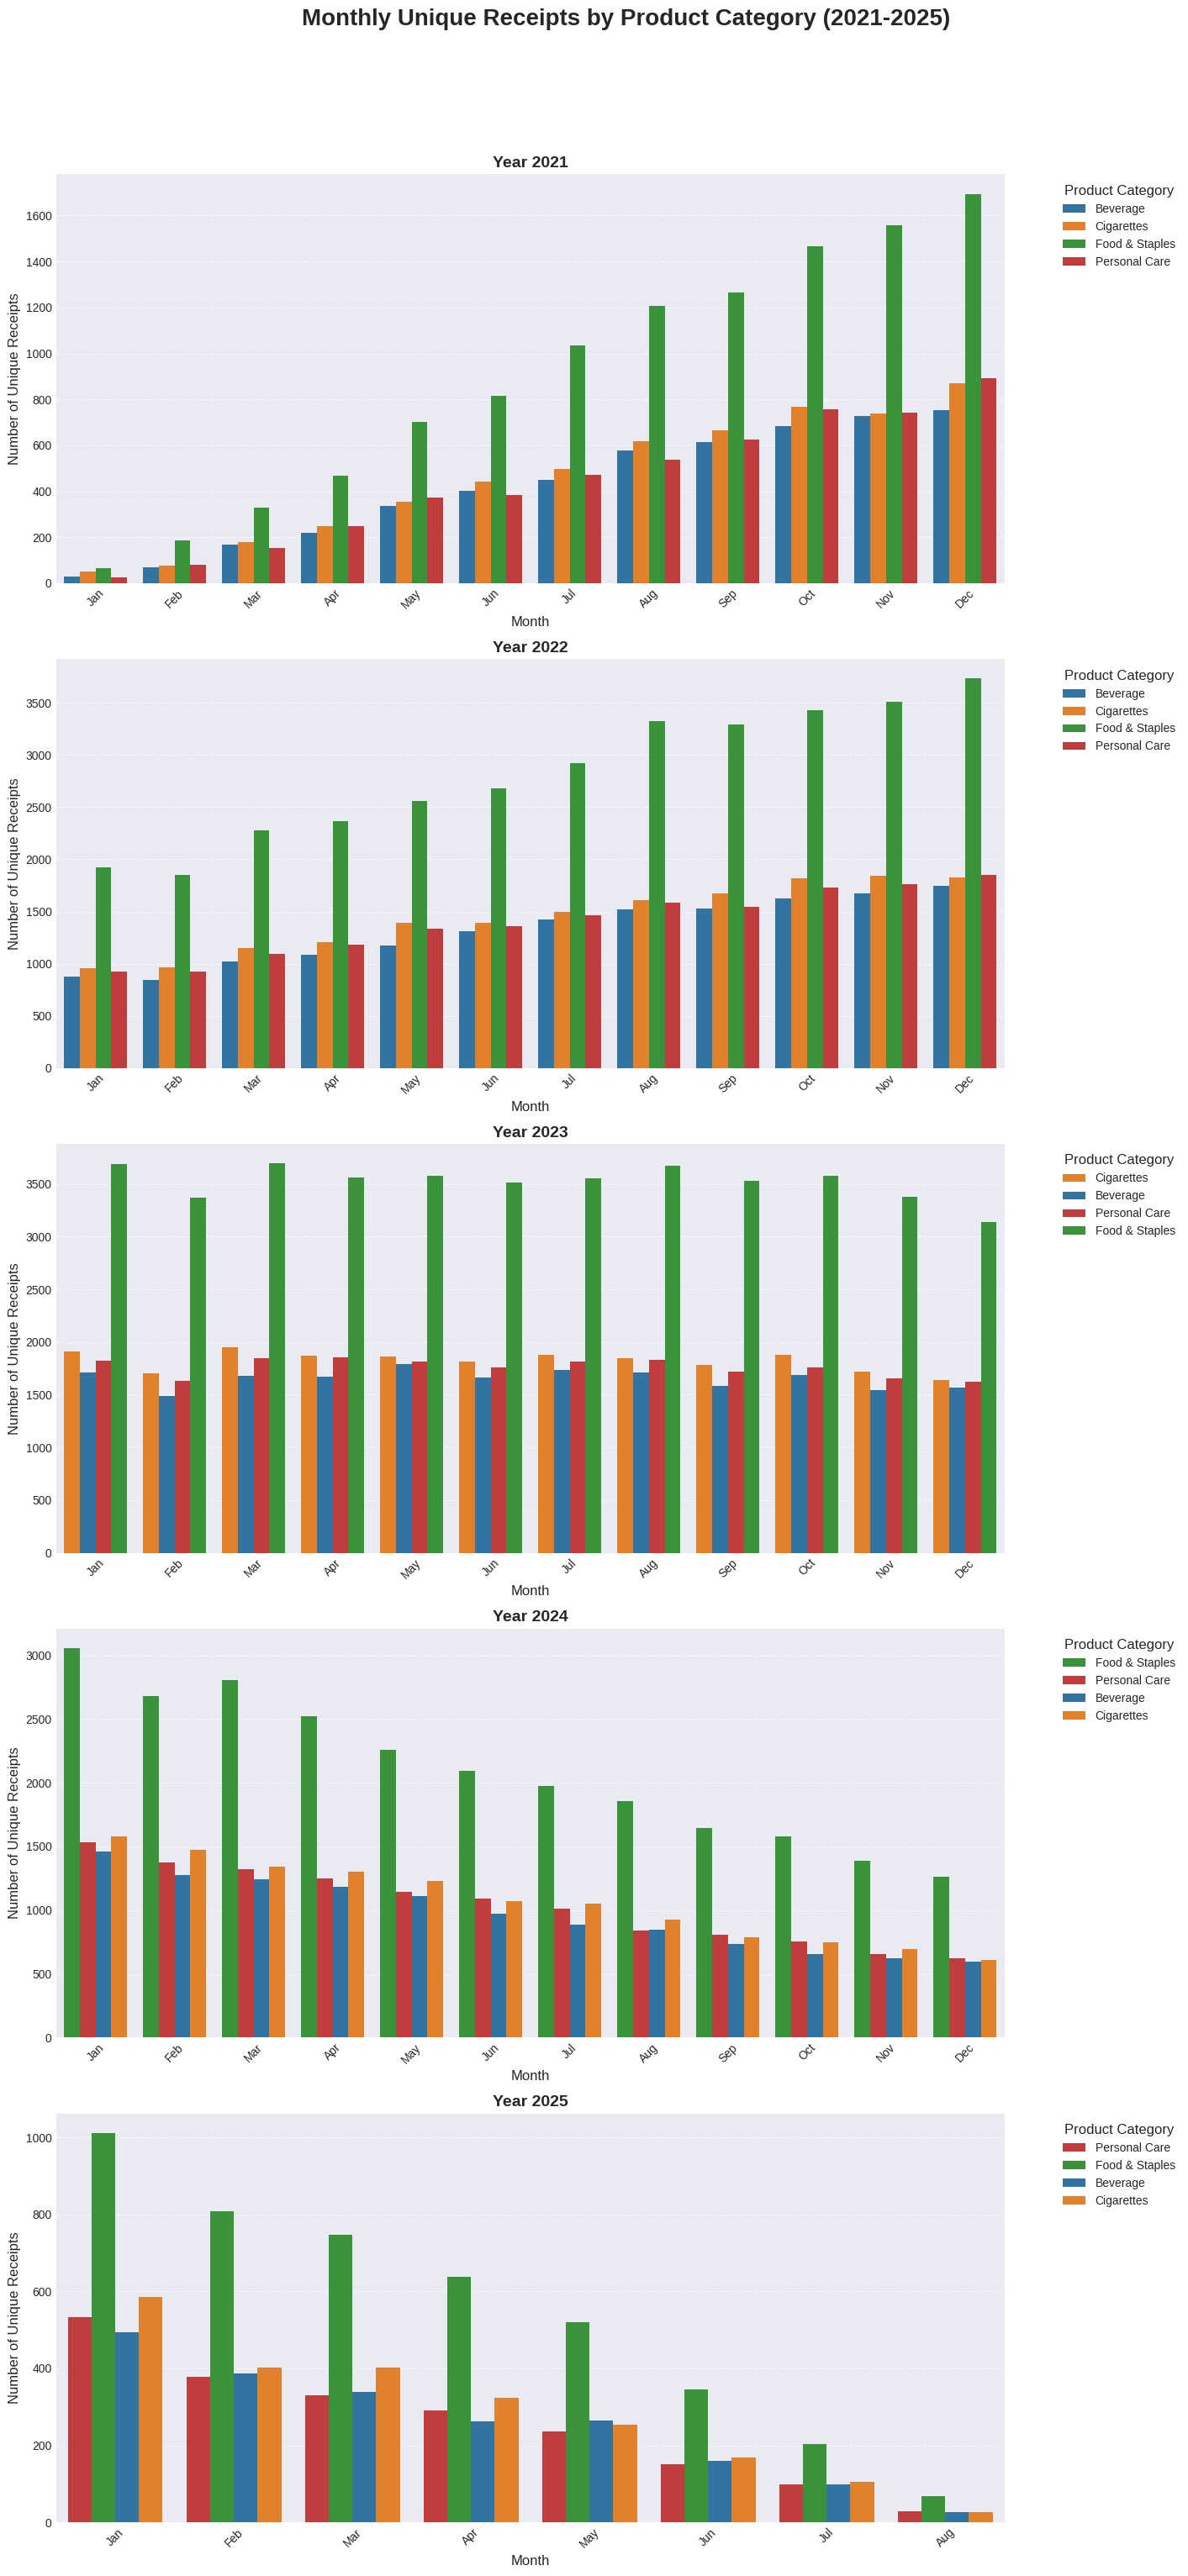

In [216]:
# Ensure 'month' column is datetime type for plotting and extraction
plot_data_category = trend_product_sales.copy()
plot_data_category['month'] = plot_data_category['month'].dt.to_timestamp()

# Extract year and month name
plot_data_category['Year'] = plot_data_category['month'].dt.year
plot_data_category['Month_Name'] = plot_data_category['month'].dt.strftime('%b')

# Get unique years for creating subplots
years = sorted(plot_data_category['Year'].unique())

# Define a custom color palette for consistent category colors across all years
unique_categories = plot_data_category['category'].unique()
# Using seaborn's default palette for generating distinct colors, then mapping them
category_colors = dict(zip(unique_categories, sns.color_palette('tab10', len(unique_categories))))

# Set a consistent style for the plots
plt.style.use('seaborn-v0_8-darkgrid')

# Create a figure and a set of subplots for each year
fig, axes = plt.subplots(
    nrows=len(years),
    ncols=1,
    figsize=(15, 6 * len(years)), # Adjust figure size based on number of years
    sharex=False # Allow independent x-axis for each year if needed
)

fig.suptitle(
    'Monthly Unique Receipts by Product Category (2021-2025)',
    fontsize=20,
    fontweight='bold',
    y=1.02 # Adjust title position
)

# Ensure axes is iterable even if there's only one year
if len(years) == 1:
    axes = [axes]

# Loop through each year to create a bar chart
for i, year in enumerate(years):
    ax = axes[i]
    yearly_data = plot_data_category[plot_data_category['Year'] == year]

    # Plotting with seaborn.barplot using the custom palette
    sns.barplot(
        data=yearly_data,
        x='Month_Name',
        y='receipt_id',
        hue='category',
        ax=ax,
        palette=category_colors
    )

    ax.set_title(f'Year {year}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Number of Unique Receipts', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.legend(title='Product Category', fontsize=10, title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars (optional, can be very crowded)
    # for container in ax.containers:
    #     ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.tight_layout(rect=[0, 0, 0.95, 0.98]) # Adjust layout to prevent labels from overlapping
plt.show()

## 📊 Monthly Product Category Trend Analysis

Berdasarkan visualisasi bulanan, terlihat bahwa seluruh kategori produk mengalami pola pertumbuhan yang kuat pada periode 2021 hingga 2023, kemudian diikuti dengan penurunan yang cukup konsisten pada tahun 2024 hingga 2025.

### 🔍 Insight
- Kategori **Food & Staples** secara konsisten menjadi kontributor terbesar dalam setiap bulan
- Seluruh kategori (Food & Staples,Beverage, Cigarettes, Personal Care) menunjukkan pola yang serupa:
  - meningkat hingga 2023
  - kemudian menurun secara bertahap setelahnya
- Penurunan terjadi secara **konsisten antar bulan**, bukan hanya di periode tertentu

### ⚠️ Interpretasi
- Penurunan transaksi terjadi secara **menyeluruh di semua kategori**
- Hal ini mengindikasikan adanya faktor yang bersifat global, seperti:
  - penurunan efektivitas promo
  - perubahan perilaku konsumen
  - atau faktor eksternal lainnya

### 🧠 Kesimpulan
Penurunan transaksi bersifat sistemik dan terjadi secara merata di seluruh kategori produk, sehingga tidak dapat diselesaikan dengan fokus pada satu kategori saja

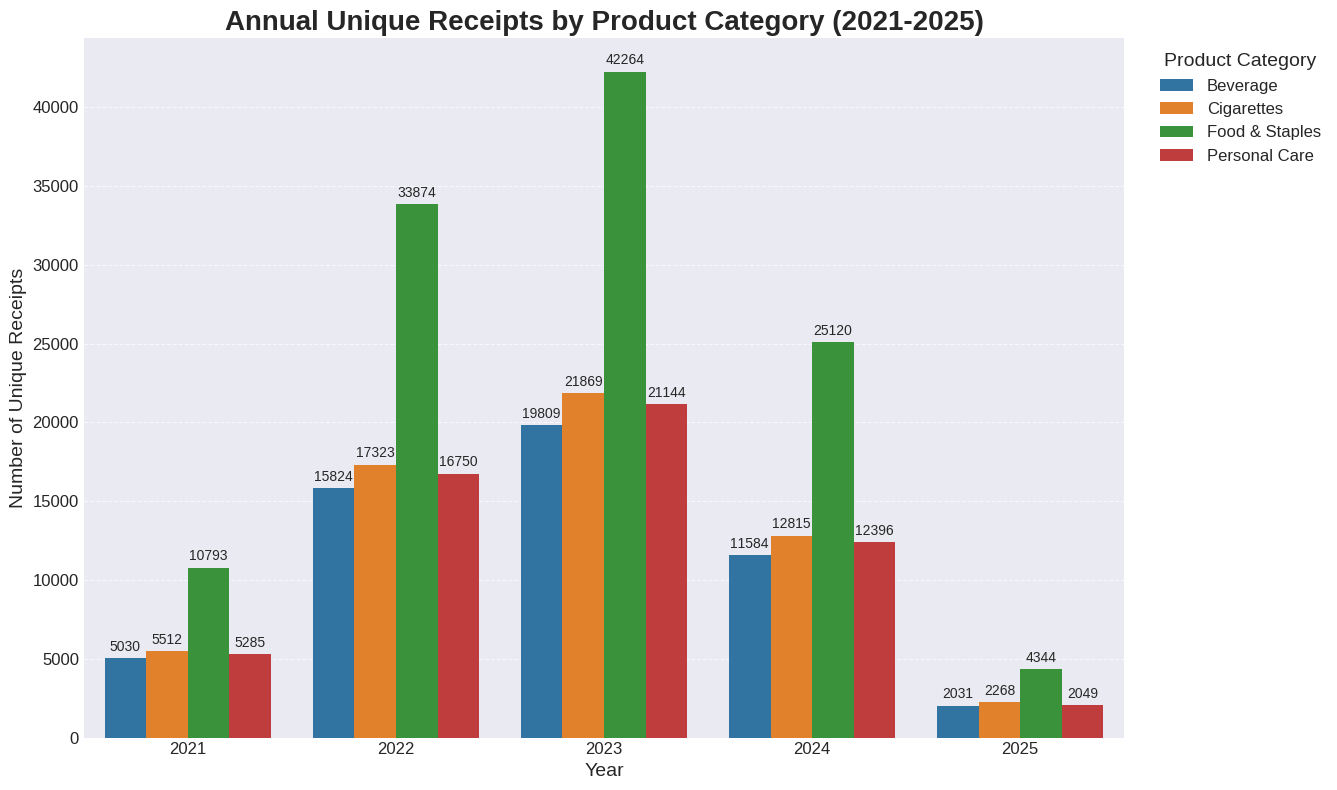

In [217]:
# Ensure 'month' column is datetime type for plotting and extraction
plot_data_category = trend_product_sales.copy()
plot_data_category['month'] = plot_data_category['month'].dt.to_timestamp()

# Extract year
plot_data_category['Year'] = plot_data_category['month'].dt.year

# Aggregate to annual level for plotting
annual_category_sales = plot_data_category.groupby(['Year', 'category'])['receipt_id'].sum().reset_index()

# Define a custom color palette for consistent category colors
unique_categories = annual_category_sales['category'].unique()
category_colors = dict(zip(unique_categories, sns.color_palette('tab10', len(unique_categories))))

# Set a consistent style for the plot
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(15, 8))

sns.barplot(
    data=annual_category_sales,
    x='Year',
    y='receipt_id',
    hue='category',
    palette=category_colors
)

plt.title(
    'Annual Unique Receipts by Product Category (2021-2025)',
    fontsize=20,
    fontweight='bold'
)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Unique Receipts', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Product Category', fontsize=12, title_fontsize='14', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to prevent labels from overlapping
plt.show()

## 📊 Annual Product Category Trend Analysis (2021–2025)

Berdasarkan agregasi tahunan, seluruh kategori produk menunjukkan pola yang konsisten, yaitu peningkatan hingga tahun 2023 dan penurunan setelahnya.

### 🔍 Insight
- Tahun 2023 merupakan titik puncak performa di semua kategori
- Kategori **Food & Staples** memiliki kontribusi terbesar terhadap total transaksi setiap tahun
- Setelah 2023, seluruh kategori mengalami penurunan signifikan tanpa adanya kategori yang tetap stabil atau tumbuh

### ⚠️ Interpretasi
- Penurunan tidak disebabkan oleh perubahan pada kategori tertentu, melainkan terjadi secara menyeluruh
- Hal ini mengindikasikan bahwa faktor utama kemungkinan berasal dari:
  - strategi bisnis (misalnya efektivitas promo)
  - atau faktor eksternal yang mempengaruhi seluruh kategori

### 🧠 Kesimpulan
Penurunan volume transaksi setelah 2023 merupakan fenomena global yang mempengaruhi seluruh kategori produk, dengan dampak terbesar pada kategori utama (Food & Staples)

This table shows the total quantity sold for each product category, aggregated by month.

# **Strategi**

Berdasarkan hasil analisa trend produk menjadi menjadi referensi untuk strategi:

### 1. Voucher Promo (Basket Expansion)

- Beli Food & Staples dengan minimum pembelian tertentu → mendapatkan diskon untuk kategori lain

### 2. Bundling Early month

- Membuat paket bundling di awal bulan antara Food & Staples dengan kategori lain

Contoh:
- Paket hemat: Beras + Minuman + Personal Care

🎯 Tujuan:
- Mendorong eksplorasi produk
- Mengangkat kategori dengan kontribusi rendah


# **Section 5 : Kesimpulan & Rekomendasi**

# 📌 Kesimpulan

Berdasarkan keseluruhan analisis data POS Alfamart, terdapat beberapa temuan utama yang berkaitan dengan kualitas data, operasional, serta efektivitas Promo JSM.

---

### 1. Data Quality & System Issue
Ditemukan berbagai anomali data seperti:
- nilai `qty` negatif dan ekstrem
- `total_price` yang tidak logis
- transaksi yang terjadi sebelum tanggal pembukaan gerai (~3%)

Hal ini mengindikasikan adanya:
- error pada sistem POS
- serta kesalahan input oleh kasir

---

### 2. Cashier Operational Issue
Terdapat pola transaksi dengan jumlah item yang tidak wajar (outlier), terutama pada kategori **Food & Staples**.

Hal ini mengindikasikan:
- potensi kesalahan scanning (double scan)
- transaksi dalam jumlah besar yang perlu divalidasi

---

### 3. Master Data Issue (Payment Method)
Ditemukan inkonsistensi dalam pencatatan metode pembayaran (CASH, Tunai, dll), yang berdampak pada:
- ketidakakuratan laporan keuangan
- bias dalam analisis data

---

### 4. Product Data Standardization Issue
Ditemukan inkonsistensi dalam penulisan nama produk (product_name), seperti:
- perbedaan format penulisan (huruf besar/kecil)
- variasi penamaan untuk produk yang sama

Hal ini berdampak pada:
- duplikasi data produk
- ketidakakuratan dalam agregasi dan analisis kategori produk
- potensi bias dalam pengambilan keputusan berbasis produk

---

### 5. Customer Data Limitation
Sekitar **40% transaksi tidak memiliki `member_id`**, sehingga:
- mengurangi visibilitas terhadap perilaku pelanggan
- membatasi analisis Customer Lifetime Value (CLV)

---

### 6. Promo JSM Behavior & Customer Pattern
- Mayoritas member hanya melakukan transaksi **1 kali per bulan**
- Tidak terdapat indikasi dominasi atau monopoli oleh member tertentu

Hal ini menunjukkan bahwa:
- distribusi transaksi relatif merata
- belum terlihat adanya penyalahgunaan promo secara signifikan

---

### 7. Hubungan JSM dengan Total Transaksi
Berdasarkan uji statistik (Spearman correlation ≈ 0.97) dan visualisasi scatter plot:

- Terdapat **hubungan positif yang sangat kuat dan signifikan** antara transaksi JSM dan total transaksi Alfamart
- Pola hubungan bersifat linear dan konsisten

👉 Artinya:
- ketika aktivitas JSM meningkat, total transaksi juga cenderung meningkat

Namun demikian:
- hubungan ini bersifat **korelasional**, bukan sebab-akibat

---

### 8. Product Category Trend Analysis
- Seluruh kategori produk mengalami peningkatan hingga tahun 2023 dan penurunan setelahnya
- Tidak terdapat kategori yang tetap stabil saat penurunan terjadi
- Kategori **Food & Staples** menjadi kontributor terbesar sepanjang periode

Hal ini menunjukkan bahwa:
- penurunan transaksi terjadi secara **menyeluruh (global)**, bukan pada kategori tertentu

👉 Indikasi:
- terdapat penurunan efektivitas strategi secara keseluruhan, bukan pada produk spesifik

---

### 9. Shrinkage Analysis
- Shrinkage terjadi dalam jumlah kecil dan relatif merata antar gerai
- Tidak terdapat gerai dengan risiko dominan
- namun perlu dianalisis lebih lanjut

---

### 10. Membership Impact Analysis
- Secara agregat, pelanggan member memberikan kontribusi transaksi yang lebih besar  
- Hasil uji statistik menunjukkan adanya **pengaruh signifikan terhadap frekuensi transaksi**  

Namun demikian:
- Membership bukan merupakan faktor utama dibandingkan promo dan kebutuhan produk  
- Perannya lebih sebagai **faktor pendukung (supporting factor)** dalam meningkatkan aktivitas transaksi  

👉 Implikasi:
- Membership dapat dimanfaatkan untuk:
  - meningkatkan efektivitas distribusi promo  
  - mendukung strategi cross-selling dan bundling produk  

---

## 🧠 Kesimpulan Utama

Permasalahan utama yang ditemukan bukan pada penyalahgunaan oleh pihak **tengkulak**, melainkan pada:

- **kualitas data (data quality issue)**
- **kesalahan operasional kasir**
- **ketidakkonsistenan sistem pencatatan**
- **ketidakkonsistenan data produk (product standardization issue)**
- **penurunan performa penjualan setelah tahun 2023**
- **penurunan efektivitas strategi secara global**

Di sisi lain:
- **Promo JSM terbukti menjadi driver utama traffic**
- **Membership memiliki pengaruh, namun bersifat pendukung**
- **Kategori produk (Food & Staples) menjadi kunci utama dalam menarik transaksi**

---



# 🚀 Rekomendasi

Berdasarkan hasil analisis, berikut rekomendasi strategis untuk meningkatkan efisiensi operasional dan efektivitas bisnis:

---

### 1. 📊 Data Quality & System Improvement
- Implementasi validasi otomatis pada sistem POS:
  - pembatasan nilai `qty` tidak logis
  - pencegahan input negatif
- Perbaikan sinkronisasi sistem untuk menghindari logical error transaksi

---

### 2. 🧑‍💼 Cashier SOP & Training
- Melakukan pelatihan ulang kasir terkait:
  - prosedur scanning yang benar
  - penanganan void transaksi
- Fokus pada kategori dengan volume tinggi (Food & Staples)

---

### 3. 💳 Standardisasi Payment Method
- Mengubah sistem input menjadi berbasis dropdown
- Menstandarisasi kategori pembayaran untuk meningkatkan akurasi reporting

---

### 4. 🏷️ Standardisasi Product Name
- Menstandarisasi penulisan nama produk untuk menghindari duplikasi
- Menggunakan referensi master product (data dictionary / mapping)
- Mengurangi variasi penamaan (case sensitivity, typo, dll)

🎯 Tujuan:
- meningkatkan akurasi analisis produk  
- memastikan agregasi data lebih konsisten  
- mendukung strategi berbasis kategori produk  

---

### 5. 👤 Customer & Membership Strategy
- Mengoptimalkan penggunaan membership sebagai alat:
  - tracking behavior pelanggan
  - personalisasi promo  
- Menggunakan data member untuk:
  - distribusi voucher yang lebih tepat sasaran  
  - mendukung strategi bundling & cross-selling  

---

### 6. 🛒 Optimasi Strategi Promo JSM
- Promo JSM tetap digunakan sebagai driver utama transaksi
- Namun perlu:
  - evaluasi performa secara berkala
  - inovasi strategi untuk menghindari kejenuhan promo (promo fatigue)

---

### 7. 🛍️ Cross-Category Strategy (Leverage Food & Staples)

#### a. Voucher discount
- Belanja Food & Staples dengan minimum tertentu → mendapatkan voucher untuk kategori lain

#### b. Monthly Bundling Strategy
- Bundling produk Food & Staples dengan kategori lain (Beverage, Personal Care)

🎯 Tujuan:
- meningkatkan basket size
- mendorong pembelian lintas kategori
- mengoptimalkan kategori dengan kontribusi lebih rendah

---

### 8. 📉 Shrinkage Monitoring
- Melakukan audit berkala pada gerai

---

## 🎯 Dampak yang Diharapkan

Dengan implementasi rekomendasi ini, perusahaan dapat:
- **meningkatkan kualitas dan konsistensi data**
- **mengurangi kesalahan operasional**
- **memaksimalkan efektivitas promo sebagai penggerak traffic**
- **mengoptimalkan peran membership sebagai pendukung strategi**
- **meningkatkan akurasi analisis produk**
- **meningkatkan nilai transaksi melalui cross-selling**
- **meningkatkan kualitas analisis customer dan decision making**